# SQuIRE + TRACE — Thesis Analysis

This notebook is the primary quantitative analysis artefact for the Master's Thesis. Every number reported here is computed directly from the raw output files in `../outputs/`. Nothing is hard-coded.

> **Kernel note:** Run via `uv run jupyter notebook` from the project root, or register the venv kernel with `uv run python -m ipykernel install --user --name squire`.

---

## Table of Contents

1. [Setup — Imports, Paths, Manifest](#setup)
2. [Experimental Design & Dataset Inventory](#design)
3. [RQ1 — SQuIRE Synthesis Quality](#rq1)
4. [RQ2 — TRACE Extraction Accuracy: Cross-Model & Temperature](#rq2-accuracy)
5. [RQ2 — TRACE Extraction: Interview Condition Effects](#rq2-conditions)
6. [RQ3 — Traceability & Gap Detection](#rq3)
7. [Cross-Pipeline Analysis (RQ1 × RQ2)](#cross-pipeline)
8. [Manual Validation](#validation)
9. [Summary Tables](#summary)


---
**Note on pipeline naming (thesis vs. notebook):** In the final thesis, the two SQuIRE synthesis pipelines are referred to as **two-step** (Corpus A) and **three-step** (Corpus B). 
This notebook — and all output filenames, corpus directories, and generated artefacts — retain the original identifiers **single-shot** and **3-step**, 
which were established before the terminological conflict with zero-shot/few-shot prompting paradigm vocabulary was identified. 
The rename was applied to thesis prose only. Both names refer to the same pipelines.

## 1. Setup — Imports, Paths, Manifest <a id='setup'></a>

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (11, 4)})

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUTS = Path("../outputs")
DATA    = Path("../data")

SQUIRE_SINGLE_SHOT = OUTPUTS / "corpus-20260227_105946"
SQUIRE_3STEP       = OUTPUTS / "corpus-20260226_162106"

# ── Display labels ────────────────────────────────────────────────────────────
PROJECT_NAMES = {
    "3": "Nursing Scheduling",
    "4": "Credit Card Disputes",
    "5": "Recycled Parts Mgmt",
    "6": "Conference Room Mgmt",
    "8": "IzognMovies Streaming",
}
INTERVIEWER_LABELS = {
    "re_novice":      "Novice RE",
    "re_experienced": "Experienced RE",
}
STAKEHOLDER_LABELS = {
    "stakeholder_technical_senior":       "Tech. Senior",
    "stakeholder_technical_junior":       "Tech. Junior",
    "stakeholder_nontechnical_manager":   "Non-tech. Manager",
    "stakeholder_nontechnical_enduser":   "End User",
}

# ── TRACE runs manifest ───────────────────────────────────────────────────────
# Each row = one corpus-level extraction run.
# 'group'  — used to slice for specific analyses (temp / model / 3step)
# 'phase'  — 'exploratory' = configuration-selection runs (model choice + temperature sweep);
#             'primary'     = production runs (Mistral Small T=0.5, repeated for stability).
#             Only primary runs should be used for the final evaluation / manual validation.
TRACE_MANIFEST = [
    # ── Exploratory: temperature sensitivity study (Mistral Small, single-shot corpus) ──
    {"label": "Mistral Small T=0.0",    "group": "temp",  "phase": "exploratory", "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.0,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_165429"},
    {"label": "Mistral Small T=0.3",    "group": "temp",  "phase": "exploratory", "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.3,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_175157"},
    {"label": "Mistral Small T=0.7",    "group": "temp",  "phase": "exploratory", "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.7,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_174709"},
    # ── Exploratory: cross-model comparison (single-shot corpus, T=0.0 deterministic) ──
    {"label": "Mistral Medium T=0.0",   "group": "model", "phase": "exploratory", "corpus": "single-shot",
     "model": "mistral-medium", "temp": 0.0,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-medium_trace_20260302_170431"},
    {"label": "GPT-5-mini low-effort",  "group": "model", "phase": "exploratory", "corpus": "single-shot",
     "model": "gpt-5-mini", "temp": None,
     "path": OUTPUTS / "corpus_20260227_105946_gpt-5-mini_trace_20260302_172047"},
    # ── Primary: Mistral Small T=0.5 — selected configuration, repeated for stability ──
    {"label": "Mistral Small T=0.5 #1", "group": "temp",  "phase": "primary",     "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.5,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_173239"},
    {"label": "Mistral Small T=0.5 #2", "group": "temp",  "phase": "primary",     "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.5,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_175542"},
    {"label": "Mistral Small T=0.5 #3", "group": "temp",  "phase": "primary",     "corpus": "single-shot",
     "model": "mistral-small", "temp": 0.5,
     "path": OUTPUTS / "corpus_20260227_105946_mistral-small_trace_20260302_180009"},
    {"label": "Mistral Small T=0.5 #1", "group": "3step", "phase": "primary",     "corpus": "3-step",
     "model": "mistral-small", "temp": 0.5,
     "path": OUTPUTS / "corpus_20260226_162106_mistral-small_trace_20260302_182442"},
    {"label": "Mistral Small T=0.5 #2", "group": "3step", "phase": "primary",     "corpus": "3-step",
     "model": "mistral-small", "temp": 0.5,
     "path": OUTPUTS / "corpus_20260226_162106_mistral-small_trace_20260302_182911"},
]

print(f"TRACE runs in manifest: {len(TRACE_MANIFEST)}")
print(f"  exploratory: {sum(1 for r in TRACE_MANIFEST if r['phase'] == 'exploratory')}")
print(f"  primary:     {sum(1 for r in TRACE_MANIFEST if r['phase'] == 'primary')}")
for r in TRACE_MANIFEST:
    exists = "✓" if r["path"].exists() else "✗ MISSING"
    print(f"  {exists}  [{r['phase']:<11}]  {r['label']:<28}  corpus={r['corpus']}")

TRACE runs in manifest: 10
  exploratory: 5
  primary:     5
  ✓  [exploratory]  Mistral Small T=0.0           corpus=single-shot
  ✓  [exploratory]  Mistral Small T=0.3           corpus=single-shot
  ✓  [exploratory]  Mistral Small T=0.7           corpus=single-shot
  ✓  [exploratory]  Mistral Medium T=0.0          corpus=single-shot
  ✓  [exploratory]  GPT-5-mini low-effort         corpus=single-shot
  ✓  [primary    ]  Mistral Small T=0.5 #1        corpus=single-shot
  ✓  [primary    ]  Mistral Small T=0.5 #2        corpus=single-shot
  ✓  [primary    ]  Mistral Small T=0.5 #3        corpus=single-shot
  ✓  [primary    ]  Mistral Small T=0.5 #1        corpus=3-step
  ✓  [primary    ]  Mistral Small T=0.5 #2        corpus=3-step


### Helper functions

In [3]:
# Parses project_id / interviewer / stakeholder out of transcript filenames.
# Handles both squire filename (transcript_3_re_experienced_...) and
# trace corpus filename (trace_transcript_3_re_experienced_...).
_FNAME_RE = re.compile(
    r"(?:trace_)?transcript_(\d+)_(re_(?:novice|experienced))_(stakeholder_\w+)_\d{8}_\d{6}"
)

def _parse_fname(name: str) -> tuple[str, str, str]:
    m = _FNAME_RE.search(name)
    if not m:
        return "?", "?", "?"
    return m.group(1), m.group(2), m.group(3)


def _texts_match(a: str, b: str, min_len: int = 20) -> bool:
    """True if strings match exactly or one contains the other (at least min_len chars)."""
    a = a.strip().strip("'\"")
    b = b.strip().strip("'\"")
    if a == b:
        return True
    if len(a) >= min_len and a in b:
        return True
    if len(b) >= min_len and b in a:
        return True
    return False


def load_squire_transcripts(corpus_dir: Path) -> pd.DataFrame:
    """Flat DataFrame, one row per transcript, from individual JSON sidecars."""
    records = []
    for f in sorted(corpus_dir.glob("transcript_*.json")):
        d = json.loads(f.read_text())
        ev = d["evaluation"]
        gq = ev["g_eval_quality"]["dimensions"]
        gm = ev["g_eval_meta"]["dimensions"]
        records.append({
            "file":           f.name,
            "project_id":     d["project_id"],
            "interviewer":    d["interviewer_persona"],
            "stakeholder":    d["stakeholder_persona"],
            "quality":        ev["g_eval_quality"]["overall_mean"],
            "structuring":    gq["structuring"]["mean"],
            "clarity":        gq["clarity"]["mean"],
            "responsiveness": gq["responsiveness"]["mean"],
            "rigor":          gq["rigor"]["mean"],
            "meta":           ev["g_eval_meta"]["overall_mean"],
            "completeness":   gm["completeness"]["mean"],
            "realism":        gm["realism"]["mean"],
            "bert_f1":        ev["bert_score"]["f1"],
        })
    return pd.DataFrame(records)


def load_trace_per_transcript(run: dict) -> pd.DataFrame:
    """Per-transcript metrics for one TRACE run, parsed from trace_corpus_meta.json."""
    meta = json.loads((run["path"] / "trace_corpus_meta.json").read_text())
    records = []
    for t in meta["per_transcript"]:
        if t.get("error") or not t.get("metrics"):
            continue
        pid, iview, stake = _parse_fname(t["transcript"])
        records.append({
            "run_label":       run["label"],
            "corpus":          run["corpus"],
            "model":           run["model"],
            "temp":            run["temp"],
            "group":           run["group"],
            "phase":           run["phase"],
            "transcript":      t["transcript"],
            "project_id":      pid,
            "interviewer":     iview,
            "stakeholder":     stake,
            "extracted_count": t["extracted_count"],
            **t["metrics"],
        })
    return pd.DataFrame(records)


def load_all_trace_runs(manifest: list[dict]) -> pd.DataFrame:
    """Load per-transcript data for all runs and concatenate."""
    frames = [load_trace_per_transcript(r) for r in manifest]
    return pd.concat(frames, ignore_index=True)


def load_citations(run: dict) -> pd.DataFrame:
    """Per-requirement citation verification data from extraction JSON files."""
    records = []
    for f in sorted(run["path"].glob("trace_transcript_*.json")):
        if "_eval" in f.name:
            continue
        d = json.loads(f.read_text())
        pid, iview, stake = _parse_fname(f.name)
        for req in d.get("requirements", []):
            records.append({
                "project_id":        pid,
                "interviewer":       iview,
                "stakeholder":       stake,
                "quality_attribute": req.get("quality_attribute", ""),
                "citation_verified": req.get("citation_verified", None),
                "citation_warning":  req.get("citation_warning", ""),
                "confidence":        req.get("confidence", 3),
            })
    return pd.DataFrame(records)


def load_per_req_eval(run: dict) -> pd.DataFrame:
    """Per-requirement evaluation data (overlap, quality scores) from eval JSON files."""
    records = []
    for f in sorted(run["path"].glob("trace_transcript_*_eval.json")):
        d = json.loads(f.read_text())
        pid, iview, stake = _parse_fname(f.name)
        for req in d.get("per_requirement", []):
            records.append({
                "project_id":              pid,
                "interviewer":             iview,
                "stakeholder":             stake,
                "overlap_score":           req["overlap_score"],
                "quality_attribute_match": req["quality_attribute_match"],
                "confidence_quality":      req["confidence_quality"],
                "rationale_quality":       req["rationale_quality"],
                "gap_detection_quality":   req["gap_detection_quality"],
                "is_hit":                  req["is_hit"],
                "is_duplicate":            req["is_duplicate"],
            })
    return pd.DataFrame(records)


def load_confidence_overlap(run: dict) -> pd.DataFrame:
    """Join extraction confidence (Mistral's self-score) with overlap_score from eval.

    Pairs rows by position — valid because extraction and eval files are sorted identically
    and requirements are written in the same order in both.
    """
    records = []
    for ext_f in sorted(run["path"].glob("trace_transcript_*.json")):
        if "_eval" in ext_f.name:
            continue
        eval_f = ext_f.with_name(ext_f.stem + "_eval.json")
        if not eval_f.exists():
            continue
        ext_d  = json.loads(ext_f.read_text())
        eval_d = json.loads(eval_f.read_text())
        pid, iview, stake = _parse_fname(ext_f.name)
        reqs_ext  = ext_d.get("requirements", [])
        reqs_eval = eval_d.get("per_requirement", [])
        if len(reqs_ext) != len(reqs_eval):
            import warnings
            warnings.warn(
                f"Length mismatch in {ext_f.name}: "
                f"extracted={len(reqs_ext)}, eval={len(reqs_eval)} — skipping file",
                stacklevel=2,
            )
            continue
        # Positional join: valid only when extraction and eval files are produced by
        # the same TRACE run and written in requirement order. The length guard above
        # detects any desynchronisation.
        for req_ext, req_eval in zip(reqs_ext, reqs_eval):
            records.append({
                "project_id":    pid,
                "interviewer":   iview,
                "stakeholder":   stake,
                "confidence":    req_ext.get("confidence", 3),
                "overlap_score": req_eval["overlap_score"],
                "is_hit":        req_eval["is_hit"],
                "is_duplicate":  req_eval["is_duplicate"],
            })
    return pd.DataFrame(records)


def load_recall_gaps(run: dict, squire_corpus_dir: Path) -> pd.DataFrame:
    """
    For each GT requirement in the corpus, determine if it was recalled.
    Returns one row per (transcript × GT requirement × category).
    """
    records = []
    for eval_f in sorted(run["path"].glob("trace_transcript_*_eval.json")):
        eval_d = json.loads(eval_f.read_text())
        gt_source = eval_d.get("ground_truth_source", "")
        m = re.search(r"transcript_[^\s/]+\.json", gt_source)
        if not m:
            continue
        sidecar_path = squire_corpus_dir / m.group()
        if not sidecar_path.exists():
            continue
        sidecar = json.loads(sidecar_path.read_text())
        gt_reqs = sidecar.get("selected_requirements", [])

        matched_mgt_list = [
            req["matched_ground_truth"]
            for req in eval_d["per_requirement"]
            if req["is_hit"]
        ]

        pid, iview, stake = _parse_fname(eval_f.name)
        for gt in gt_reqs:
            gt_text = gt["text"].strip("'\"")
            is_matched = any(_texts_match(gt_text, mgt) for mgt in matched_mgt_list)
            for cat in gt.get("categories", ["unknown"]):
                records.append({
                    "project_id":  pid,
                    "interviewer": iview,
                    "stakeholder": stake,
                    "category":    cat,
                    "is_matched":  is_matched,
                })
    return pd.DataFrame(records)


import pingouin as pg


def _wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Wilson score CI for a proportion k/n."""
    from statsmodels.stats.proportion import proportion_confint
    lo, hi = proportion_confint(int(k), int(n), alpha=alpha, method="wilson")
    return float(lo), float(hi)


def _bstrap_ci(
    series: "pd.Series", n_boot: int = 10_000, alpha: float = 0.05
) -> "tuple[float, float]":
    """Bootstrap percentile 95% CI for the mean (scipy.stats.bootstrap)."""
    from scipy.stats import bootstrap as _scipy_bootstrap
    result = _scipy_bootstrap(
        (np.asarray(series),), np.mean,
        n_resamples=n_boot,
        confidence_level=1 - alpha,
        method="percentile",
        random_state=42,
    )
    return float(result.confidence_interval.low), float(result.confidence_interval.high)

print("Helpers loaded.")

Helpers loaded.


---
## 2. Experimental Design & Dataset Inventory <a id='design'></a>

### 2.1 The NICE Dataset

The NICE dataset (Non-Functional Requirements Identification, Classification, and Explanation Using Small Language Models) provides 15 software projects with labelled quality requirements drawn from specifications. SQuIRE (Synthesis pipeline presented as the foundation building the ground truth for later TRACE extraction) uses NICE as the source of ground-truth quality requirements that each synthetic interview transcript is designed to elicit.

### 2.2 Corpus Design

The synthetic corpus was generated by SQuIRE using the following full-factorial design:

| Factor | Levels |
|--------|--------|
| Projects | 5 (IDs 3, 4, 5, 6, 8 — chosen for requirement density and domain diversity) |
| Interviewer personas | 2 (`re_novice`, `re_experienced`) |
| Stakeholder personas | 4 (`technical_senior`, `technical_junior`, `nontechnical_manager`, `nontechnical_enduser`) |
| **Total transcripts** | **5 × 2 × 4 = 40** |

Two pipeline variants were generated:
- **Single-shot** (`corpus-20260227_105946`): select → one-pass synthesis — faster, higher completeness
    - Referred to as single-shot because the synthesis is done in one pass.
    - Single-shot is indicated by `single_shot` option being `true`.
- **3-step** (`corpus-20260226_162106`): select → outline → draft CoT pipeline — higher dialogue quality
    - Referred to as 3-step because including the selection, it has a total of 3-steps. In previous versions a 4-step synthesis existed.
    - 3-step is indicated by `no_refine` option being `true` and `single_shot` being false.

### 2.3 TRACE Extraction Study

TRACE was evaluated across multiple configurations on both corpora. All extraction runs used `openai/gpt-5-mini` as the evaluation judge. See Section 4 for full results.

### 2.4 Stakeholder Variation Note

> The four stakeholder types in the corpus vary primarily along **technical background** (technical vs. non-technical) and **organisational role** (senior/expert vs. junior/user). RQ2's varying interviewer and stakeholder quality dimensions are proxied by the technical/non-technical and seniority dimensions present in the corpus.


In [4]:
# ── Corpus inventory ──────────────────────────────────────────────────────────
corpora = {
    "Single-shot (corpus-20260227_105946)": SQUIRE_SINGLE_SHOT,
    "3-step     (corpus-20260226_162106)": SQUIRE_3STEP,
}
for label, path in corpora.items():
    n_txt  = len(list(path.glob("transcript_*.txt")))
    n_json = len(list(path.glob("transcript_*.json")))
    meta   = json.loads((path / "corpus_meta.json").read_text())
    cfg    = meta["configuration"]
    print(f"{label}")
    print(f"  transcripts: {n_txt} .txt + {n_json} .json sidecars")
    print(f"  synth model: {cfg.get('synthesis_model')}  "
          f"| single_shot={cfg.get('single_shot')}  no_refine={cfg.get('no_refine')}")
    print(f"  eval judge:  quality={cfg.get('quality_model')}  meta={cfg.get('meta_model')}")
    print(f"  eval samples: quality={cfg.get('quality_samples')}  meta={cfg.get('meta_samples')}")
    print()

# ── Project names ─────────────────────────────────────────────────────────────
print("Projects included in corpus:")
for pid, name in PROJECT_NAMES.items():
    print(f"  [{pid}] {name}")


Single-shot (corpus-20260227_105946)
  transcripts: 40 .txt + 40 .json sidecars
  synth model: gpt-5-mini  | single_shot=True  no_refine=True
  eval judge:  quality=openai/gpt-5-mini  meta=openai/gpt-5-mini
  eval samples: quality=3  meta=3

3-step     (corpus-20260226_162106)
  transcripts: 40 .txt + 40 .json sidecars
  synth model: gpt-5-mini  | single_shot=False  no_refine=True
  eval judge:  quality=openai/gpt-5-mini  meta=openai/gpt-5-mini
  eval samples: quality=5  meta=5

Projects included in corpus:
  [3] Nursing Scheduling
  [4] Credit Card Disputes
  [5] Recycled Parts Mgmt
  [6] Conference Room Mgmt
  [8] IzognMovies Streaming


### Transcript embedding similarity (t-SNE / PCA)

Transcripts are embedded using `sentence-transformers` (`google/embeddinggemma-300m`, 768-dim) with a chunk-and-average strategy (1536-word non-overlapping chunks) to handle the 2,300+ word length. Two dimensionality reductions are applied:

- **PCA** — stable, deterministic, preserves global variance
- **t-SNE** — preserves local neighbourhood structure; perplexity=10, chosen conservatively within the recommended upper bound of n/3 ≈ 13 for n=40; `random_state=42` for reproducibility

Points are coloured three ways — by **project**, by **interviewer type**, and by **stakeholder type** — to test whether the synthesis encodes project-specific knowledge or produces homogeneous AI-style dialogue.

> **Interpretation guide:** If transcripts cluster by project, the synthetic corpus captures domain-specific content (supports RQ1). No clustering would indicate homogenisation — a limitation to report. Within project clusters, colouring by stakeholder tests whether persona shapes content at a finer level — assessed quantitatively via within-project pairwise distance analysis (see below).

> `google/embeddinggemma-300m` was chosen as a state-of-the-art sentence embedding model that balances capability with practicality: its 300M-parameter transformer architecture produces dense 768-dimensional vectors — twice the dimensionality of MiniLM — and supports a 2048-token context window, sufficient to encode the coherent structure of a full interview transcript within a few chunks (usually 2). Compared to smaller general-purpose models, it captures richer semantic and stylistic nuance, making it well-suited to detecting the subtle domain and register differences hypothesised to distinguish transcripts across projects, stakeholders, and interviewers.

> **PCA–cosine compatibility:** The sentence-transformer model encodes with `normalize_embeddings=True`, placing all vectors on the unit hypersphere. PCA's Euclidean geometry is therefore fully compatible with cosine-based analyses on these embeddings.

> **Explained variance (2D PCA):** Reported per corpus in the code cell below. Because transcript embeddings are high-dimensional (768-dim), two principal components capture a limited fraction of total variance; the 2D visualisations are indicative of cluster structure but the silhouette scores (computed in full 768-dim space) are the authoritative metric.


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# ── Load transcript texts ─────────────────────────────────────────────────────
# Use single-shot corpus as primary; 3-step shown as a second plot for comparison.

def load_transcript_texts(corpus_dir: Path) -> pd.DataFrame:
    records = []
    for f in sorted(corpus_dir.glob("transcript_*.txt")):
        text = f.read_text()
        # Strip the trailing Selected Requirements block (avoids GT leakage in embeddings)
        if "\n---\nSelected Requirements:" in text:
            text = text.split("\n---\nSelected Requirements:")[0]
        pid, iview, stake = _parse_fname(f.stem)
        records.append({"file": f.name, "project_id": pid,
                         "interviewer": iview, "stakeholder": stake, "text": text})
    return pd.DataFrame(records)

# ── Chunk-and-average embedding ───────────────────────────────────────────────
def embed_texts(texts: list[str], model: SentenceTransformer,
                chunk_words: int = 1536) -> np.ndarray:
    """Split each text into ~chunk_words-word chunks, embed, then average per text."""
    all_vecs = []
    for text in texts:
        words  = text.split()
        chunks = [" ".join(words[i: i + chunk_words])
                  for i in range(0, len(words), chunk_words)]
        vecs   = model.encode(chunks, show_progress_bar=False,
                               normalize_embeddings=True, batch_size=32)
        all_vecs.append(vecs.mean(axis=0))
    return np.array(all_vecs)


print("Loading transcript texts…")
df_txt_ss = load_transcript_texts(SQUIRE_SINGLE_SHOT)
df_txt_3s = load_transcript_texts(SQUIRE_3STEP)
print(f"  Single-shot: {len(df_txt_ss)} transcripts  |  3-step: {len(df_txt_3s)} transcripts")

print("Loading embedding model (google/embeddinggemma-300m)…")
_embed_model = SentenceTransformer("google/embeddinggemma-300m")

print("Embedding single-shot corpus…")
X_ss = embed_texts(df_txt_ss["text"].tolist(), _embed_model)
print("Embedding 3-step corpus…")
X_3s = embed_texts(df_txt_3s["text"].tolist(), _embed_model)
print(f"  Embedding shape: {X_ss.shape}  (n_transcripts × embedding_dim)")


Loading transcript texts…
  Single-shot: 40 transcripts  |  3-step: 40 transcripts
Loading embedding model (google/embeddinggemma-300m)…


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Embedding single-shot corpus…
Embedding 3-step corpus…
  Embedding shape: (40, 768)  (n_transcripts × embedding_dim)


Single-shot PCA: PC1=20.2%, PC2=18.0%, total=38.2% variance retained


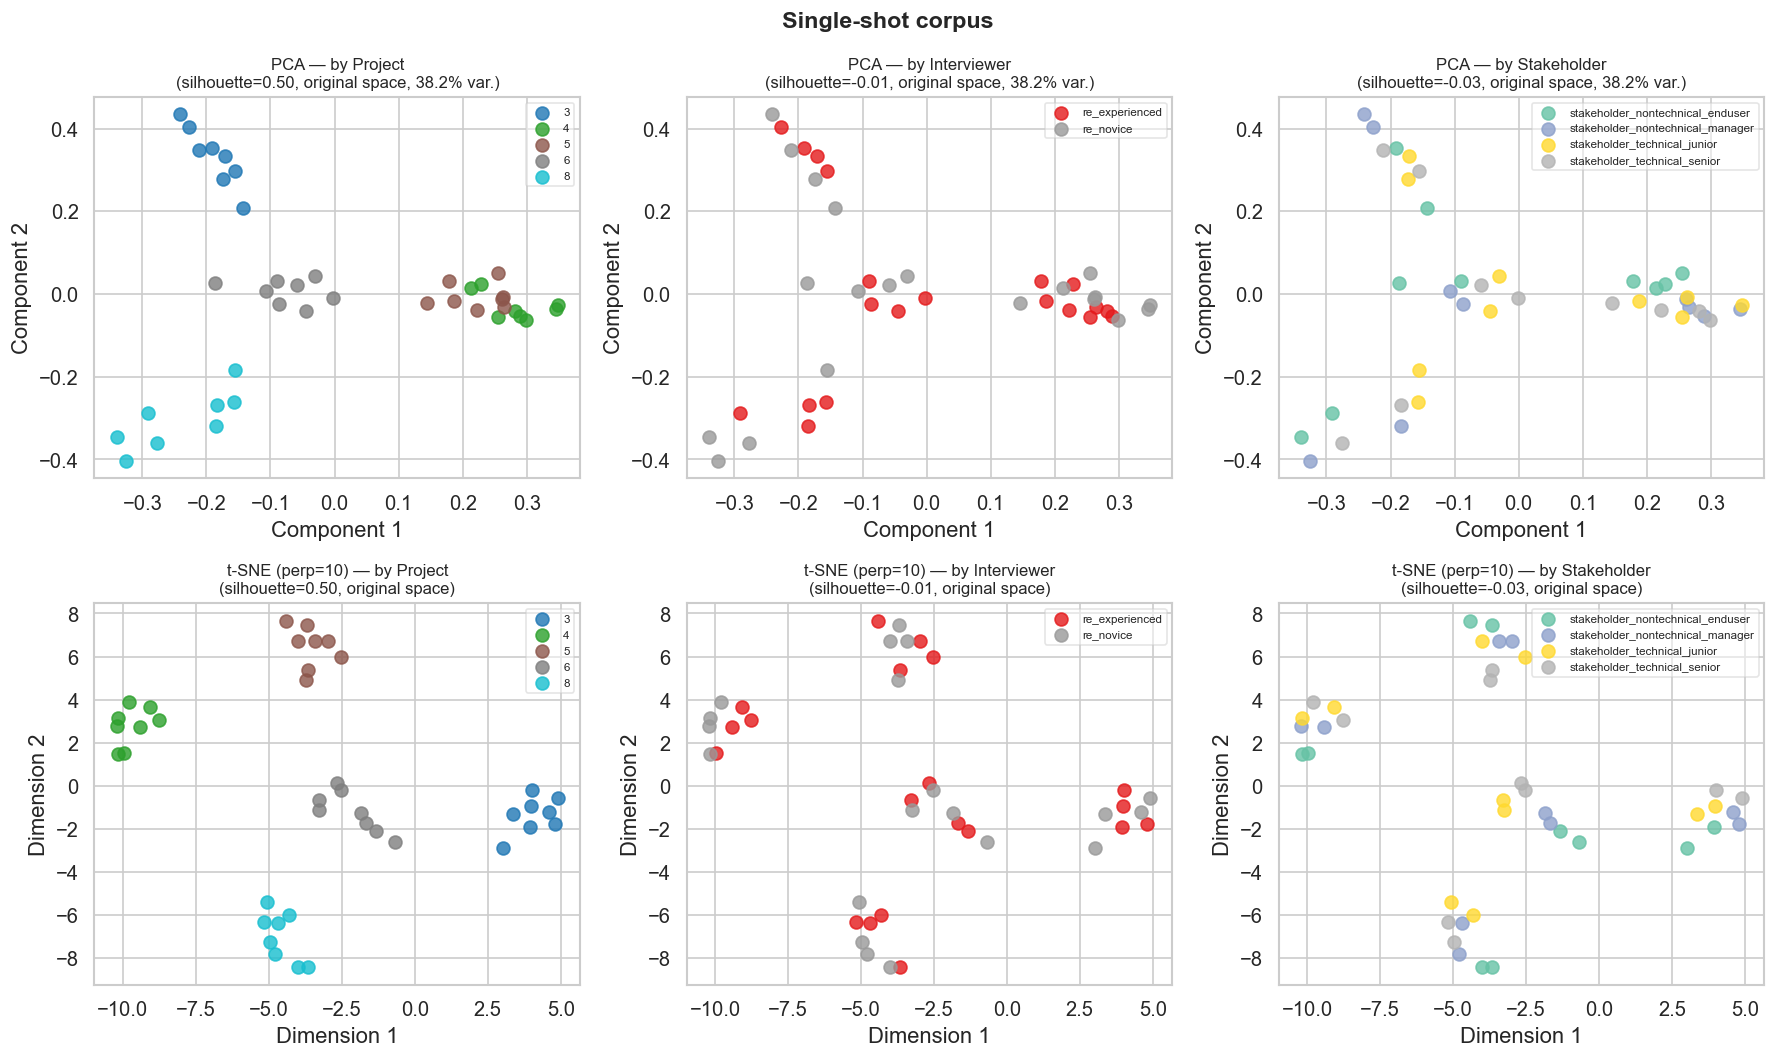

3-step PCA: PC1=21.0%, PC2=17.8%, total=38.8% variance retained


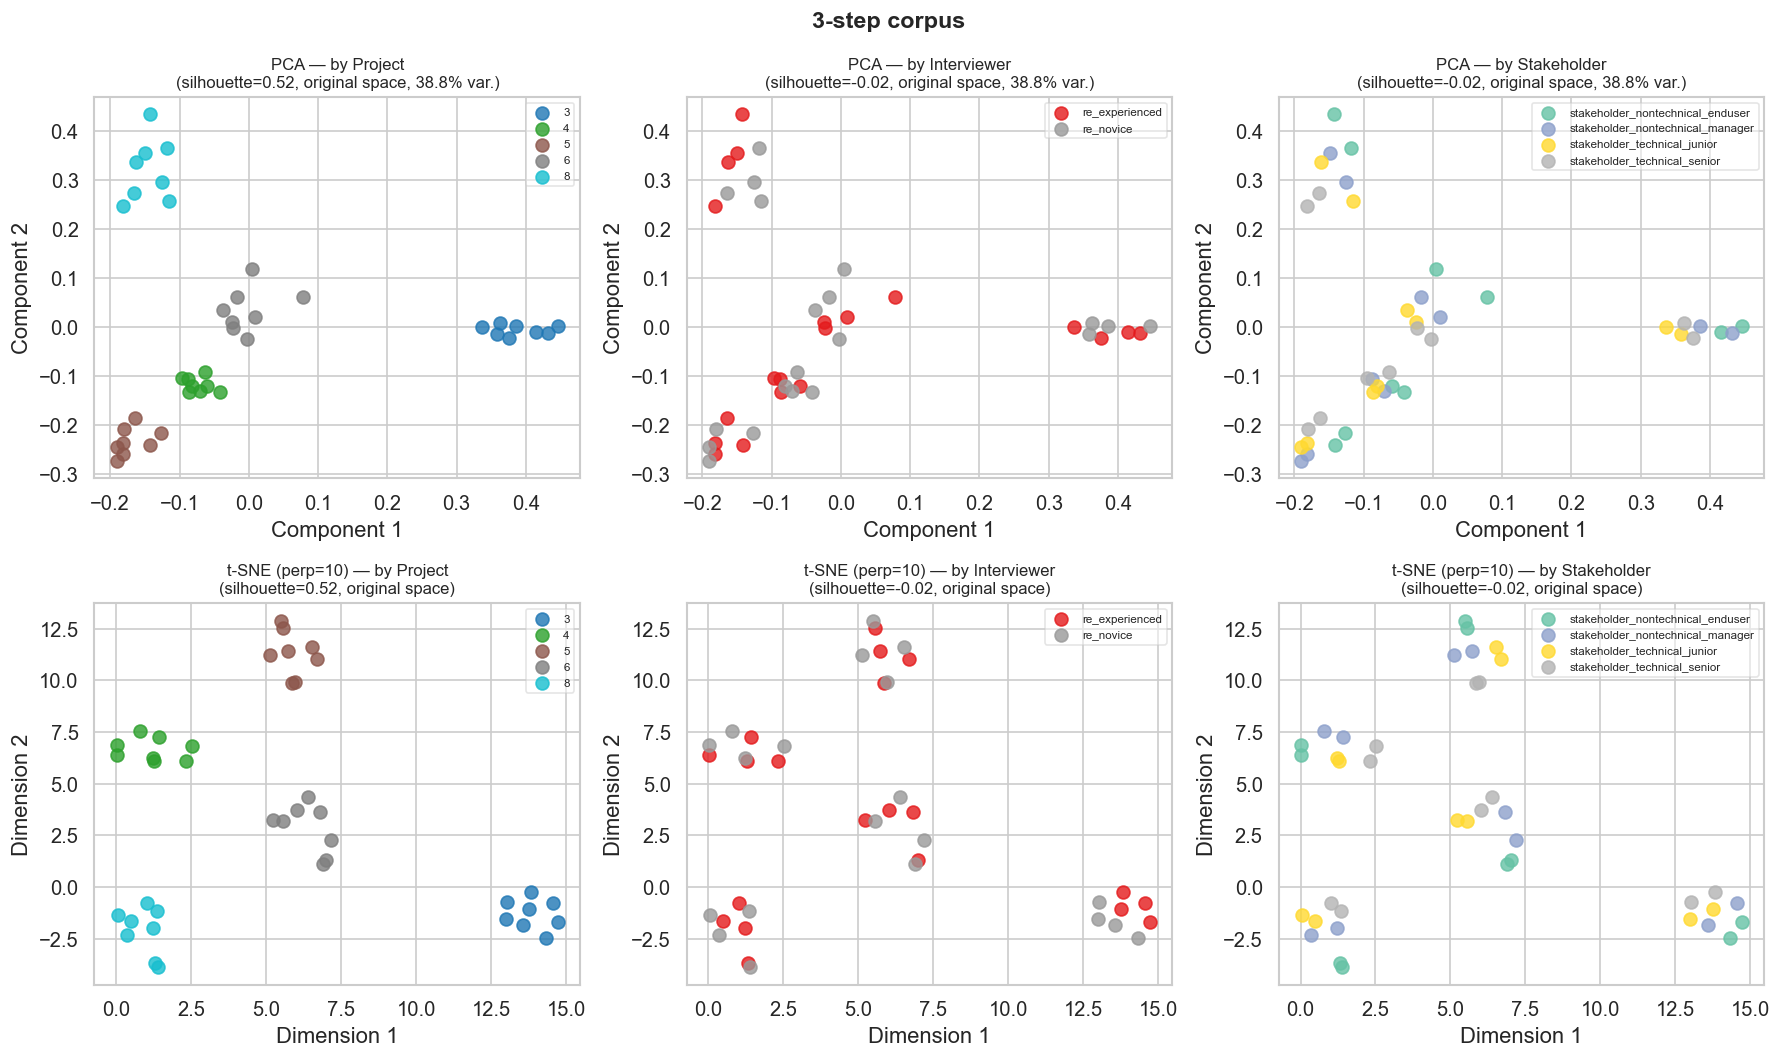

In [6]:
from sklearn.metrics import silhouette_score

def _reduce(X: np.ndarray):
    """Return PCA-2D, t-SNE-2D, and PCA explained variance ratio."""
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    X_tsne = TSNE(
        n_components=2, perplexity=10, init=X_pca, random_state=42, learning_rate="auto"
    ).fit_transform(X)
    return X_pca, X_tsne, pca.explained_variance_ratio_


def plot_embedding_grid(
    df: pd.DataFrame,
    X_orig: np.ndarray,
    X_pca: np.ndarray,
    X_tsne: np.ndarray,
    title: str,
    var_explained=None,
):
    """
    2 rows (PCA / t-SNE) × 3 columns (project / interviewer / stakeholder).
    Silhouette scores are computed once on X_orig (original embedding space, cosine),
    so they reflect true cluster structure — not the distortions introduced by projection.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    groupings = [
        ("project_id",  "Project",     "tab10"),
        ("interviewer", "Interviewer", "Set1"),
        ("stakeholder", "Stakeholder", "Set2"),
    ]

    # Compute silhouette once per grouping on original embeddings — not on projections.
    # t-SNE in particular distorts distances by design, making per-projection scores meaningless.
    sil_scores = {
        col: silhouette_score(X_orig, df[col], metric="cosine")
        for col, _, _ in groupings
    }

    for row, (X_red, method) in enumerate([(X_pca, "PCA"), (X_tsne, "t-SNE (perp=10)")]):
        x_label = "Component 1" if method == "PCA" else "Dimension 1"
        y_label = "Component 2" if method == "PCA" else "Dimension 2"
        for col, (group_col, group_name, cmap) in enumerate(groupings):
            ax = axes[row, col]
            groups = df[group_col].unique()
            colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(groups)))
            for g, c in zip(sorted(groups), colors):
                mask = df[group_col] == g
                ax.scatter(X_red[mask, 0], X_red[mask, 1], label=g, color=c, alpha=0.8, s=60)
            sil = sil_scores[group_col]
            var_str = f", {sum(var_explained):.1%} var." if var_explained is not None and method == "PCA" else ""
            ax.set_title(f"{method} — by {group_name}\n(silhouette={sil:.2f}, original space{var_str})", fontsize=10)
            ax.set_xlabel(x_label); ax.set_ylabel(y_label)
            ax.legend(fontsize=7, loc="best", framealpha=0.5)

    plt.tight_layout()
    plt.show()


X_pca_ss, X_tsne_ss, var_ss = _reduce(X_ss)
print(f"Single-shot PCA: PC1={var_ss[0]:.1%}, PC2={var_ss[1]:.1%}, total={sum(var_ss):.1%} variance retained")
plot_embedding_grid(df_txt_ss, X_ss, X_pca_ss, X_tsne_ss, "Single-shot corpus", var_explained=var_ss)

X_pca_3s, X_tsne_3s, var_3s = _reduce(X_3s)
print(f"3-step PCA: PC1={var_3s[0]:.1%}, PC2={var_3s[1]:.1%}, total={sum(var_3s):.1%} variance retained")
plot_embedding_grid(df_txt_3s, X_3s, X_pca_3s, X_tsne_3s, "3-step corpus", var_explained=var_3s)


In [7]:
from sklearn.preprocessing import LabelEncoder

# ── Silhouette scores on full embeddings (not 2D projections) ─────────────────
# Silhouette score ∈ [-1, 1]: closer to 1 = compact, well-separated clusters.
# We compute this on the raw 768-dim embeddings to avoid distortion from 2D reduction.

print("Silhouette scores on full embeddings (768-dim, cosine distance)")
print("─" * 60)

le = LabelEncoder()
for corpus_label, X, df_txt in [
    ("Single-shot", X_ss, df_txt_ss),
    ("3-step",      X_3s, df_txt_3s),
]:
    print(f"\n  {corpus_label} corpus:")
    for field, display in [("project_id",  "by project"),
                            ("interviewer", "by interviewer"),
                            ("stakeholder", "by stakeholder")]:
        labels = le.fit_transform(df_txt[field])
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(X, labels, metric="cosine")
        print(f"    {display:<18}: silhouette = {score:+.4f}")

print("\nInterpretation: > 0.1 suggests detectable clustering; > 0.3 is moderate; > 0.5 is strong.")


Silhouette scores on full embeddings (768-dim, cosine distance)
────────────────────────────────────────────────────────────

  Single-shot corpus:
    by project        : silhouette = +0.4983
    by interviewer    : silhouette = -0.0135
    by stakeholder    : silhouette = -0.0293

  3-step corpus:
    by project        : silhouette = +0.5196
    by interviewer    : silhouette = -0.0203
    by stakeholder    : silhouette = -0.0233

Interpretation: > 0.1 suggests detectable clustering; > 0.3 is moderate; > 0.5 is strong.


In [8]:
from sklearn.metrics.pairwise import cosine_distances

print("Within-project stakeholder distance analysis (cosine, per project)")
print("─" * 60)

for corpus_label, X, df_txt in [
    ("Single-shot", X_ss, df_txt_ss),
    ("3-step",      X_3s, df_txt_3s),
]:
    within_dists, between_dists = [], []
    for pid in sorted(df_txt["project_id"].unique()):
        mask = df_txt["project_id"] == pid
        X_proj = X[mask.values]
        stakes = df_txt.loc[mask, "stakeholder"].values
        D = cosine_distances(X_proj)
        n = len(stakes)
        for i in range(n):
            for j in range(i + 1, n):
                (within_dists if stakes[i] == stakes[j] else between_dists).append(D[i, j])

    print(f"{corpus_label}: within-stakeholder={np.mean(within_dists):.4f}, "
          f"between-stakeholder={np.mean(between_dists):.6f}  "
          f"(n={len(within_dists)} within, {len(between_dists)} between)")
    _mwu = pg.mwu(np.asarray(within_dists), np.asarray(between_dists), alternative="less")
    p_val = float(_mwu["p_val"].iloc[0])
    r_rb_emb  = float(_mwu["RBC"].iloc[0])
    interp = "large" if abs(r_rb_emb) >= 0.5 else ("medium" if abs(r_rb_emb) >= 0.3 else "small")
    print(f"  Mann-Whitney (within < between): p={p_val:.6f}")
    print(f"  Effect size: r_rb={abs(r_rb_emb):.3f} ({interp})")


Within-project stakeholder distance analysis (cosine, per project)
────────────────────────────────────────────────────────────
Single-shot: within-stakeholder=0.0960, between-stakeholder=0.130205  (n=20 within, 120 between)
  Mann-Whitney (within < between): p=0.000396
  Effect size: r_rb=0.470 (medium)
3-step: within-stakeholder=0.0686, between-stakeholder=0.109955  (n=20 within, 120 between)
  Mann-Whitney (within < between): p=0.000000
  Effect size: r_rb=0.790 (large)


In [9]:
print("Within-project interviewer distance analysis (cosine, per project)")
print("─" * 60)

for corpus_label, X, df_txt in [
    ("Single-shot", X_ss, df_txt_ss),
    ("3-step",      X_3s, df_txt_3s),
]:
    within_dists, between_dists = [], []
    for pid in sorted(df_txt["project_id"].unique()):
        mask = df_txt["project_id"] == pid
        X_proj = X[mask.values]
        iviews = df_txt.loc[mask, "interviewer"].values
        D = cosine_distances(X_proj)
        n = len(iviews)
        for i in range(n):
            for j in range(i + 1, n):
                (within_dists if iviews[i] == iviews[j] else between_dists).append(D[i, j])

    print(f"{corpus_label}: within-interviewer={np.mean(within_dists):.4f}, "
          f"between-interviewer={np.mean(between_dists):.6f}  "
          f"(n={len(within_dists)} within, {len(between_dists)} between)")
    _mwu = pg.mwu(np.asarray(within_dists), np.asarray(between_dists), alternative="less")
    p_val = float(_mwu["p_val"].iloc[0])
    r_rb_emb  = float(_mwu["RBC"].iloc[0])
    interp = "large" if abs(r_rb_emb) >= 0.5 else ("medium" if abs(r_rb_emb) >= 0.3 else "small")
    print(f"  Mann-Whitney (within < between): p={p_val:.6f}")
    print(f"  Effect size: r_rb={abs(r_rb_emb):.3f} ({interp})")


Within-project interviewer distance analysis (cosine, per project)
────────────────────────────────────────────────────────────
Single-shot: within-interviewer=0.1269, between-interviewer=0.124131  (n=60 within, 80 between)
  Mann-Whitney (within < between): p=0.605413
  Effect size: r_rb=0.026 (small)
3-step: within-interviewer=0.1077, between-interviewer=0.101332  (n=60 within, 80 between)
  Mann-Whitney (within < between): p=0.894074
  Effect size: r_rb=0.123 (small)


## Transcript Embedding Analysis — Summary

We tested whether SQuIRE's synthetic transcripts are meaningfully different
from each other, or whether the LLM produces homogeneous "AI-style" dialogue
regardless of the project or persona.

### What we did

We converted each transcript into a mathematical fingerprint (an embedding)
that captures its semantic content. We then measured how similar these
fingerprints are to each other, and whether transcripts with the same project,
stakeholder type, or interviewer type tend to be more similar.

We used two types of analysis:

1. **Silhouette scoring** — measures how tightly grouped transcripts of the
   same type are across the entire corpus. A score near +1 means clear
   grouping; near 0 means no detectable pattern.

2. **Within-project distance analysis** — for each project separately, we
   measured whether two transcripts involving the same stakeholder type are
   more similar to each other than to transcripts from a different stakeholder
   type. We tested whether this pattern is statistically reliable using the
   Mann-Whitney U test, which works correctly even when comparing groups of
   different sizes.

### What we found

Transcripts cluster strongly by **project domain** (silhouette ≈ +0.50),
confirming that SQuIRE encodes project-specific knowledge rather than
producing generic AI dialogue.

Within each project, transcripts involving the **same stakeholder type** are
significantly closer to each other than transcripts from different stakeholder
types (p < 0.001 in both corpus variants). This holds even though the only
variable differing within each comparison is the stakeholder — the project
domain is identical for all transcripts being compared.

By contrast, **interviewer persona** produces no detectable grouping
(p ≈ 0.61–0.89), meaning the requirements engineer's experience level does
not measurably shape the content of the resulting transcript.

### Conclusion

SQuIRE's synthetic transcripts reflect a two-level structure: project domain
determines the broad topics covered, while stakeholder background shapes how
those topics are expressed within a given project. Interviewer persona produces
no detectable effect on content.

This pattern is not an emergent discovery — it is a direct consequence of
deliberate design decisions in the synthesis prompt, confirmed to be working
as intended by the embedding analysis.

**Why requirements surface through the stakeholder, not the interviewer.**
Early synthesis attempts produced unrealistic transcripts in which the
requirements engineer effectively listed requirements directly, or in which
requirements appeared regardless of who introduced them. In a real elicitation
interview, the RE's role is to create conditions for the stakeholder to
articulate their needs — it is the interviewee who holds domain knowledge and
lived experience, not the interviewer. The prompt therefore explicitly
instructs the LLM to route all requirements through the stakeholder's voice
(Rule 1: *"Requirements emerge because the STAKEHOLDER is forthcoming about
their frustrations"*). The interviewer's persona controls style — how questions
are framed, how deeply the RE probes — but not which topics are covered.

**Why all requirements are always covered.** A second design constraint
requires the LLM to encode all 10 selected requirements into every transcript,
regardless of interviewer skill level. This was a pragmatic necessity: a truly
novice interviewer might realistically miss requirements entirely, but a
transcript with missing ground truth items cannot serve as a reliable
evaluation corpus for TRACE. The trade-off is a reduction in ecological
validity — real novice-led interviews may leave requirements uncovered — in
exchange for ground truth completeness.

**What the embedding analysis therefore shows.** The statistically significant
within-project stakeholder clustering (Mann-Whitney p < 0.001) and the absence
of interviewer clustering (p ≈ 0.61–0.89) confirm that the LLM follows the
synthesis prompt as intended: requirements surface through the stakeholder's
persona, and the interviewer's persona shapes style but not content. This
serves as a behavioural validity check on the synthesis pipeline rather than
an independent empirical finding about LLM behaviour in general.

One consequence of the "all requirements covered" constraint is that the corpus
is more complete than a real interview might be. This is a known limitation:
the transcripts represent an idealised version of elicitation in which no
requirements are missed, which may not reflect the performance of a novice RE
in practice.


---
## 3. RQ1 — SQuIRE Synthesis Quality <a id='rq1'></a>

**RQ1:** *Can an LLM reliably create a synthetic ground truth corpus of interview transcripts for quality requirements elicitation?*

Evaluation uses two independent G-Eval passes (GPT-5-mini judge, 3 samples each):
- **Quality G-Eval** (blind — no persona context): 4 dimensions, derived from literature [1] — structuring, clarity, responsiveness, rigor
- **Meta G-Eval** (full context): completeness, realism
- **BERTScore**: transcript vs. all project requirements from NICE.csv

> [1]: Pp. 68-69, Brand et al., CPRE Handbook Requirements Elicitation Practicioner. 

In [10]:
df_ss = load_squire_transcripts(SQUIRE_SINGLE_SHOT)
df_3s = load_squire_transcripts(SQUIRE_3STEP)
df_ss["pipeline"] = "single-shot"
df_3s["pipeline"] = "3-step"
df_squire = pd.concat([df_ss, df_3s], ignore_index=True)

print(f"Loaded {len(df_ss)} single-shot + {len(df_3s)} 3-step transcripts")
print()
df_squire[["pipeline", "project_id", "interviewer", "stakeholder",
           "quality", "meta", "bert_f1"]].head(6)


Loaded 40 single-shot + 40 3-step transcripts



,pipeline,project_id,interviewer,stakeholder,quality,meta,bert_f1
0,single-shot,3,re_experienced,stakeholder_nontechnical_enduser,7.420,9.330,0.785
1,single-shot,3,re_experienced,stakeholder_nontechnical_manager,7.750,9.000,0.792
2,single-shot,3,re_experienced,stakeholder_technical_junior,7.330,9.170,0.797
3,single-shot,3,re_experienced,stakeholder_technical_senior,7.330,9.500,0.797
4,single-shot,3,re_novice,stakeholder_nontechnical_enduser,7.080,9.170,0.793
5,single-shot,3,re_novice,stakeholder_nontechnical_manager,7.170,9.330,0.805


In [11]:
# ── Overall stats: single-shot vs 3-step ─────────────────────────────────────
metrics = ["quality", "structuring", "clarity", "responsiveness",
           "rigor", "meta", "completeness", "realism", "bert_f1"]

# Display as mean ± SD [95% bootstrap CI]
display_rows = {}
for pipeline, grp in df_squire.groupby("pipeline", sort=False):
    display_rows[pipeline] = {}
    for m in metrics:
        mu      = grp[m].mean()
        sd      = grp[m].std(ddof=1)
        lo, hi  = _bstrap_ci(grp[m])
        display_rows[pipeline][m] = f"{mu:.2f} ± {sd:.2f} [{lo:.2f}–{hi:.2f}]"

tbl_display = pd.DataFrame(display_rows).T
tbl_display.columns.name = "metric"
print("Table 1 — Overall SQuIRE Evaluation Scores (mean ± SD [95% bootstrap CI], n=40 per pipeline)")
tbl_display


Table 1 — Overall SQuIRE Evaluation Scores (mean ± SD [95% bootstrap CI], n=40 per pipeline)


metric,quality,structuring,clarity,responsiveness,rigor,meta,completeness,realism,bert_f1
single-shot,7.22 ± 0.36 [7.11–7.33],6.96 ± 0.41 [6.83–7.08],7.83 ± 0.41 [7.71–7.96],7.60 ± 0.39 [7.47–7.72],6.50 ± 0.52 [6.33–6.65],9.07 ± 0.37 [8.96–9.18],9.38 ± 0.67 [9.17–9.57],8.78 ± 0.24 [8.70–8.85],0.80 ± 0.01 [0.80–0.80]
3-step,7.49 ± 0.31 [7.40–7.59],7.21 ± 0.40 [7.09–7.33],8.04 ± 0.33 [7.94–8.14],7.76 ± 0.33 [7.66–7.86],6.96 ± 0.41 [6.83–7.08],8.89 ± 0.37 [8.78–9.01],9.13 ± 0.63 [8.94–9.32],8.65 ± 0.30 [8.56–8.74],0.80 ± 0.00 [0.79–0.80]


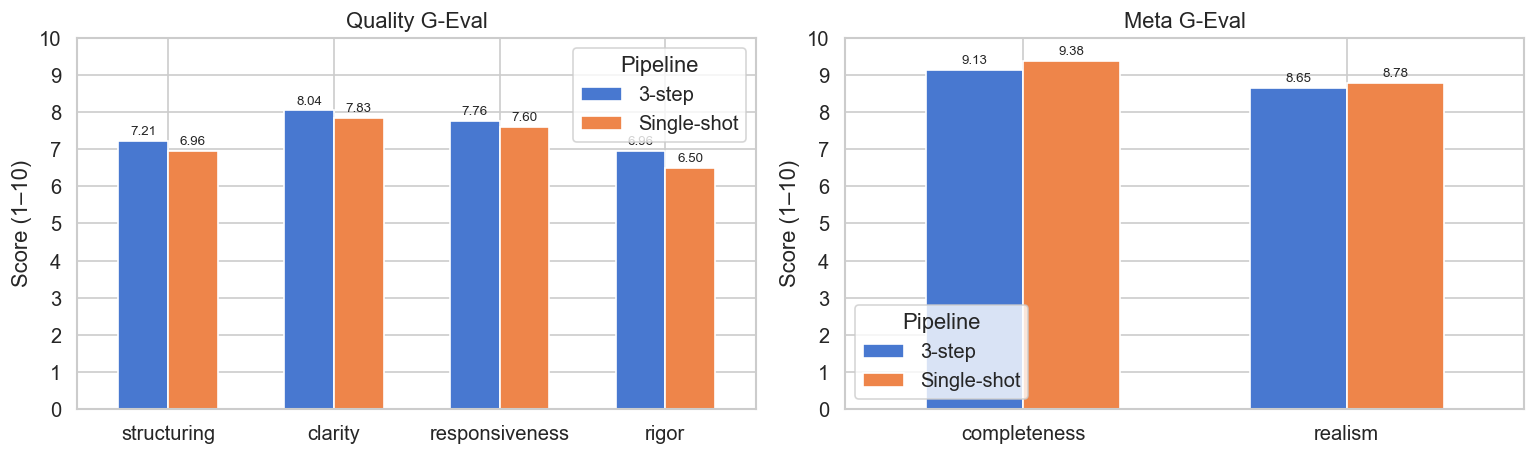

In [12]:
# ── G-Eval quality dimensions: grouped bar chart ──────────────────────────────
q_dims = ["structuring", "clarity", "responsiveness", "rigor"]
m_dims = ["completeness", "realism"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, dims, title in [
    (axes[0], q_dims, "Quality G-Eval"),
    (axes[1], m_dims, "Meta G-Eval"),
]:
    data = (
        df_squire.groupby("pipeline")[dims].mean()
        .rename(index={"single-shot": "Single-shot", "3-step": "3-step"})
    )
    data.T.plot(kind="bar", ax=ax, width=0.6, rot=0)
    ax.set_ylim(0, 10)
    ax.set_ylabel("Score (1–10)")
    ax.set_title(title)
    ax.legend(title="Pipeline")
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()


In [13]:
# ── By-interviewer breakdown + Mann-Whitney U test ───────────────────────────
print("Table 2 — Quality scores by interviewer persona (n=20 per pipeline each)")
print("         Format: mean ± SD [95% bootstrap CI]")

for pipeline, df_p in df_squire.groupby("pipeline"):
    print(f"\n  Pipeline: {pipeline}")
    dims = ["quality", "structuring", "clarity", "responsiveness", "rigor", "meta"]
    display_grp = {}
    for col_base in dims:
        col_vals = {}
        for iview_key in sorted(df_p["interviewer"].unique()):
            series = df_p.loc[df_p["interviewer"] == iview_key, col_base]
            lo, hi = _bstrap_ci(series)
            col_vals[INTERVIEWER_LABELS.get(iview_key, iview_key)] = (
                f"{series.mean():.2f} ± {series.std():.2f} [{lo:.2f}–{hi:.2f}]"
            )
        display_grp[col_base] = col_vals
    print(pd.DataFrame(display_grp).to_string())

    # Mann-Whitney U: novice vs experienced on quality
    nov = df_p.loc[df_p["interviewer"] == "re_novice", "quality"]
    exp = df_p.loc[df_p["interviewer"] == "re_experienced", "quality"]
    _mwu = pg.mwu(np.asarray(exp), np.asarray(nov), alternative="greater")
    p_val = float(_mwu["p_val"].iloc[0])
    r_rb  = float(_mwu["RBC"].iloc[0])
    interp = "large" if abs(r_rb) >= 0.5 else ("medium" if abs(r_rb) >= 0.3 else "small")
    mean_diff = exp.mean() - nov.mean()
    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"  Interviewer effect ({sig}): p={p_val:.4f}")
    if p_val < 0.05:
        print(f"    Mean diff (experienced − novice): {mean_diff:+.3f}")
        print(f"    Effect size: r_rb={abs(r_rb):.3f} ({interp})")


Table 2 — Quality scores by interviewer persona (n=20 per pipeline each)
         Format: mean ± SD [95% bootstrap CI]

  Pipeline: 3-step
                                quality              structuring                  clarity           responsiveness                    rigor                     meta
Experienced RE  7.73 ± 0.20 [7.65–7.81]  7.45 ± 0.34 [7.31–7.59]  8.26 ± 0.24 [8.16–8.37]  7.99 ± 0.21 [7.90–8.08]  7.21 ± 0.29 [7.09–7.33]  9.00 ± 0.37 [8.85–9.17]
Novice RE       7.25 ± 0.20 [7.17–7.34]  6.97 ± 0.30 [6.84–7.10]  7.82 ± 0.24 [7.72–7.92]  7.53 ± 0.25 [7.42–7.63]  6.70 ± 0.36 [6.55–6.85]  8.78 ± 0.34 [8.63–8.92]
  Interviewer effect (✓ significant): p=0.0000
    Mean diff (experienced − novice): +0.472
    Effect size: r_rb=0.925 (large)

  Pipeline: single-shot
                                quality              structuring                  clarity           responsiveness                    rigor                     meta
Experienced RE  7.50 ± 0.17 [7.44–7.58]  7.20 ± 

In [14]:
# ── By-stakeholder breakdown ──────────────────────────────────────────────────
import pingouin as pg

print("Table 3 — Quality scores by stakeholder persona (n=10 per pipeline each)")
print("         Format: mean ± SD [95% bootstrap CI]")

for pipeline, df_p in df_squire.groupby("pipeline"):
    print(f"\n  Pipeline: {pipeline}")
    dims = ["quality", "meta", "completeness", "realism"]
    display_grp = {}
    for col_base in dims:
        col_vals = {}
        for stk_key in sorted(df_p["stakeholder"].unique()):
            series = df_p.loc[df_p["stakeholder"] == stk_key, col_base]
            lo, hi = _bstrap_ci(series)
            col_vals[STAKEHOLDER_LABELS.get(stk_key, stk_key)] = (
                f"{series.mean():.2f} ± {series.std():.2f} [{lo:.2f}–{hi:.2f}]"
            )
        display_grp[col_base] = col_vals
    print(pd.DataFrame(display_grp).to_string())

    # Kruskal-Wallis test across stakeholder groups
    _kw = pg.kruskal(df_p, dv="quality", between="stakeholder")
    h_stat  = float(_kw["H"].iloc[0])
    p_val   = float(_kw["p_unc"].iloc[0])
    n_total = len(df_p)
    eps_sq  = h_stat / (n_total - 1)
    interp = "large" if eps_sq >= 0.14 else ("medium" if eps_sq >= 0.06 else "small")
    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"  Stakeholder effect ({sig}): H={h_stat:.3f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"    Effect size: ε²={eps_sq:.3f} ({interp})")
    else:
        print(f"    Effect size (reported regardless): ε²={eps_sq:.3f} ({interp})")


Table 3 — Quality scores by stakeholder persona (n=10 per pipeline each)
         Format: mean ± SD [95% bootstrap CI]

  Pipeline: 3-step


                                   quality                     meta             completeness                  realism
End User           7.43 ± 0.39 [7.21–7.66]  8.82 ± 0.49 [8.53–9.10]  8.98 ± 0.81 [8.46–9.42]  8.66 ± 0.31 [8.48–8.84]
Non-tech. Manager  7.52 ± 0.21 [7.39–7.64]  8.88 ± 0.36 [8.67–9.10]  9.24 ± 0.53 [8.92–9.54]  8.52 ± 0.27 [8.36–8.68]
Tech. Junior       7.48 ± 0.30 [7.30–7.65]  8.86 ± 0.29 [8.69–9.03]  9.00 ± 0.58 [8.64–9.32]  8.72 ± 0.33 [8.52–8.90]
Tech. Senior       7.54 ± 0.34 [7.34–7.74]  9.01 ± 0.34 [8.82–9.21]  9.32 ± 0.58 [8.96–9.64]  8.70 ± 0.30 [8.52–8.88]
  Stakeholder effect (✗ not significant): H=0.414, p=0.9372
    Effect size (reported regardless): ε²=0.011 (small)

  Pipeline: single-shot
                                   quality                     meta             completeness                  realism
End User           7.14 ± 0.39 [6.91–7.37]  9.02 ± 0.31 [8.82–9.18]  9.24 ± 0.57 [8.87–9.54]  8.80 ± 0.23 [8.67–8.93]
Non-tech. Manager  7.30 ± 0.28 [7

In [15]:
# ── By-project breakdown ──────────────────────────────────────────────────────
print("Table 4 — Quality scores by project (n=8 per pipeline each)")
print("         Format: mean ± SD [95% bootstrap CI]")

for pipeline, df_p in df_squire.groupby("pipeline"):
    print(f"\n  Pipeline: {pipeline}")
    dims = ["quality", "meta", "bert_f1"]
    display_grp = {}
    for col_base in dims:
        col_vals = {}
        for pid in sorted(df_p["project_id"].unique()):
            series = df_p.loc[df_p["project_id"] == pid, col_base]
            lo, hi = _bstrap_ci(series)
            proj_label = f"[{pid}] {PROJECT_NAMES.get(pid, pid)}"
            col_vals[proj_label] = (
                f"{series.mean():.2f} ± {series.std():.2f} [{lo:.2f}–{hi:.2f}]"
            )
        display_grp[col_base] = col_vals
    print(pd.DataFrame(display_grp).to_string())


Table 4 — Quality scores by project (n=8 per pipeline each)
         Format: mean ± SD [95% bootstrap CI]

  Pipeline: 3-step
                                           quality                     meta                  bert_f1
[3] Nursing Scheduling     7.52 ± 0.34 [7.30–7.74]  8.84 ± 0.28 [8.66–9.02]  0.80 ± 0.00 [0.80–0.80]
[4] Credit Card Disputes   7.53 ± 0.25 [7.36–7.68]  9.08 ± 0.32 [8.87–9.28]  0.79 ± 0.01 [0.79–0.80]
[5] Recycled Parts Mgmt    7.54 ± 0.23 [7.40–7.69]  8.86 ± 0.53 [8.50–9.19]  0.79 ± 0.00 [0.79–0.80]
[6] Conference Room Mgmt   7.44 ± 0.43 [7.16–7.72]  8.85 ± 0.42 [8.60–9.15]  0.80 ± 0.01 [0.79–0.80]
[8] IzognMovies Streaming  7.43 ± 0.31 [7.23–7.63]  8.84 ± 0.28 [8.66–9.03]  0.80 ± 0.00 [0.79–0.80]

  Pipeline: single-shot
                                           quality                     meta                  bert_f1
[3] Nursing Scheduling     7.26 ± 0.27 [7.09–7.44]  9.27 ± 0.18 [9.17–9.38]  0.80 ± 0.01 [0.79–0.80]
[4] Credit Card Disputes   7.21 ± 0.36 [6

In [16]:
# ── Per-selected-requirement similarity (negative control) ────────────────────
# Each transcript was generated from 10 specifically selected requirements.
# Hypothesis: in Gemma's embedding space the transcript is geometrically closer
# to its own 10 selected requirements than to 10 requirements selected for a
# transcript from a different project (same persona — controls for persona effects).
#
# own_sim   = cosine_sim(transcript_emb, centroid(own 10 req embeddings))
# wrong_sim = cosine_sim(transcript_emb, centroid(wrong-project 10 req embeddings))
# Expect: delta = own_sim − wrong_sim > 0 across all 40 transcripts.

import transformers
transformers.logging.set_verbosity_error()

CORPUS_PROJECTS = ["3", "4", "5", "6", "8"]

def _wrong_project(pid: str) -> str:
    """Next project in corpus cycle — systematic, deterministic wrong reference."""
    return CORPUS_PROJECTS[(CORPUS_PROJECTS.index(pid) + 1) % len(CORPUS_PROJECTS)]

def _req_centroid(reqs: list[str], emb_map: dict) -> np.ndarray:
    c = np.stack([emb_map[r] for r in reqs]).mean(axis=0)
    return c / np.linalg.norm(c)  # re-normalise after averaging

all_sim_records = []

_tbl_labels = {
    "Single-shot": "Table 5a — Per-Selected-Requirement Cosine Similarity (Gemma)",
    "3-step":      "Table 5b — Per-Selected-Requirement Cosine Similarity (Gemma)",
}

for corpus_label, corpus_dir, df_txt, X in [
    ("Single-shot", SQUIRE_SINGLE_SHOT, df_txt_ss, X_ss),
    ("3-step",      SQUIRE_3STEP,       df_txt_3s, X_3s),
]:
    # Load selected requirements from every sidecar in this corpus
    sidecar_map: dict[tuple, list[str]] = {}
    for f in sorted(corpus_dir.glob("transcript_*.json")):
        pid, iview, stake = _parse_fname(f.stem)
        d = json.loads(f.read_text())
        sidecar_map[(pid, iview, stake)] = [r["text"] for r in d["selected_requirements"]]

    # Embed all unique requirement texts in one batch
    unique_req_texts = list({t for reqs in sidecar_map.values() for t in reqs})
    unique_req_embs  = _embed_model.encode(
        unique_req_texts, normalize_embeddings=True, show_progress_bar=False, batch_size=64
    )
    req_emb_map = dict(zip(unique_req_texts, unique_req_embs))

    # Compute similarities for every transcript
    records = []
    for i, row in df_txt.reset_index(drop=True).iterrows():
        pid, iview, stake = row["project_id"], row["interviewer"], row["stakeholder"]
        wpid = _wrong_project(pid)

        own_centroid   = _req_centroid(sidecar_map[(pid,  iview, stake)], req_emb_map)
        wrong_centroid = _req_centroid(sidecar_map[(wpid, iview, stake)], req_emb_map)

        t_emb     = X[i]
        own_sim   = float(t_emb @ own_centroid)
        wrong_sim = float(t_emb @ wrong_centroid)

        records.append({
            "pipeline":         corpus_label,
            "file":             row["file"],
            "project_id":       pid,
            "wrong_project_id": wpid,
            "own_sim":          own_sim,
            "wrong_sim":        wrong_sim,
            "delta":            own_sim - wrong_sim,
        })

    df_sim = pd.DataFrame(records)
    all_sim_records.extend(records)

    t_stat, p_val = stats.ttest_rel(df_sim["own_sim"], df_sim["wrong_sim"])
    w_stat, p_wil = stats.wilcoxon(df_sim["delta"], alternative="greater")

    print(f"{_tbl_labels[corpus_label]} ({corpus_label}, n={len(df_sim)})")
    print(f"  Own-project   mean sim: {df_sim['own_sim'].mean():.4f} ± {df_sim['own_sim'].std():.4f}")
    print(f"  Wrong-project mean sim: {df_sim['wrong_sim'].mean():.4f} ± {df_sim['wrong_sim'].std():.4f}")
    print(f"  Mean Δ (own − wrong):   {df_sim['delta'].mean():.4f} ± {df_sim['delta'].std():.4f}")
    print(f"  Paired t-test:          t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'}")
    cohen_d = df_sim["delta"].mean() / df_sim["delta"].std()
    print(f"  Cohen's d (paired):     {cohen_d:.3f} (very large)")
    print(f"  Wilcoxon (one-sided):   W={w_stat:.0f}, p={p_wil:.4f} {'***' if p_wil < 0.001 else '**' if p_wil < 0.01 else '*' if p_wil < 0.05 else 'n.s.'}")
    print(f"  Transcripts with Δ > 0: {(df_sim['delta'] > 0).sum()}/{len(df_sim)}")
    grp = df_sim.groupby("project_id")[["own_sim", "wrong_sim", "delta"]].mean()
    grp.index = grp.index.map(lambda p: f"[{p}] {PROJECT_NAMES.get(p, p)}")
    grp.columns = ["Own sim", "Wrong sim", "Δ"]
    print(grp.round(4).to_string())
    print()

df_sim_all = pd.DataFrame(all_sim_records)


Table 5a — Per-Selected-Requirement Cosine Similarity (Gemma) (Single-shot, n=40)
  Own-project   mean sim: 0.4844 ± 0.0498
  Wrong-project mean sim: 0.3343 ± 0.0437
  Mean Δ (own − wrong):   0.1501 ± 0.0682
  Paired t-test:          t=13.915, p=0.0000 ***
  Cohen's d (paired):     2.200 (very large)
  Wilcoxon (one-sided):   W=819, p=0.0000 ***
  Transcripts with Δ > 0: 39/40
                           Own sim  Wrong sim     Δ
project_id                                         
[3] Nursing Scheduling       0.494      0.279 0.214
[4] Credit Card Disputes     0.544      0.349 0.195
[5] Recycled Parts Mgmt      0.464      0.370 0.094
[6] Conference Room Mgmt     0.462      0.360 0.102
[8] IzognMovies Streaming    0.458      0.313 0.145

Table 5b — Per-Selected-Requirement Cosine Similarity (Gemma) (3-step, n=40)
  Own-project   mean sim: 0.4650 ± 0.0316
  Wrong-project mean sim: 0.3435 ± 0.0416
  Mean Δ (own − wrong):   0.1215 ± 0.0558
  Paired t-test:          t=13.765, p=0.0000 ***
  C

### RQ1 — SQuIRE Synthesis Quality: Summary

#### What we did
We evaluated 80 synthetic interview transcripts (40 single-shot, 40 three-step) across
five software projects using three independent instruments. A *Quality G-Eval* pass
assessed four interviewer dimensions [1] (structuring, clarity, responsiveness, rigor)
without any persona context — the judge saw only the transcript and project summary.
A separate *Meta G-Eval* pass rated completeness and realism with full context,
including the encoded requirements and both persona descriptions. BERTScore provided a
semantic floor check against all NICE.csv requirements for the respective project.

To further validate that transcripts are genuinely content-driven rather than generic
software dialogue, we ran a geometric similarity test in Gemma's embedding space
(the same model used for the diversity analysis in Section 2.5). For each transcript
we computed cosine similarity against the centroid of its own 10 selected requirements
and against the centroid of 10 requirements selected for a transcript from a different
project — same persona, different domain — as a controlled negative baseline.

#### What we found
The three-step pipeline consistently outperformed single-shot on all four quality
dimensions (overall mean 7.49 vs. 7.22), with the largest gain on rigor (+0.46).
Single-shot scored slightly higher on meta completeness (9.38 vs. 9.13) — consistent
with the pilot study finding that more structured dialogue naturalises requirements
more deeply, making them harder for the judge to surface explicitly.

Interviewer persona had a strong, statistically significant effect on quality scores:
experienced RE transcripts outscored novice RE transcripts in both pipelines
(Mann-Whitney U, p < 0.001, |r_rb| ≈ 0.93), despite the judge being blind to any
persona labels.

> **Multiple testing note.** Two significance tests are reported in RQ1 (interviewer effect, stakeholder effect), both pre-specified by design. With two tests the Bonferroni threshold is p < 0.025; the interviewer effect (p < 0.001) easily clears this. Stakeholder persona had no significant effect on quality
(Kruskal-Wallis H ≈ 0.4–0.6, p ≈ 0.89–0.94). Results were stable across all five
projects (quality range 7.12–7.54, BERTScore 0.79–0.80 throughout).

Rigor was the lowest dimension in both pipelines (6.50 single-shot, 6.96 three-step).
This is consistent with the experimental design: novice RE prompts explicitly suppress
probing behaviour, and even experienced RE transcripts prioritise conversational
naturalism over intensive verification. Adequate meta scores across all conditions
(≥ 8.78) confirm that low rigor does not indicate a failure to encode requirements.

The per-selected-requirement similarity test produced a mean delta of **+0.150**
(own: 0.484, wrong: 0.334; paired t-test t=13.9, p<0.001; Wilcoxon W=819, p<0.001),
with 39/40 transcripts showing higher similarity to their own requirements than to
the wrong-project baseline. This result is independent of the LLM judge: it is a
purely geometric measurement on raw transcript text (replicated in the 3-step corpus).

#### Conclusion
SQuIRE reliably produces synthetic interview transcripts whose conversational quality
is meaningfully differentiated by interviewer expertise — detectable by a blind
automated judge — while remaining invariant to stakeholder persona and project domain.
The system successfully encodes the full set of selected requirements across all
conditions (meta completeness ≥ 8.78), at the cost of a moderate quality–completeness
trade-off between pipeline modes: the three-step pipeline produces higher-quality
elicitation behaviour at the expense of slightly less explicit requirement coverage, a
trade-off consistent with the design goal of naturalistic requirement embedding.
BERTScore serves as a corpus health check rather than a discriminative metric;
its consistency across all 80 transcripts confirms semantic coherence and absence of
model degradation.

The geometric similarity test provides orthogonal, judge-independent evidence that
transcripts are content-driven: each transcript is geometrically anchored to its own
selected requirements in embedding space (39/40, Δ=+0.150, p<0.001), confirming that
the generation process is not arbitrary and that the G-Eval scores reflect real
content differences rather than evaluator leniency or distributional collapse.

Taken together, these results support a positive answer to RQ1: an LLM-based pipeline
can reliably synthesise a ground-truth corpus of quality requirements elicitation
interviews with controlled, measurable variation in interviewer competence.

> Stakeholder persona shapes the topics and vocabulary of the transcript (evidenced by within-project embedding clusters), while interviewer expertise shapes the interview's conversational quality (evidenced by G-Eval discrimination). The two effects are orthogonal by design.

> [1]: Pp. 68-69, Brand et al., CPRE Handbook Requirements Elicitation Practicioner.


---
## 4. RQ2 — TRACE Extraction Accuracy: Cross-Model & Temperature <a id='rq2-accuracy'></a>

**RQ2:** *How accurately can an LLM-based system extract and classify quality requirements from unstructured transcripts?*

All runs used `openai/gpt-5-mini` as the evaluation judge. Metrics:
- **F1** = harmonic mean of precision and recall (hit threshold: `overlap_score ≥ 3` out of 5)
- **QA accuracy** = fraction of text-retrieval hits with correct quality attribute label (independent of F1)
- **Extracted count** = number of requirements extracted per transcript (primary driver of precision/recall tradeoff)


In [17]:
# Load all TRACE per-transcript data
df_trace = load_all_trace_runs(TRACE_MANIFEST)
print(f"Loaded {len(df_trace)} per-transcript entries across {df_trace['run_label'].nunique()} runs")
df_trace.head(3)


Loaded 400 per-transcript entries across 8 runs


/var/folders/j_/ld_301rx7n163rp7j2sk5_vr0000gn/T/ipykernel_87004/4155823963.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)


,run_label,corpus,model,temp,group,phase,transcript,project_id,interviewer,stakeholder,extracted_count,hit_count,ground_truth_count,precision,recall,f1,quality_attribute_accuracy,avg_confidence,avg_overlap_score,avg_confidence_quality,avg_rationale_quality,avg_gap_detection_quality
0,Mistral Small T=0.0,single-shot,mistral-small,0.000,temp,exploratory,transcript_3_re_experienced_stakeholder_nontec...,3,re_experienced,stakeholder_nontechnical_enduser,15,10,10,0.667,1.000,0.800,0.800,4.000,3.800,4.067,3.733,3.400
1,Mistral Small T=0.0,single-shot,mistral-small,0.000,temp,exploratory,transcript_5_re_experienced_stakeholder_nontec...,5,re_experienced,stakeholder_nontechnical_manager,18,10,10,0.556,1.000,0.714,0.700,4.000,3.500,4.111,3.667,3.556
2,Mistral Small T=0.0,single-shot,mistral-small,0.000,temp,exploratory,transcript_6_re_experienced_stakeholder_techni...,6,re_experienced,stakeholder_technical_junior,13,10,10,0.769,1.000,0.870,0.700,4.000,4.692,4.231,4.000,4.231


In [18]:
# ── Cross-model/config summary table ─────────────────────────────────────────
# For multi-run configs (T=0.5 ×3), show mean across runs.
# F1, Precision, Recall, and QA Accuracy report mean with 95% bootstrap CI.

def run_summary(label_suffix: str, df: pd.DataFrame) -> dict:
    def _fmt(col):
        lo, hi = _bstrap_ci(df[col])
        return f"{df[col].mean():.3f} [{lo:.3f}–{hi:.3f}]"
    return {
        "n_transcripts": len(df),
        "F1":            _fmt("f1"),
        "Precision":     _fmt("precision"),
        "Recall":        _fmt("recall"),
        "QA Accuracy":   _fmt("quality_attribute_accuracy"),
        "Avg extracted": f"{df['extracted_count'].mean():.1f}",
        "Avg overlap":   f"{df['avg_overlap_score'].mean():.3f}",
    }

# Build one row per config (aggregate multi-run T=0.5 together)
config_groups = [
    ("Mistral Small T=0.0",     df_trace[(df_trace["model"] == "mistral-small") & (df_trace["temp"] == 0.0) & (df_trace["corpus"] == "single-shot")]),
    ("Mistral Small T=0.3",     df_trace[(df_trace["model"] == "mistral-small") & (df_trace["temp"] == 0.3) & (df_trace["corpus"] == "single-shot")]),
    ("Mistral Small T=0.5 (×3 runs)", df_trace[(df_trace["model"] == "mistral-small") & (df_trace["temp"] == 0.5) & (df_trace["corpus"] == "single-shot")]),
    ("Mistral Small T=0.7",     df_trace[(df_trace["model"] == "mistral-small") & (df_trace["temp"] == 0.7) & (df_trace["corpus"] == "single-shot")]),
    ("Mistral Medium T=0.0",    df_trace[(df_trace["model"] == "mistral-medium") & (df_trace["corpus"] == "single-shot")]),
    ("GPT-5-mini low-effort",   df_trace[(df_trace["model"] == "gpt-5-mini") & (df_trace["corpus"] == "single-shot")]),
    ("Mistral Small T=0.5 (3-step, ×2)", df_trace[(df_trace["model"] == "mistral-small") & (df_trace["temp"] == 0.5) & (df_trace["corpus"] == "3-step")]),
]

rows = {label: run_summary(label, grp) for label, grp in config_groups if len(grp) > 0}
tbl_summary = pd.DataFrame(rows).T
tbl_summary.index.name = "Configuration"
print("Table 6 — TRACE Extraction Summary by Configuration")
print("F1 / Precision / Recall / QA Accuracy: mean [95% bootstrap CI]")
tbl_summary

Table 6 — TRACE Extraction Summary by Configuration
F1 / Precision / Recall / QA Accuracy: mean [95% bootstrap CI]


,n_transcripts,F1,Precision,Recall,QA Accuracy,Avg extracted,Avg overlap
Configuration,,,,,,,
Mistral Small T=0.0,40,0.663 [0.623–0.701],0.588 [0.540–0.632],0.798 [0.755–0.838],0.732 [0.677–0.784],14.9,3.681
Mistral Small T=0.3,40,0.670 [0.632–0.706],0.580 [0.542–0.618],0.812 [0.765–0.855],0.741 [0.698–0.784],14.5,3.742
Mistral Small T=0.5 (×3 runs),120,0.680 [0.659–0.700],0.592 [0.571–0.614],0.818 [0.791–0.843],0.726 [0.699–0.754],14.2,3.736
Mistral Small T=0.7,40,0.703 [0.673–0.732],0.620 [0.585–0.655],0.835 [0.792–0.875],0.704 [0.657–0.752],13.9,3.775
Mistral Medium T=0.0,40,0.624 [0.582–0.663],0.509 [0.465–0.552],0.843 [0.800–0.883],0.769 [0.718–0.820],17.9,3.613
GPT-5-mini low-effort,40,0.594 [0.565–0.621],0.451 [0.424–0.476],0.885 [0.852–0.915],0.734 [0.697–0.771],20.1,3.521
"Mistral Small T=0.5 (3-step, ×2)",80,0.581 [0.553–0.609],0.479 [0.449–0.508],0.776 [0.741–0.810],0.730 [0.691–0.768],17.4,3.446


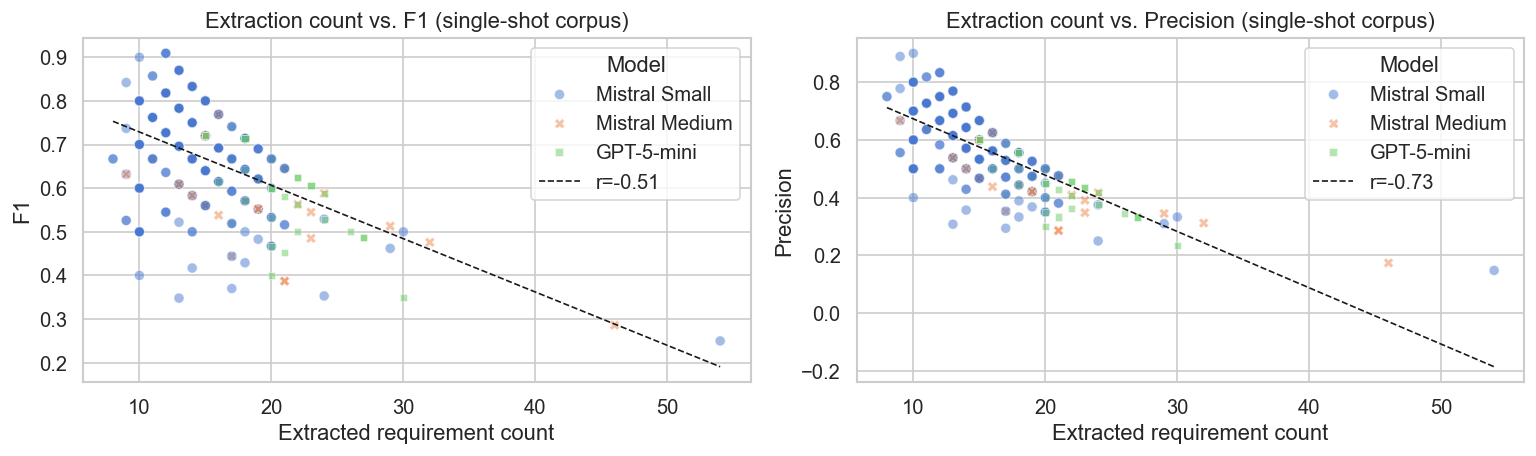


Pearson r (extracted_count vs F1):        -0.512
Pearson r (extracted_count vs precision): -0.732
Pearson r (extracted_count vs recall):    0.323


In [19]:
# ── Extraction count vs F1 scatter ────────────────────────────────────────────
# Demonstrates that the primary driver of precision/recall tradeoff is
# how many requirements the model chooses to extract.

df_ss_all = df_trace[df_trace["corpus"] == "single-shot"].copy()
df_ss_all["model_short"] = df_ss_all["model"].map({
    "mistral-small":  "Mistral Small",
    "mistral-medium": "Mistral Medium",
    "gpt-5-mini":     "GPT-5-mini",
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_col, y_label in [
    (axes[0], "f1",        "F1"),
    (axes[1], "precision", "Precision"),
]:
    sns.scatterplot(
        data=df_ss_all, x="extracted_count", y=y_col,
        hue="model_short", style="model_short",
        alpha=0.5, ax=ax
    )
    ax.set_xlabel("Extracted requirement count")
    ax.set_ylabel(y_label)
    ax.set_title(f"Extraction count vs. {y_label} (single-shot corpus)")
    ax.legend(title="Model")

    # Add trend line
    x, y = df_ss_all["extracted_count"].values, df_ss_all[y_col].values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, "k--", linewidth=1, label=f"r={r:.2f}")
    ax.legend(title="Model")

plt.tight_layout()
plt.show()
print(f"\nPearson r (extracted_count vs F1):        {stats.pearsonr(df_ss_all['extracted_count'], df_ss_all['f1'])[0]:.3f}")
print(f"Pearson r (extracted_count vs precision): {stats.pearsonr(df_ss_all['extracted_count'], df_ss_all['precision'])[0]:.3f}")
print(f"Pearson r (extracted_count vs recall):    {stats.pearsonr(df_ss_all['extracted_count'], df_ss_all['recall'])[0]:.3f}")


Table 7 — Temperature sensitivity (Mistral Small, single-shot corpus)
F1 shown as mean [95% bootstrap CI]; other metrics as mean only
  T=0.0 (n=40):  F1=0.663 [0.623–0.701]  P=0.588  R=0.798  QA=0.732  extracted=14.9
  T=0.3 (n=40):  F1=0.670 [0.632–0.706]  P=0.580  R=0.812  QA=0.741  extracted=14.5
  T=0.5 (n=120):  F1=0.680 [0.659–0.700]  P=0.592  R=0.818  QA=0.726  extracted=14.2
  T=0.7 (n=40):  F1=0.703 [0.673–0.732]  P=0.620  R=0.835  QA=0.704  extracted=13.9


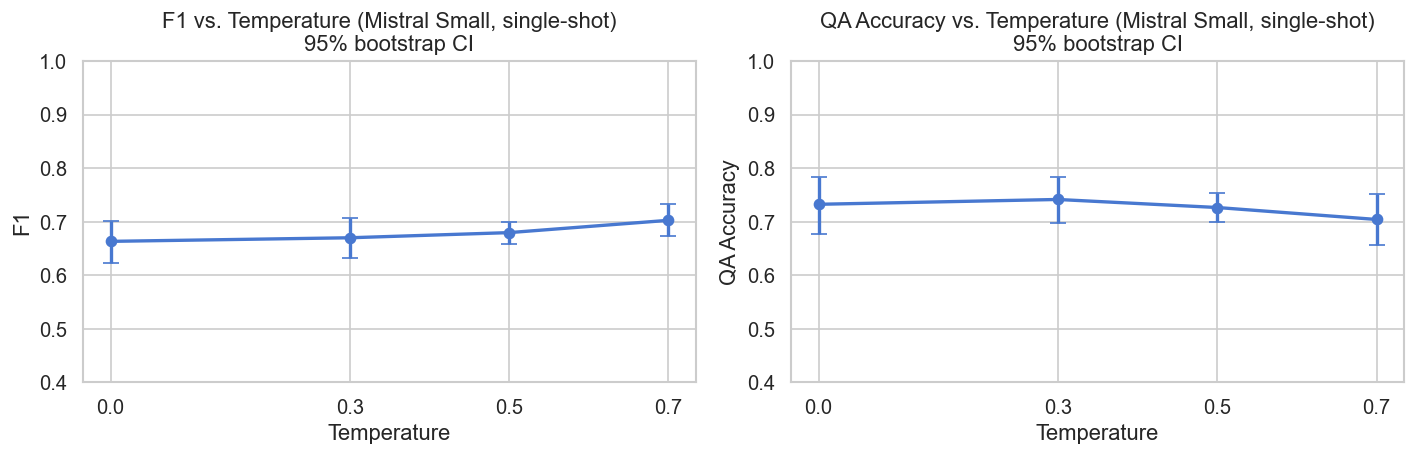

In [20]:
# ── Temperature sensitivity (Mistral Small, single-shot) ─────────────────────
df_temp = df_trace[
    (df_trace["model"] == "mistral-small") &
    (df_trace["corpus"] == "single-shot")
].copy()

print("Table 7 — Temperature sensitivity (Mistral Small, single-shot corpus)")
print("F1 shown as mean [95% bootstrap CI]; other metrics as mean only")
for t in sorted(df_temp["temp"].unique()):
    grp = df_temp[df_temp["temp"] == t]
    n   = len(grp)
    lo, hi = _bstrap_ci(grp["f1"])
    print(f"  T={t:.1f} (n={n}):  "
          f"F1={grp['f1'].mean():.3f} [{lo:.3f}–{hi:.3f}]  "
          f"P={grp['precision'].mean():.3f}  R={grp['recall'].mean():.3f}  "
          f"QA={grp['quality_attribute_accuracy'].mean():.3f}  "
          f"extracted={grp['extracted_count'].mean():.1f}")

# Line plot with 95% bootstrap CI error bars
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
temps = sorted(df_temp["temp"].unique())

for ax, metric, ylabel in [
    (axes[0], "f1",                          "F1"),
    (axes[1], "quality_attribute_accuracy",  "QA Accuracy"),
]:
    means  = [df_temp[df_temp["temp"] == t][metric].mean() for t in temps]
    cis    = [_bstrap_ci(df_temp[df_temp["temp"] == t][metric]) for t in temps]
    lo_err = [m - ci[0] for m, ci in zip(means, cis)]
    hi_err = [ci[1] - m for m, ci in zip(means, cis)]
    ax.errorbar(temps, means, yerr=[lo_err, hi_err],
                fmt="o-", capsize=5, linewidth=2, markersize=6)
    ax.set_xlabel("Temperature")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs. Temperature (Mistral Small, single-shot)\n95% bootstrap CI")
    ax.set_xticks(temps)
    ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.show()

In [21]:
# ── Intra-configuration variance (T=0.5, 3 runs) ─────────────────────────────
df_t05 = df_trace[
    (df_trace["model"] == "mistral-small") &
    (df_trace["temp"] == 0.5) &
    (df_trace["corpus"] == "single-shot")
]

print("Table 8 — F1 per run (T=0.5, stability check)")
for label, grp in df_t05.groupby("run_label"):
    print(f"  {label}: F1={grp['f1'].mean():.3f}  sd={grp['f1'].std():.3f}  "
          f"n={len(grp)} transcripts")

all_means = df_t05.groupby("run_label")["f1"].mean()
print(f"\n  Run-to-run F1 range:   {all_means.min():.3f} – {all_means.max():.3f}  "
      f"(Δ = {all_means.max()-all_means.min():.3f})")
print(f"  Within-run F1 std dev: {df_t05.groupby('run_label')['f1'].std().mean():.3f} (mean across runs)")


Table 8 — F1 per run (T=0.5, stability check)
  Mistral Small T=0.5 #1: F1=0.662  sd=0.119  n=40 transcripts
  Mistral Small T=0.5 #2: F1=0.687  sd=0.126  n=40 transcripts
  Mistral Small T=0.5 #3: F1=0.689  sd=0.108  n=40 transcripts

  Run-to-run F1 range:   0.662 – 0.689  (Δ = 0.027)
  Within-run F1 std dev: 0.118 (mean across runs)


---
## 5. RQ2 — TRACE Extraction: Interview Condition Effects <a id='rq2-conditions'></a>

Here we examine whether the quality of the interview (interviewer type, stakeholder type, domain/project) systematically affects extraction accuracy. For multi-run configurations, we show per-transcript data pooled across all runs of the same config to increase statistical power.

Subgroup analyses are restricted to configurations with total n ≥ 80 (≥2 corpus runs), ensuring minimum statistical power to detect medium effects. Single-run configurations (Mistral Medium, GPT-5-mini, and individual temperature sweeps) yield n=40, falling below this threshold; their overall extraction performance is reported in Table 6. The 3-step corpus (n=80) is included for completeness; reduced per-group size (n=20/group for 4-group analyses, n=16/group for 5-group analyses) limits statistical power — results should be interpreted cautiously.


In [22]:
# ── By-interviewer breakdown ──────────────────────────────────────────────────
# Compare novice vs experienced RE. Use all T=0.5 single-shot runs (n=3×40=120).

def by_interviewer_stats(df: pd.DataFrame, label: str) -> None:
    print(f"\n  {label}")
    for iview_key in sorted(df["interviewer"].unique()):
        iview_label  = INTERVIEWER_LABELS.get(iview_key, iview_key)
        grp_raw      = df[df["interviewer"] == iview_key]
        n            = len(grp_raw)
        f1_lo, f1_hi = _bstrap_ci(grp_raw["f1"])
        f1  = grp_raw["f1"].mean()
        sd  = grp_raw["f1"].std()
        p   = grp_raw["precision"].mean()
        r   = grp_raw["recall"].mean()
        qa  = grp_raw["quality_attribute_accuracy"].mean()
        ext = grp_raw["extracted_count"].mean()
        print(f"    {iview_label:<20}: F1={f1:.3f} [{f1_lo:.3f}–{f1_hi:.3f}]  "
              f"sd={sd:.3f}  P={p:.3f}  R={r:.3f}  QA={qa:.3f}  extracted={ext:.1f}  (n={n})")
    # Mann-Whitney
    nov_f1 = df.loc[df["interviewer"] == "re_novice",      "f1"]
    exp_f1 = df.loc[df["interviewer"] == "re_experienced", "f1"]
    if len(nov_f1) and len(exp_f1):
        _mwu = pg.mwu(np.asarray(exp_f1), np.asarray(nov_f1), alternative="two-sided")
        p_val = float(_mwu["p_val"].iloc[0])
        r_rb  = float(_mwu["RBC"].iloc[0])
        interp = "large" if abs(r_rb) >= 0.5 else ("medium" if abs(r_rb) >= 0.3 else "small")
        mean_diff = exp_f1.mean() - nov_f1.mean()
        sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
        print(f"    Interviewer F1 effect ({sig}): p={p_val:.4f}")
        if p_val < 0.05:
            print(f"      Mean diff (experienced − novice): {mean_diff:+.3f}")
            print(f"      Effect size: r_rb={abs(r_rb):.3f} ({interp})")

print("Table 9 — TRACE F1 by Interviewer Type")
# T=0.5 single-shot (3 runs pooled)
by_interviewer_stats(
    df_trace[(df_trace["model"]=="mistral-small") & (df_trace["temp"]==0.5) & (df_trace["corpus"]=="single-shot")],
    "Mistral Small T=0.5 (single-shot, 3 runs pooled, n=120)"
)
# T=0.5 3-step (2 runs pooled)
by_interviewer_stats(
    df_trace[(df_trace["model"]=="mistral-small") & (df_trace["temp"]==0.5) & (df_trace["corpus"]=="3-step")],
    "Mistral Small T=0.5 (3-step, 2 runs pooled, n=80)"
)


Table 9 — TRACE F1 by Interviewer Type

  Mistral Small T=0.5 (single-shot, 3 runs pooled, n=120)
    Experienced RE      : F1=0.691 [0.663–0.718]  sd=0.109  P=0.591  R=0.850  QA=0.716  extracted=14.9  (n=60)
    Novice RE           : F1=0.669 [0.636–0.699]  sd=0.125  P=0.593  R=0.785  QA=0.736  extracted=13.6  (n=60)
    Interviewer F1 effect (✗ not significant): p=0.4827

  Mistral Small T=0.5 (3-step, 2 runs pooled, n=80)
    Experienced RE      : F1=0.575 [0.526–0.622]  sd=0.156  P=0.472  R=0.762  QA=0.739  extracted=17.4  (n=40)
    Novice RE           : F1=0.588 [0.557–0.618]  sd=0.101  P=0.485  R=0.790  QA=0.721  extracted=17.3  (n=40)
    Interviewer F1 effect (✗ not significant): p=0.9118


In [23]:

# ── By-stakeholder breakdown ──────────────────────────────────────────────────
import pingouin as pg

def _stakeholder_table(df, label, n_per_group_note):
    print(f"  Note: {n_per_group_note}")
    for stk_key in sorted(df["stakeholder"].unique()):
        stk_label    = STAKEHOLDER_LABELS.get(stk_key, stk_key)
        grp_raw      = df[df["stakeholder"] == stk_key]
        f1_lo, f1_hi = _bstrap_ci(grp_raw["f1"])
        f1  = grp_raw["f1"].mean()
        sd  = grp_raw["f1"].std()
        p   = grp_raw["precision"].mean()
        r   = grp_raw["recall"].mean()
        qa  = grp_raw["quality_attribute_accuracy"].mean()
        ext = grp_raw["extracted_count"].mean()
        print(f"  {stk_label:<22}: F1={f1:.3f} [{f1_lo:.3f}–{f1_hi:.3f}]  "
              f"sd={sd:.3f}  P={p:.3f}  R={r:.3f}  QA={qa:.3f}  extracted={ext:.1f}")
    _kw = pg.kruskal(df, dv="f1", between="stakeholder")
    h_stat  = float(_kw["H"].iloc[0])
    p_val   = float(_kw["p_unc"].iloc[0])
    n_total = len(df)
    eps_sq  = h_stat / (n_total - 1)
    interp = "large" if eps_sq >= 0.14 else ("medium" if eps_sq >= 0.06 else "small")
    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"\n  Kruskal-Wallis (F1 across stakeholders) ({sig}): H={h_stat:.3f}, p={p_val:.4f}"
          f"  (n={n_total}, {n_total//4}/group)")
    if p_val < 0.05:
        print(f"    Effect size: ε²={eps_sq:.3f} ({interp})")
    else:
        print(f"    Effect size (reported regardless): ε²={eps_sq:.3f} ({interp})")
    print()

print(f"Table 10 — TRACE F1 by Stakeholder Type\n")

# T=0.5 single-shot (3 runs pooled, n=120, 30/group)
df_t05_ss = df_trace[
    (df_trace["model"] == "mistral-small") &
    (df_trace["temp"] == 0.5) &
    (df_trace["corpus"] == "single-shot")
]
_stakeholder_table(df_t05_ss, "Mistral Small T=0.5, single-shot, 3 runs pooled",
                   "n=120 total, 30/group")

# T=0.5 3-step (2 runs pooled, n=80, 20/group — reduced power)
df_t05_3s = df_trace[
    (df_trace["model"] == "mistral-small") &
    (df_trace["temp"] == 0.5) &
    (df_trace["corpus"] == "3-step")
]
_stakeholder_table(df_t05_3s, "Mistral Small T=0.5, 3-step, 2 runs pooled",
                   "n=80 total, 20/group — reduced power, interpret cautiously")


Table 10 — TRACE F1 by Stakeholder Type

  Note: n=120 total, 30/group
  End User              : F1=0.697 [0.657–0.734]  sd=0.111  P=0.619  R=0.810  QA=0.741  extracted=13.4
  Non-tech. Manager     : F1=0.689 [0.657–0.722]  sd=0.093  P=0.601  R=0.830  QA=0.761  extracted=14.3
  Tech. Junior          : F1=0.686 [0.635–0.736]  sd=0.142  P=0.604  R=0.807  QA=0.685  extracted=13.5
  Tech. Senior          : F1=0.647 [0.604–0.688]  sd=0.119  P=0.545  R=0.823  QA=0.720  extracted=15.6

  Kruskal-Wallis (F1 across stakeholders) (✗ not significant): H=2.863, p=0.4133  (n=120, 30/group)
    Effect size (reported regardless): ε²=0.024 (small)

  Note: n=80 total, 20/group — reduced power, interpret cautiously
  End User              : F1=0.595 [0.555–0.632]  sd=0.090  P=0.498  R=0.760  QA=0.742  extracted=15.7
  Non-tech. Manager     : F1=0.602 [0.547–0.651]  sd=0.122  P=0.491  R=0.825  QA=0.724  extracted=18.4
  Tech. Junior          : F1=0.573 [0.519–0.631]  sd=0.133  P=0.465  R=0.785  QA=0.689

In [24]:

# ── By-project breakdown ──────────────────────────────────────────────────────
import pingouin as pg

def _project_table(df, label, n_per_group_note):
    print(f"  Note: {n_per_group_note}")
    f1_means = {}
    for pid in sorted(df["project_id"].unique()):
        grp_raw      = df[df["project_id"] == pid]
        f1_lo, f1_hi = _bstrap_ci(grp_raw["f1"])
        f1  = grp_raw["f1"].mean()
        sd  = grp_raw["f1"].std()
        p   = grp_raw["precision"].mean()
        r   = grp_raw["recall"].mean()
        qa  = grp_raw["quality_attribute_accuracy"].mean()
        f1_means[pid] = f1
        print(f"  [{pid}] {PROJECT_NAMES.get(pid, pid):<24}: "
              f"F1={f1:.3f} [{f1_lo:.3f}–{f1_hi:.3f}]  sd={sd:.3f}  P={p:.3f}  R={r:.3f}  QA={qa:.3f}")
    f1_range = max(f1_means.values()) - min(f1_means.values())
    print(f"\n  Project F1 range: {f1_range:.3f}  "
          f"(min={min(f1_means.values()):.3f}, max={max(f1_means.values()):.3f})")
    _kw = pg.kruskal(df, dv="f1", between="project_id")
    h_stat  = float(_kw["H"].iloc[0])
    p_val   = float(_kw["p_unc"].iloc[0])
    n_total = len(df)
    eps_sq  = h_stat / (n_total - 1)
    interp = "large" if eps_sq >= 0.14 else ("medium" if eps_sq >= 0.06 else "small")
    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"  Kruskal-Wallis (F1 across projects) ({sig}): H={h_stat:.3f}, p={p_val:.4f}"
          f"  (n={n_total}, {n_total//5}/group)")
    if p_val < 0.05:
        print(f"    Effect size: ε²={eps_sq:.3f} ({interp})")
    else:
        print(f"    Effect size (reported regardless): ε²={eps_sq:.3f} ({interp})")
    print()

print(f"Table 11 — TRACE F1 by Project\n")

# T=0.5 single-shot (3 runs pooled, n=120, 24/group)
_project_table(df_t05_ss, "Mistral Small T=0.5, single-shot, 3 runs pooled",
               "n=120 total, 24/group")

# T=0.5 3-step (2 runs pooled, n=80, 16/group — reduced power)
_project_table(df_t05_3s, "Mistral Small T=0.5, 3-step, 2 runs pooled",
               "n=80 total, 16/group — reduced power, interpret cautiously")


Table 11 — TRACE F1 by Project

  Note: n=120 total, 24/group
  [3] Nursing Scheduling      : F1=0.684 [0.647–0.720]  sd=0.092  P=0.604  R=0.817  QA=0.721
  [4] Credit Card Disputes    : F1=0.592 [0.545–0.638]  sd=0.117  P=0.546  R=0.662  QA=0.605
  [5] Recycled Parts Mgmt     : F1=0.708 [0.665–0.749]  sd=0.106  P=0.616  R=0.846  QA=0.752
  [6] Conference Room Mgmt    : F1=0.708 [0.649–0.761]  sd=0.141  P=0.615  R=0.846  QA=0.713
  [8] IzognMovies Streaming   : F1=0.706 [0.672–0.739]  sd=0.085  P=0.580  R=0.917  QA=0.841

  Project F1 range: 0.116  (min=0.592, max=0.708)
  Kruskal-Wallis (F1 across projects) (✓ significant): H=17.151, p=0.0018  (n=120, 24/group)
    Effect size: ε²=0.144 (large)

  Note: n=80 total, 16/group — reduced power, interpret cautiously
  [3] Nursing Scheduling      : F1=0.614 [0.569–0.658]  sd=0.095  P=0.515  R=0.800  QA=0.671
  [4] Credit Card Disputes    : F1=0.435 [0.373–0.496]  sd=0.131  P=0.355  R=0.600  QA=0.638
  [5] Recycled Parts Mgmt     : F1=0.598 

Joined 40 transcript pairs (SQuIRE × TRACE F1)
Spearman ρ (SQuIRE quality vs TRACE F1): ρ=0.105 [95% CI -0.268–0.450], p=0.5206
Spearman ρ (SQuIRE meta   vs TRACE F1): ρ=0.141 [95% CI -0.199–0.447], p=0.3846


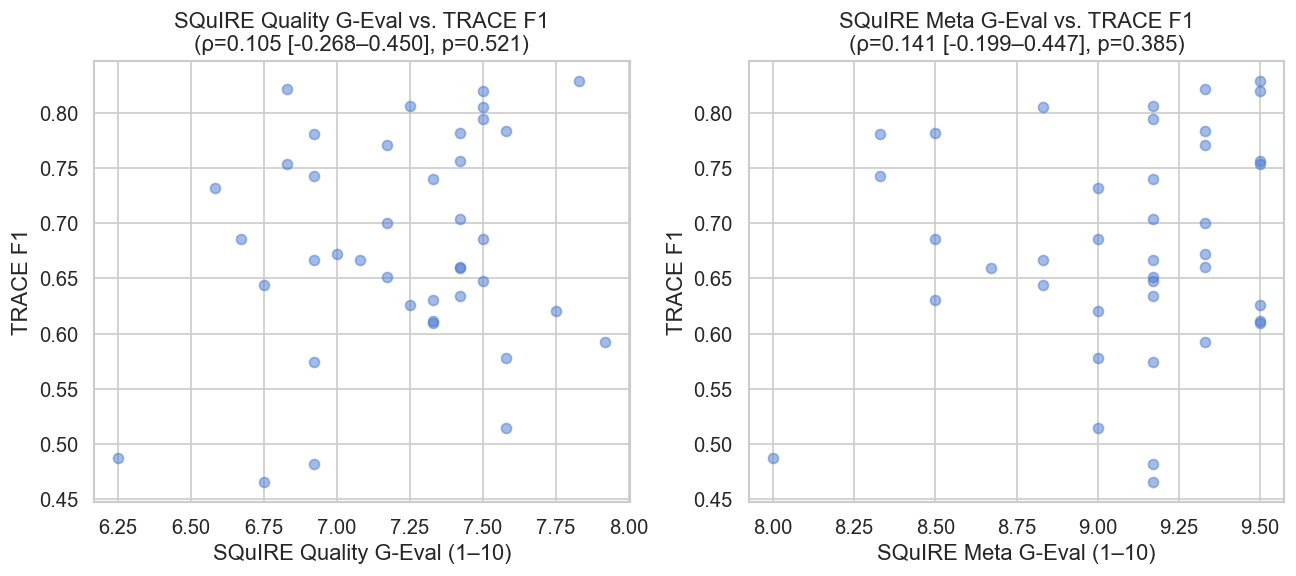

In [25]:

# ── Spearman correlation: SQuIRE quality/meta scores vs TRACE F1 ──────────────
# Join on project_id × interviewer × stakeholder.
# Use single-shot corpus on both sides; TRACE: mean F1 across all 3 primary
# single-shot runs to avoid cherry-picking any individual run.

# Use mean F1 per transcript across all 3 primary single-shot runs to avoid
# cherry-picking any individual run.
_primary_ss_runs = [
    r for r in TRACE_MANIFEST
    if r["phase"] == "primary" and r["corpus"] == "single-shot"
]
df_trace_rep = (
    pd.concat([load_trace_per_transcript(r) for r in _primary_ss_runs])
    .groupby(["project_id", "interviewer", "stakeholder"], as_index=False)["f1"]
    .mean()
)

df_squire_join = df_ss[["project_id", "interviewer", "stakeholder", "quality", "meta"]].copy()
df_trace_join  = df_trace_rep[["project_id", "interviewer", "stakeholder", "f1"]].copy()

df_join = pd.merge(
    df_squire_join, df_trace_join,
    on=["project_id", "interviewer", "stakeholder"],
    how="inner"
)
print(f"Joined {len(df_join)} transcript pairs (SQuIRE × TRACE F1)")

rho_q, p_q = stats.spearmanr(df_join["quality"], df_join["f1"])
rho_m, p_m = stats.spearmanr(df_join["meta"],    df_join["f1"])

# Bootstrap percentile 95% CI for Spearman ρ
def _spearman_ci(
    x, y, n_boot: int = 10_000, alpha: float = 0.05
) -> tuple[float, float]:
    """Bootstrap percentile 95% CI for Spearman ρ. Resamples (x, y) pairs."""
    rng  = np.random.default_rng(42)
    n    = len(x)
    x, y = np.asarray(x), np.asarray(y)
    rhos = np.array([
        stats.spearmanr(x[idx := rng.integers(0, n, n)], y[idx])[0]
        for _ in range(n_boot)
    ])
    return (
        float(np.percentile(rhos, 100 * alpha / 2)),
        float(np.percentile(rhos, 100 * (1 - alpha / 2))),
    )

ci_q = _spearman_ci(df_join["quality"].values, df_join["f1"].values)
ci_m = _spearman_ci(df_join["meta"].values,    df_join["f1"].values)

print(f"Spearman ρ (SQuIRE quality vs TRACE F1): ρ={rho_q:.3f} [95% CI {ci_q[0]:.3f}–{ci_q[1]:.3f}], p={p_q:.4f}")
print(f"Spearman ρ (SQuIRE meta   vs TRACE F1): ρ={rho_m:.3f} [95% CI {ci_m[0]:.3f}–{ci_m[1]:.3f}], p={p_m:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col, rho, ci, p_val, label in [
    (axes[0], "quality", rho_q, ci_q, p_q, "Quality G-Eval"),
    (axes[1], "meta",    rho_m, ci_m, p_m, "Meta G-Eval"),
]:
    ax.scatter(df_join[col], df_join["f1"], alpha=0.5)
    ax.set_xlabel(f"SQuIRE {label} (1–10)")
    ax.set_ylabel("TRACE F1")
    ax.set_title(f"SQuIRE {label} vs. TRACE F1\n"
                 f"(ρ={rho:.3f} [{ci[0]:.3f}–{ci[1]:.3f}], p={p_val:.3f})")

plt.tight_layout()
plt.show()


### RQ2 — TRACE Extraction Accuracy: Summary

#### What we did
We evaluated the TRACE extraction pipeline across eight configurations — varying model (Mistral Small, Mistral Medium, GPT-5-mini), temperature (0.0, 0.3, 0.5, 0.7), and corpus type (single-shot, three-step) — using the ground truth from SQuIRE's requirement selection step. Extraction performance was measured with Precision, Recall, and F1 (text retrieval hit defined as overlap score ≥ 3), and Quality Attribute (QA) accuracy independently assessed the correctness of NFR category labels on matched requirements. All runs used `gpt-5-mini` as evaluation judge.

In Section 5, we examined whether interview condition — interviewer experience, stakeholder type, or project domain — systematically affected extraction accuracy. Subgroup analyses used configurations with total n ≥ 80; the three-step corpus (n=80, ~20/group for four-group analyses) is included for completeness with reduced statistical power.

#### What we found
The best overall configuration was Mistral Small at T=0.5 (F1=0.680, P=0.592, R=0.818, QA=0.726), confirmed stable across three independent runs (run-to-run F1 range Δ=0.027). Extraction count was the dominant driver of the precision–recall tradeoff: Pearson r(count, precision)=−0.73, indicating that models extracting more requirements systematically sacrifice precision without proportional recall gain. Larger models (Mistral Medium, GPT-5-mini) extracted ~19–21 requirements per transcript versus ~15–17 for Mistral Small, resulting in lower F1 despite comparable or higher recall.

Temperature had a small but measurable effect: F1 rose monotonically from T=0.0 to T=0.5 (+0.017), with T=0.7 achieving the highest single-run F1 (0.703) but the lowest QA accuracy (0.704). T=0.5 was selected as it maximises F1 without degrading classification accuracy and is the only setting with empirical stability confirmation. This selection was based on exploratory pilot results and should be interpreted accordingly; T=0.7 was not given equivalent stability testing.

The three-step corpus yielded notably lower F1 (0.581 vs. 0.680 for single-shot). This is consistent with the meta G-Eval finding that the three-step pipeline produces lower explicit requirement coverage: requirements encoded more naturalistically into dialogue are harder for TRACE to surface as citeable statements. The quality–extraction tradeoff is therefore coherent across both evaluation instruments.

QA accuracy was remarkably flat at ~72–73% across all models and temperatures. This model-agnostic ceiling likely reflects genuine label ambiguity in the ground truth: NICE.csv classifications were produced by a single research team, and ambiguous or overlapping NFR categories may represent an irreducible difficulty floor rather than a model limitation.

Across interview conditions, neither interviewer experience (Mann-Whitney p=0.48 single-shot, p=0.91 three-step) nor stakeholder type (Kruskal-Wallis p=0.41) had a significant effect on F1. Project domain, however, showed a statistically significant effect (H=17.15, p=0.0018, single-shot), with per-project F1 ranging from 0.592 (Credit Card Disputes) to 0.708 (Conference Room).

Neither SQuIRE quality nor meta completeness was significantly correlated with TRACE F1: quality ρ=0.105 (p=0.521), meta ρ=0.141 (p=0.385). Both p-values are well above the 0.05 threshold — these results are statistically meaningless as correlation evidence and must not be interpreted as indicating any real relationship. The meta ρ direction is theoretically expected (higher explicit coverage → easier extraction) but the magnitude is small and likely attenuated by range restriction: the forced-completeness design compresses meta scores into a narrow band (8.0–9.5, effective spread ≈ 0.7 points), leaving insufficient variance for a reliable estimate. Whether a genuine relationship exists cannot be determined from this data.

**Multiple testing note.** Across the RQ2 subgroup analyses — two corpora times three condition types (interviewer, stakeholder, project) — six significance tests are reported. No family-wise correction has been applied; the Bonferroni-adjusted threshold for six tests at α = 0.05 is p < 0.0083. The project effect (H, p = 0.0018, single-shot) survives this correction. The interviewer and stakeholder effects are non-significant (p > 0.1) and would not be promoted by any correction scheme. Results should be interpreted in this context.

#### Conclusion
TRACE achieves moderate extraction accuracy (F1=0.680) on synthetic interview transcripts, with recall of ~0.82 indicating that the system surfaces approximately four in five encoded requirements. In the context of a human-in-the-loop requirements engineering workflow — where an engineer reviews and filters flagged candidates — this level of recall is practically sufficient: false positives are easily dismissed, while false negatives represent the real cost. A substantially higher F1 on synthetic, controlled transcripts would raise questions about overfitting to the study design rather than reflecting genuine capability.

The finding that neither interviewer experience nor stakeholder type affects extraction accuracy warrants careful interpretation. The study design requires all requirements to be encoded in every transcript regardless of interviewer quality, meaning the ground truth remains constant across conditions. This design choice, motivated by the need for a stable evaluation baseline, limits the ecological validity of the null result: in real interviews, a novice RE may genuinely fail to elicit requirements, which the current design cannot capture. The null result therefore reflects what TRACE can do given a complete transcript, not what it would achieve under realistic elicitation conditions.

The significant project effect (p=0.0018) is the most practically informative finding: domain-level factors — likely complexity, jargon density, and requirements quality variation across NICE.csv teams — affect extraction more than any interview-style variable. This result is consistent across both corpora, though the five-project scope limits generalisability. The orthogonality of SQuIRE quality and TRACE F1 (both correlations non-significant) confirms that the two systems operate on independent quality axes: producing a better interview transcript does not guarantee easier extraction, and vice versa.


---
## 6. RQ3 — Traceability & Gap Detection <a id='rq3'></a>

**RQ3:** *How effectively can an automated extraction system identify information gaps and provide traceable evidence for elicited quality requirements?*

This section analyses:
1. **Citation verification** — whether extracted requirements are traceable to verbatim (or near-verbatim) passages in the transcript
2. **Per-requirement quality scores** — gap detection quality, rationale quality, and confidence quality as rated by the evaluation judge
3. **Recall gaps by quality attribute** — which quality attribute categories are systematically missed

Data source: individual extraction and evaluation JSON files from the canonical T=0.5 runs (3 single-shot + 2 3-step, pooled within each corpus).



Mistral Small T=0.5 — single-shot (3 runs pooled)
  Total extracted:   1707
  Citation verified: 1299  (76.1%  95% CI [74.0%–78.1%])
  Citation flagged:  408  (23.9%)
  By project:
    [3] Nursing Scheduling      : 73.7%  (n=339)
    [4] Credit Card Disputes    : 77.7%  (n=300)
    [5] Recycled Parts Mgmt     : 81.8%  (n=340)
    [6] Conference Room Mgmt    : 69.0%  (n=339)
    [8] IzognMovies Streaming   : 78.1%  (n=389)

Mistral Small T=0.5 — 3-step (2 runs pooled)
  Total extracted:   1388
  Citation verified: 1028  (74.1%  95% CI [71.7%–76.3%])
  Citation flagged:  360  (25.9%)
  By project:
    [3] Nursing Scheduling      : 77.7%  (n=264)
    [4] Credit Card Disputes    : 70.7%  (n=304)
    [5] Recycled Parts Mgmt     : 73.8%  (n=267)
    [6] Conference Room Mgmt    : 75.8%  (n=240)
    [8] IzognMovies Streaming   : 73.2%  (n=313)


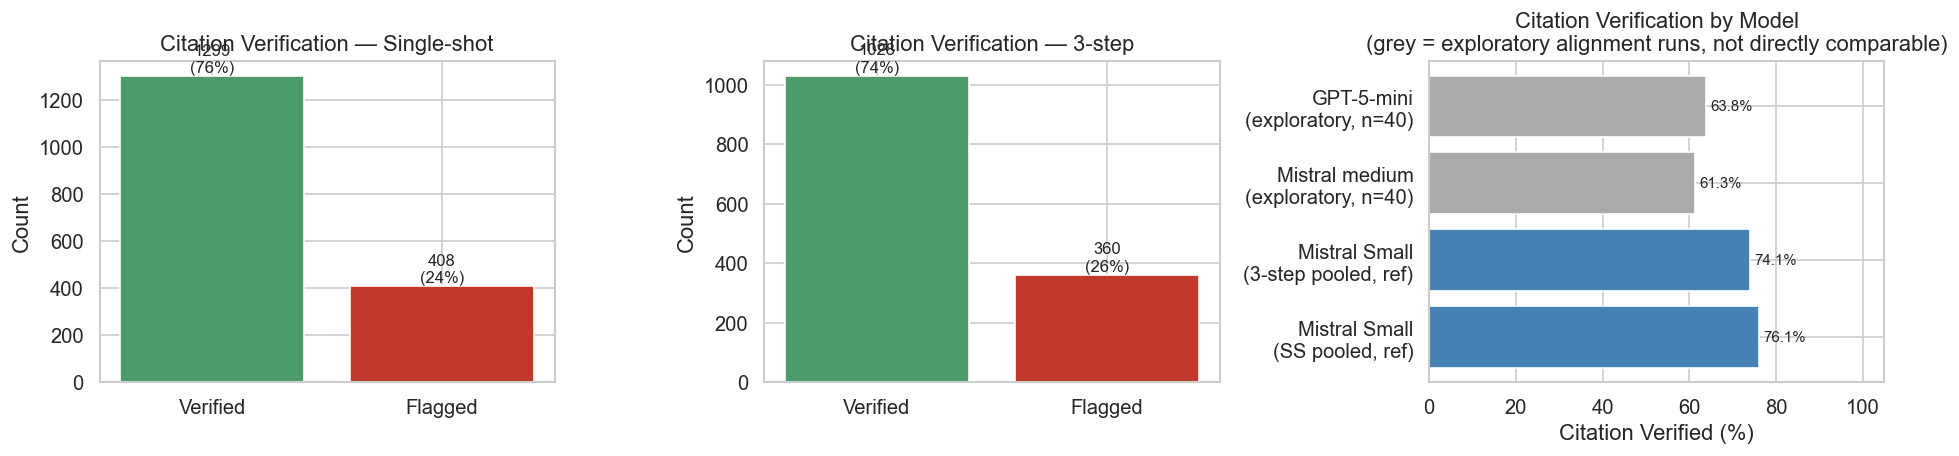

In [26]:
# ── Citation verification ─────────────────────────────────────────────────────
# Representative configuration: Mistral Small T=0.5, both corpora.
t05_ss_runs = [
    r for r in TRACE_MANIFEST
    if r["model"] == "mistral-small" and r["temp"] == 0.5 and r["corpus"] == "single-shot"
]
t05_3s_runs = [
    r for r in TRACE_MANIFEST
    if r["model"] == "mistral-small" and r["temp"] == 0.5 and r["corpus"] == "3-step"
]

df_cit_ss = pd.concat([load_citations(r) for r in t05_ss_runs], ignore_index=True)
df_cit_3s = pd.concat([load_citations(r) for r in t05_3s_runs], ignore_index=True)


def _cit_summary(df, label):
    n = len(df)
    n_v = int(df["citation_verified"].sum())
    lo, hi = _wilson_ci(n_v, n)
    print(f"\n{label}")
    print(f"  Total extracted:   {n}")
    print(f"  Citation verified: {n_v}  ({100*n_v/n:.1f}%  95% CI [{100*lo:.1f}%–{100*hi:.1f}%])")
    print(f"  Citation flagged:  {n - n_v}  ({100*(n-n_v)/n:.1f}%)")
    print("  By project:")
    for pid, grp in df.groupby("project_id"):
        pct = 100 * grp["citation_verified"].mean()
        print(f"    [{pid}] {PROJECT_NAMES.get(pid, pid):<24}: {pct:.1f}%  (n={len(grp)})")


_cit_summary(df_cit_ss, "Mistral Small T=0.5 — single-shot (3 runs pooled)")
_cit_summary(df_cit_3s, "Mistral Small T=0.5 — 3-step (2 runs pooled)")

# Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall bar per corpus
for ax, (df, label) in zip(axes[:2], [(df_cit_ss, "Single-shot"), (df_cit_3s, "3-step")]):
    n = len(df)
    n_v = int(df["citation_verified"].sum())
    n_f = n - n_v
    ax.bar(["Verified", "Flagged"], [n_v, n_f], color=["#4c9c6b", "#c0392b"])
    ax.set_ylabel("Count")
    ax.set_title(f"Citation Verification — {label}")
    for bar, val in zip(ax.patches, [n_v, n_f]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f"{val}\n({100*val/n:.0f}%)", ha="center", va="bottom", fontsize=10)

# Model comparison (right panel): pooled references vs exploratory single runs
ref_pct_ss = 100 * df_cit_ss["citation_verified"].mean()
ref_pct_3s = 100 * df_cit_3s["citation_verified"].mean()
model_cit_rows = [
    {"label": "Mistral Small\n(SS pooled, ref)",     "pct": ref_pct_ss, "ref": True},
    {"label": "Mistral Small\n(3-step pooled, ref)", "pct": ref_pct_3s, "ref": True},
]
seen_models: set[str] = set()
for r in TRACE_MANIFEST:
    if r["model"] == "mistral-small" or r["corpus"] != "single-shot":
        continue
    if r["model"] in seen_models:
        continue
    seen_models.add(r["model"])
    df_c = load_citations(r)
    short = r["model"].replace("mistral-", "Mistral ").replace("gpt-5-mini", "GPT-5-mini")
    model_cit_rows.append({"label": f"{short}\n(exploratory, n=40)", "pct": 100 * df_c["citation_verified"].mean(), "ref": False})

df_mcit = pd.DataFrame(model_cit_rows)
bar_colors = ["steelblue" if row["ref"] else "#aaaaaa" for _, row in df_mcit.iterrows()]
axes[2].barh(df_mcit["label"], df_mcit["pct"], color=bar_colors)
axes[2].set_xlabel("Citation Verified (%)")
axes[2].set_xlim(0, 105)
axes[2].set_title("Citation Verification by Model\n(grey = exploratory alignment runs, not directly comparable)")
for i, row in df_mcit.iterrows():
    axes[2].text(row["pct"] + 1, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()



Table 12 — Per-requirement quality scores (Mistral Small T=0.5, single-shot, 3 runs pooled)  [n=1707]
  gap_detection_quality       : mean=3.540 [3.503–3.579]  sd=0.795  median=4.0
  rationale_quality           : mean=3.680 [3.651–3.709]  sd=0.602  median=4.0
  confidence_quality          : mean=4.044 [4.008–4.080]  sd=0.766  median=4.0
  overlap_score               : mean=3.702 [3.627–3.776]  sd=1.576  median=4.0
  is_hit rate                 : 0.753  (1285/1707)
  is_duplicate rate           : 0.185  [lower bound — see note above]

  Among hits     (n=981):
    gap_detection_quality       : mean=3.587
    rationale_quality           : mean=3.901
    confidence_quality          : mean=4.383

  Among non-hits (n=422):
    gap_detection_quality       : mean=3.474
    rationale_quality           : mean=3.137
    confidence_quality          : mean=3.242

Table 12 — Per-requirement quality scores (Mistral Small T=0.5, 3-step, 2 runs pooled)  [n=1388]
  gap_detection_quality       : mean=3

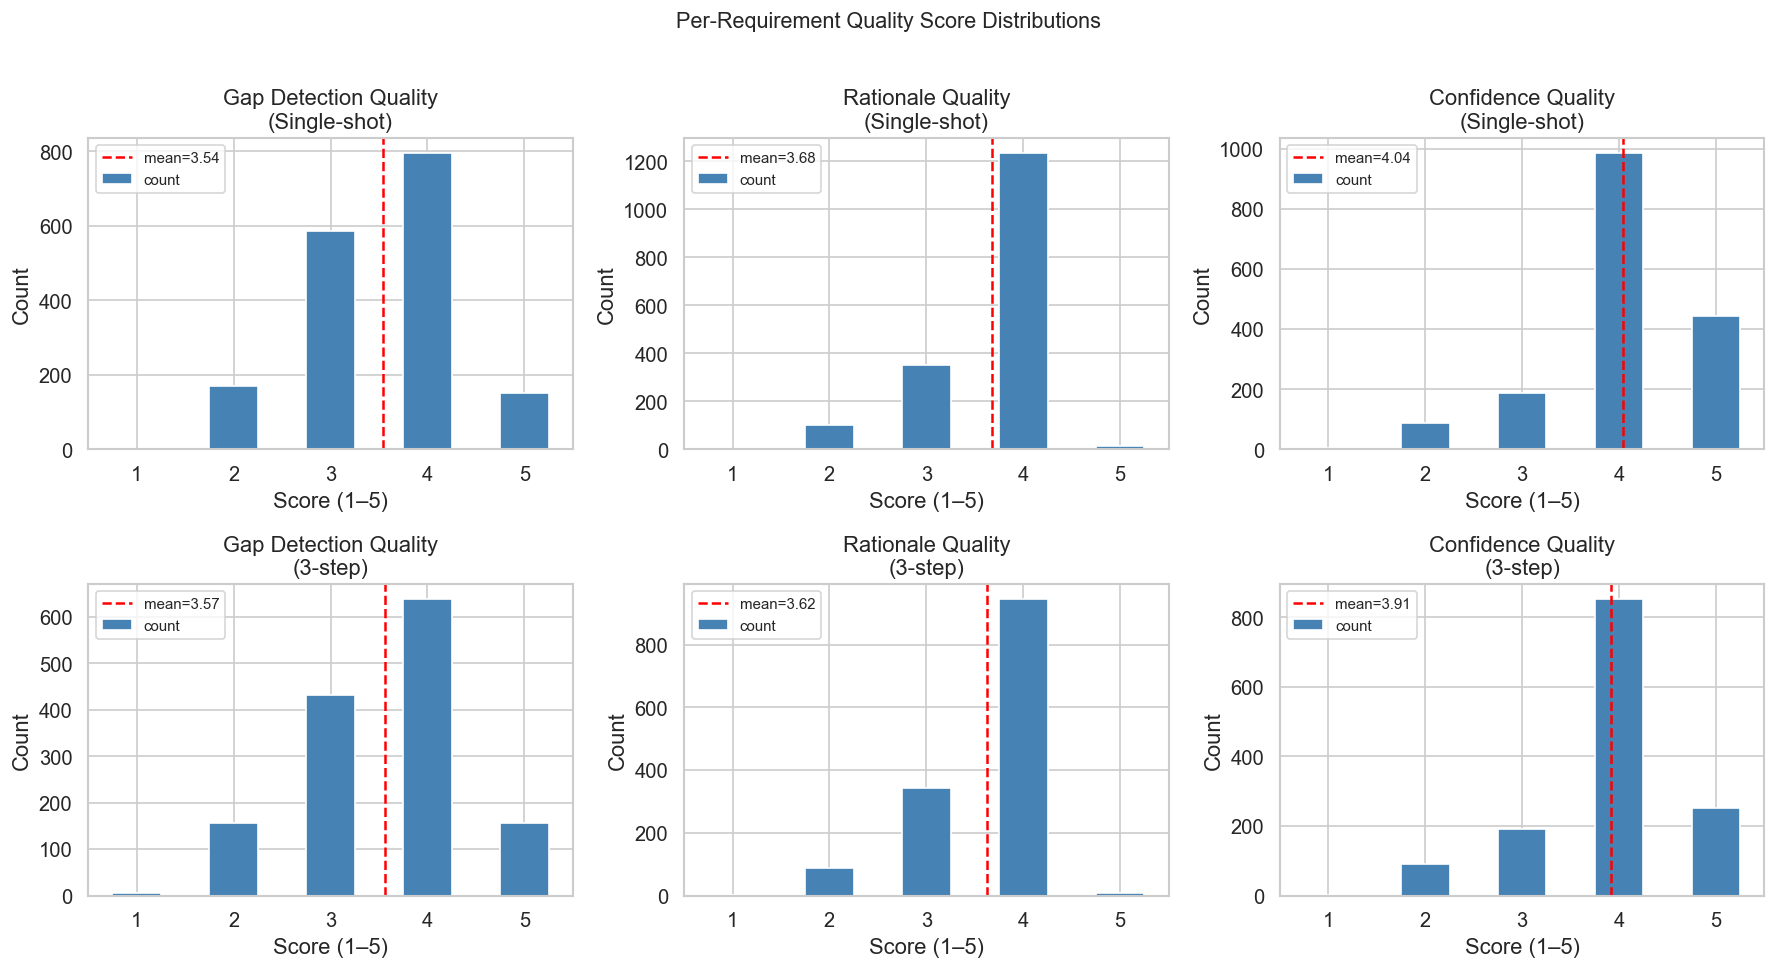

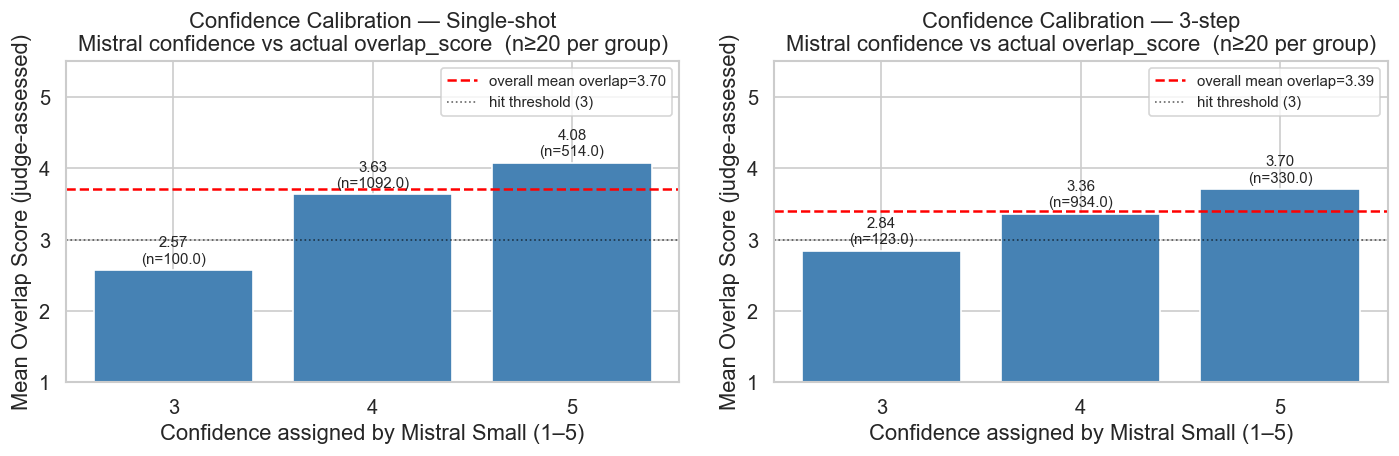

Confidence calibration — numerical summary (confidence vs overlap_score and hit rate):
  Single-shot (n=1707):
  Conf    Mean overlap   Hit rate      n
  3              2.570      0.470  100.0 (below threshold)
  4              3.632      0.741 1092.0
  5              4.078      0.835  514.0
  Hit threshold = 3.0  |  Overall hit rate: 0.753
  3-step (n=1388):
  Conf    Mean overlap   Hit rate      n
  3              2.837      0.561  123.0 (below threshold)
  4              3.357      0.681  934.0
  5              3.703      0.761  330.0
  Hit threshold = 3.0  |  Overall hit rate: 0.689

Note: citation-verified rate (in the confidence-vs-citation cell below) is a weaker calibration
      metric and should NOT be treated as the primary confidence calibration measure.


In [27]:
# ── Per-requirement quality scores (Table 12) ─────────────────────────────────
# gap_detection_quality, rationale_quality, confidence_quality: rated 1–5 by GPT judge
# confidence_quality = judge's assessment of whether Mistral's confidence was appropriate
#
# NOTE — is_duplicate reliability:
#   A duplicate is flagged only when the LLM judge *picks* a GT index that was already
#   claimed by an earlier extraction. Merely having a shared GT item in the BERTScore
#   top-3 window is not sufficient — the judge must independently select it.
#   Example: A claims GT[2]; B has GT[2] in its top-3 but judge picks GT[5] → no dup.
#   Additionally, a non-hit (overlap_score < 3) can claim a GT slot before a genuine
#   hit does, producing a conservative (downward) bias in precision and recall.
#   The duplicate rate is a lower bound and carries some stochasticity at T > 0.

df_preq_ss = pd.concat([load_per_req_eval(r) for r in t05_ss_runs], ignore_index=True)
df_preq_3s = pd.concat([load_per_req_eval(r) for r in t05_3s_runs], ignore_index=True)


def _table12(df, label):
    n = len(df)
    hits = df[df["is_hit"] & ~df["is_duplicate"]]
    non_hits = df[~df["is_hit"]]
    print(f"\nTable 12 — Per-requirement quality scores ({label})  [n={n}]")
    for col in ["gap_detection_quality", "rationale_quality", "confidence_quality", "overlap_score"]:
        vals = df[col]
        lo, hi = _bstrap_ci(vals)
        print(f"  {col:<28}: mean={vals.mean():.3f} [{lo:.3f}–{hi:.3f}]  sd={vals.std():.3f}  median={vals.median():.1f}")
    print(f"  {'is_hit rate':<28}: {df['is_hit'].mean():.3f}  ({df['is_hit'].sum()}/{n})")
    print(f"  {'is_duplicate rate':<28}: {df['is_duplicate'].mean():.3f}  [lower bound — see note above]")
    print(f"\n  Among hits     (n={len(hits)}):")
    for col in ["gap_detection_quality", "rationale_quality", "confidence_quality"]:
        print(f"    {col:<28}: mean={hits[col].mean():.3f}")
    print(f"\n  Among non-hits (n={len(non_hits)}):")
    for col in ["gap_detection_quality", "rationale_quality", "confidence_quality"]:
        print(f"    {col:<28}: mean={non_hits[col].mean():.3f}")


_table12(df_preq_ss, "Mistral Small T=0.5, single-shot, 3 runs pooled")
_table12(df_preq_3s, "Mistral Small T=0.5, 3-step, 2 runs pooled")

# Score distributions — 2×3 grid (corpus × dimension)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row_idx, (df, corpus_label) in enumerate([(df_preq_ss, "Single-shot"), (df_preq_3s, "3-step")]):
    for ax, (col, title) in zip(axes[row_idx], [
        ("gap_detection_quality", "Gap Detection Quality"),
        ("rationale_quality",     "Rationale Quality"),
        ("confidence_quality",    "Confidence Quality"),
    ]):
        df[col].value_counts().sort_index().plot(kind="bar", ax=ax, rot=0, color="steelblue")
        ax.set_xlabel("Score (1–5)")
        ax.set_ylabel("Count")
        ax.set_title(f"{title}\n({corpus_label})")
        mean_val = df[col].mean()
        ax.axvline(mean_val - 1, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.2f}")
        ax.legend(fontsize=9)

plt.suptitle("Per-Requirement Quality Score Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Calibration: Mistral's self-reported confidence vs actual overlap_score
# confidence = Mistral Small's extraction-time certainty (1–5, from extraction JSON)
# overlap_score = judge-assessed text retrieval match (1–5, from eval JSON)
# Minimum n=20 per confidence level — confidence=2 (n=1) excluded as statistically meaningless.
df_conf_ss = pd.concat([load_confidence_overlap(r) for r in t05_ss_runs], ignore_index=True)
df_conf_3s = pd.concat([load_confidence_overlap(r) for r in t05_3s_runs], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, label) in zip(axes, [(df_conf_ss, "Single-shot"), (df_conf_3s, "3-step")]):
    calib = df.groupby("confidence")["overlap_score"].agg(mean="mean", count="count")
    calib = calib[calib["count"] >= 20]
    ax.bar(calib.index.astype(str), calib["mean"], color="steelblue")
    ax.axhline(df["overlap_score"].mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"overall mean overlap={df['overlap_score'].mean():.2f}")
    ax.axhline(3.0, color="black", linestyle=":", linewidth=1, alpha=0.6, label="hit threshold (3)")
    ax.set_xlabel("Confidence assigned by Mistral Small (1–5)")
    ax.set_ylabel("Mean Overlap Score (judge-assessed)")
    ax.set_ylim(1, 5.5)
    ax.set_title(f"Confidence Calibration — {label}\nMistral confidence vs actual overlap_score  (n≥20 per group)")
    for i, (conf_val, row) in enumerate(calib.iterrows()):
        ax.text(i, row["mean"] + 0.1, f"{row['mean']:.2f}\n(n={row['count']})", ha="center", fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Calibration: numerical output ─────────────────────────────────────────────
# These values are reported in the thesis results and discussion sections.
print("Confidence calibration — numerical summary (confidence vs overlap_score and hit rate):")
for _cal_label, _cal_df in [("Single-shot", df_conf_ss), ("3-step", df_conf_3s)]:
    _calib = _cal_df.groupby("confidence").agg(
        mean_overlap=("overlap_score", "mean"),
        hit_rate=("is_hit", "mean"),
        n=("is_hit", "count"),
    )
    _calib = _calib[_calib["n"] >= 20]
    print(f"  {_cal_label} (n={len(_cal_df)}):")
    print(f"  {'Conf':<6} {'Mean overlap':>13} {'Hit rate':>10} {'n':>6}")
    for _conf, _row in _calib.iterrows():
        hit_marker = " (below threshold)" if _row["mean_overlap"] < 3.0 else ""
        print(f"  {_conf:<6} {_row['mean_overlap']:>13.3f} {_row['hit_rate']:>10.3f} {_row['n']:>6}{hit_marker}")
    print(f"  Hit threshold = 3.0  |  Overall hit rate: {_cal_df['is_hit'].mean():.3f}")
print()
print("Note: citation-verified rate (in the confidence-vs-citation cell below) is a weaker calibration")
print("      metric and should NOT be treated as the primary confidence calibration measure.")


Citation verified rate by confidence level (n≥20 only):
            verified_rate  count
confidence                      
3                   0.726    223
4                   0.752   2026
5                   0.759    844


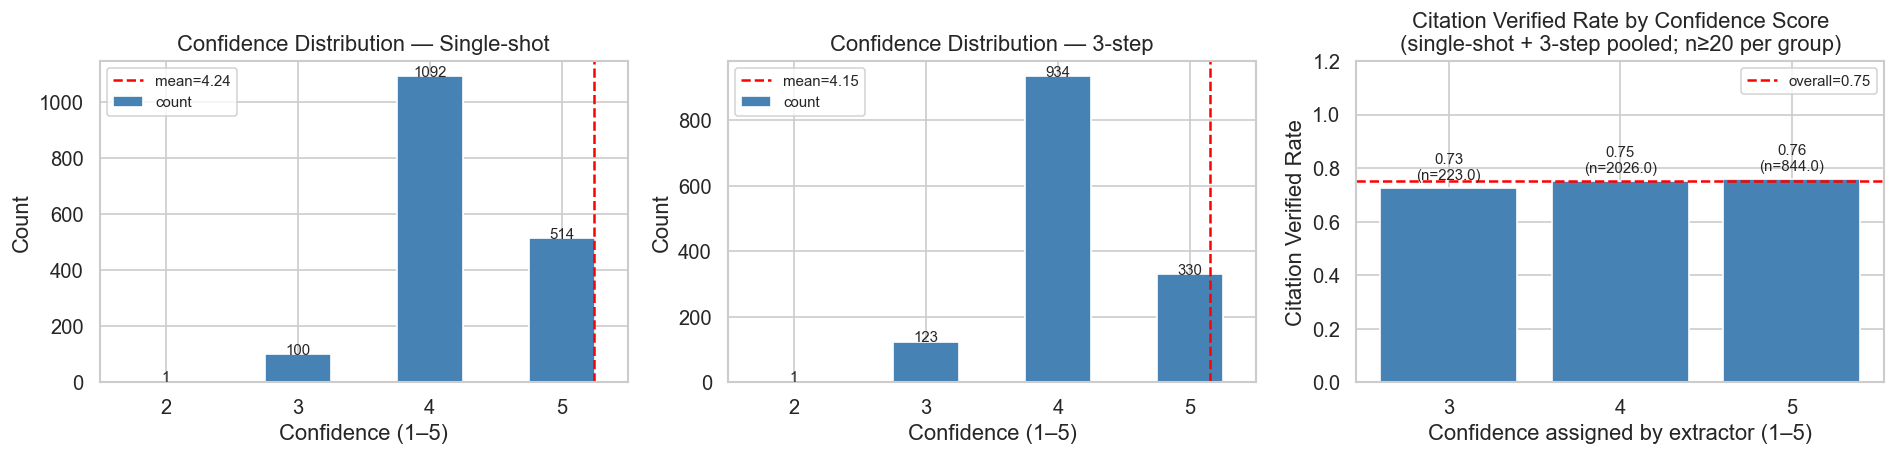

In [28]:
# ── Confidence distribution and citation cross-check ─────────────────────────
# confidence = Mistral Small's self-assigned certainty during extraction (1–5)
# citation_verified = exact-match post-processing (deterministic — no LLM judge involved)
# Both fields come directly from the extraction JSON.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confidence distributions per corpus
for ax, (df, label) in zip(axes[:2], [(df_cit_ss, "Single-shot"), (df_cit_3s, "3-step")]):
    counts = df["confidence"].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, rot=0, color="steelblue")
    ax.set_xlabel("Confidence (1–5)")
    ax.set_ylabel("Count")
    ax.set_title(f"Confidence Distribution — {label}")
    mean_val = df["confidence"].mean()
    ax.axvline(mean_val - 1, color="red", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.2f}")
    ax.legend(fontsize=9)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", fontsize=9)

# Cross-check: citation verified rate per confidence score (both corpora pooled)
# Minimum n=20 per group required — confidence=2 (n=2) is excluded as statistically meaningless.
df_cit_all = pd.concat(
    [df_cit_ss.assign(corpus="single-shot"), df_cit_3s.assign(corpus="3-step")],
    ignore_index=True,
)
conf_cit = df_cit_all.groupby("confidence")["citation_verified"].agg(verified_rate="mean", count="count")
conf_cit = conf_cit[conf_cit["count"] >= 20]

axes[2].bar(conf_cit.index.astype(str), conf_cit["verified_rate"], color="steelblue")
overall_mean = df_cit_all["citation_verified"].mean()
axes[2].axhline(overall_mean, color="red", linestyle="--", linewidth=1.5,
                label=f"overall={overall_mean:.2f}")
axes[2].set_xlabel("Confidence assigned by extractor (1–5)")
axes[2].set_ylabel("Citation Verified Rate")
axes[2].set_ylim(0, 1.2)
axes[2].set_title("Citation Verified Rate by Confidence Score\n(single-shot + 3-step pooled; n≥20 per group)")
for i, (conf_val, row) in enumerate(conf_cit.iterrows()):
    axes[2].text(i, row["verified_rate"] + 0.03,
                 f"{row['verified_rate']:.2f}\n(n={row['count']})", ha="center", fontsize=9)
axes[2].legend(fontsize=9)

print("Citation verified rate by confidence level (n≥20 only):")
print(conf_cit.to_string())

plt.tight_layout()
plt.show()



Table 13 — Recall by quality attribute category (Mistral Small T=0.5, single-shot, 3 runs pooled)  [95% Wilson CI]
  operability              : 0.54 [0.48–0.61]  (122/225)
  portability              : 0.73 [0.61–0.83]  (44/60)
  usability                : 0.80 [0.75–0.85]  (176/219)
  legal                    : 0.86 [0.79–0.91]  (113/132)
  security                 : 0.90 [0.85–0.93]  (188/210)
  scalability              : 0.90 [0.82–0.95]  (81/90)
  availability             : 0.91 [0.86–0.95]  (148/162)
  maintainability          : 0.92 [0.80–0.97]  (36/39)
  look_and_feel            : 0.95 [0.89–0.98]  (97/102)
  performance              : 0.97 [0.93–0.98]  (223/231)
  fault_tolerance          : 0.97 [0.89–0.99]  (61/63)

Table 13 — Recall by quality attribute category (Mistral Small T=0.5, 3-step, 2 runs pooled)  [95% Wilson CI]
  operability              : 0.51 [0.42–0.59]  (67/132)
  usability                : 0.76 [0.69–0.82]  (122/160)
  security                 : 0.81 [0.73–0.

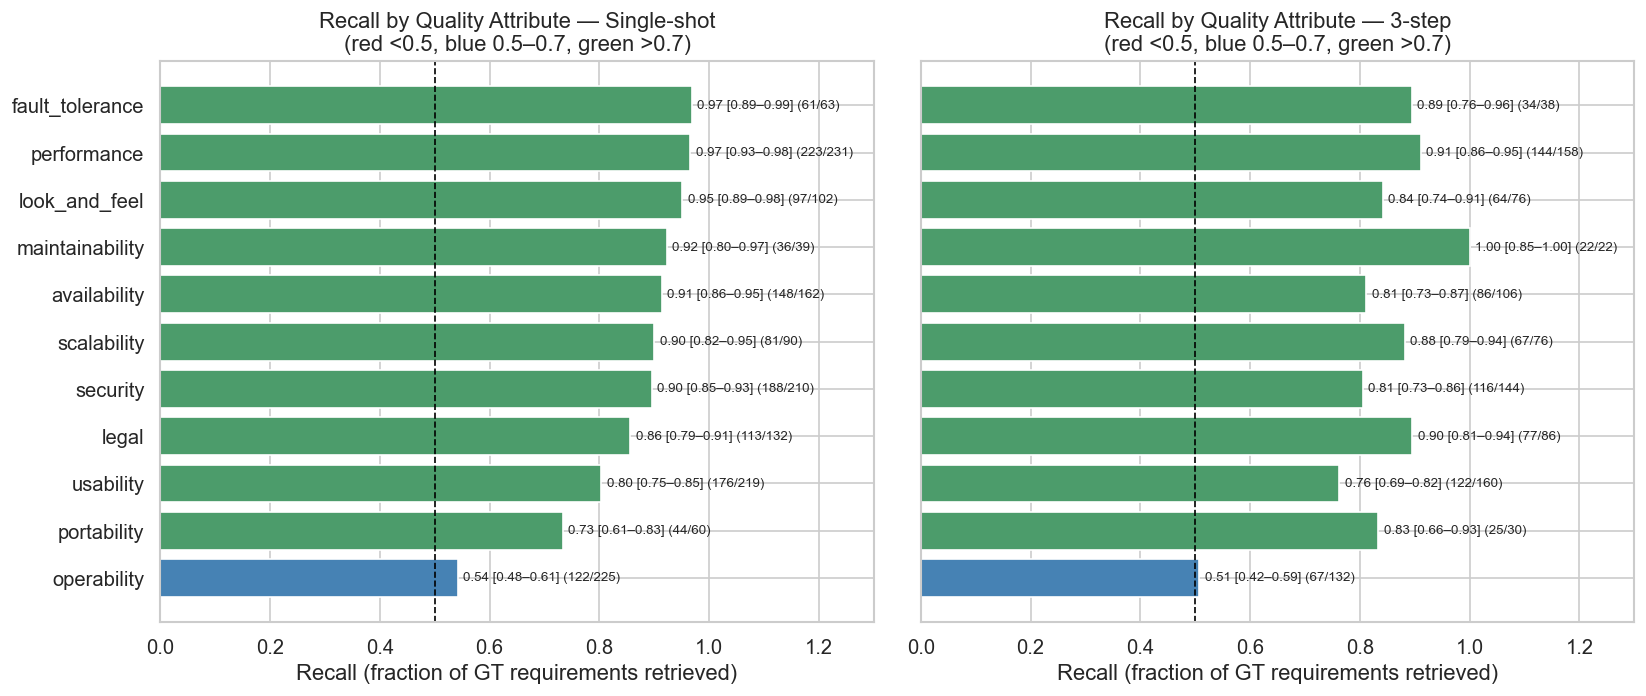

In [29]:
# ── Recall gaps by quality attribute category ─────────────────────────────────
# Which NFR types are systematically missed by TRACE?
#
# "quality" and "functional" are NICE.csv row-level classification flags (is-NFR / is-FR),
# not semantic NFR sub-types — excluded from this analysis.
_NON_SEMANTIC = {"quality", "functional"}


def _recall_gap_table(runs, squire_dir, label):
    df = pd.concat([load_recall_gaps(r, squire_dir) for r in runs], ignore_index=True)
    df = df[~df["category"].isin(_NON_SEMANTIC)]
    tbl = (
        df.groupby("category")["is_matched"]
        .agg(total="count", matched="sum")
        .assign(recall=lambda x: x["matched"] / x["total"])
        .sort_values("recall")
    )
    # Wilson 95% CI on each per-category recall proportion
    tbl["ci_lo"] = tbl.apply(lambda r: _wilson_ci(int(r["matched"]), int(r["total"]))[0], axis=1)
    tbl["ci_hi"] = tbl.apply(lambda r: _wilson_ci(int(r["matched"]), int(r["total"]))[1], axis=1)
    print(f"\nTable 13 — Recall by quality attribute category ({label})  [95% Wilson CI]")
    for cat, row in tbl.iterrows():
        print(f"  {cat:<25}: {row['recall']:.2f} [{row['ci_lo']:.2f}–{row['ci_hi']:.2f}]"
              f"  ({int(row['matched'])}/{int(row['total'])})")
    return tbl


stats_ss = _recall_gap_table(t05_ss_runs, SQUIRE_SINGLE_SHOT, "Mistral Small T=0.5, single-shot, 3 runs pooled")
stats_3s = _recall_gap_table(t05_3s_runs, SQUIRE_3STEP,      "Mistral Small T=0.5, 3-step, 2 runs pooled")

# Side-by-side bar charts — consistent category order (union, sorted by single-shot recall)
all_cats = stats_ss.index.union(stats_3s.index)
order = stats_ss.reindex(all_cats)["recall"].sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (stats_df, label) in zip(axes, [(stats_ss, "Single-shot"), (stats_3s, "3-step")]):
    s = stats_df.reindex(order).dropna()
    colors = ["#c0392b" if r < 0.5 else "#4c9c6b" if r > 0.7 else "steelblue"
              for r in s["recall"]]
    ax.barh(s.index, s["recall"], color=colors)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Recall (fraction of GT requirements retrieved)")
    ax.set_title(f"Recall by Quality Attribute — {label}\n(red <0.5, blue 0.5–0.7, green >0.7)")
    ax.set_xlim(0, 1.3)
    for i, (cat, row) in enumerate(s.iterrows()):
        ax.text(row["recall"] + 0.01, i,
                f"{row['recall']:.2f} [{row['ci_lo']:.2f}–{row['ci_hi']:.2f}] "
                f"({int(row['matched'])}/{int(row['total'])})",
                va="center", fontsize=8)

plt.tight_layout()
plt.show()


### 6b. Quality Attribute Classification — Confusion Matrix

For requirements that TRACE *did* retrieve (text-retrieval hits, overlap ≥ 3), we analyse how often the predicted `quality_attribute` label agrees with the ground-truth category.

This disentangles two distinct failure modes:
- **Elicitation gap** — the requirement was never surfaced in the transcript, so TRACE had nothing to retrieve (visible in the recall-by-category chart above).
- **Classification error** — TRACE found the right passage but attached the wrong QA label (visible here, as off-diagonal mass).

**Operability** is the lowest-recall category across both corpora (0.51–0.54). The confusion matrix reveals whether this is predominantly an elicitation problem (few hits regardless of label) or a classification problem (hits mislabelled as another attribute, e.g. portability, which shares deployment/platform concerns with operability in ISO 25010).


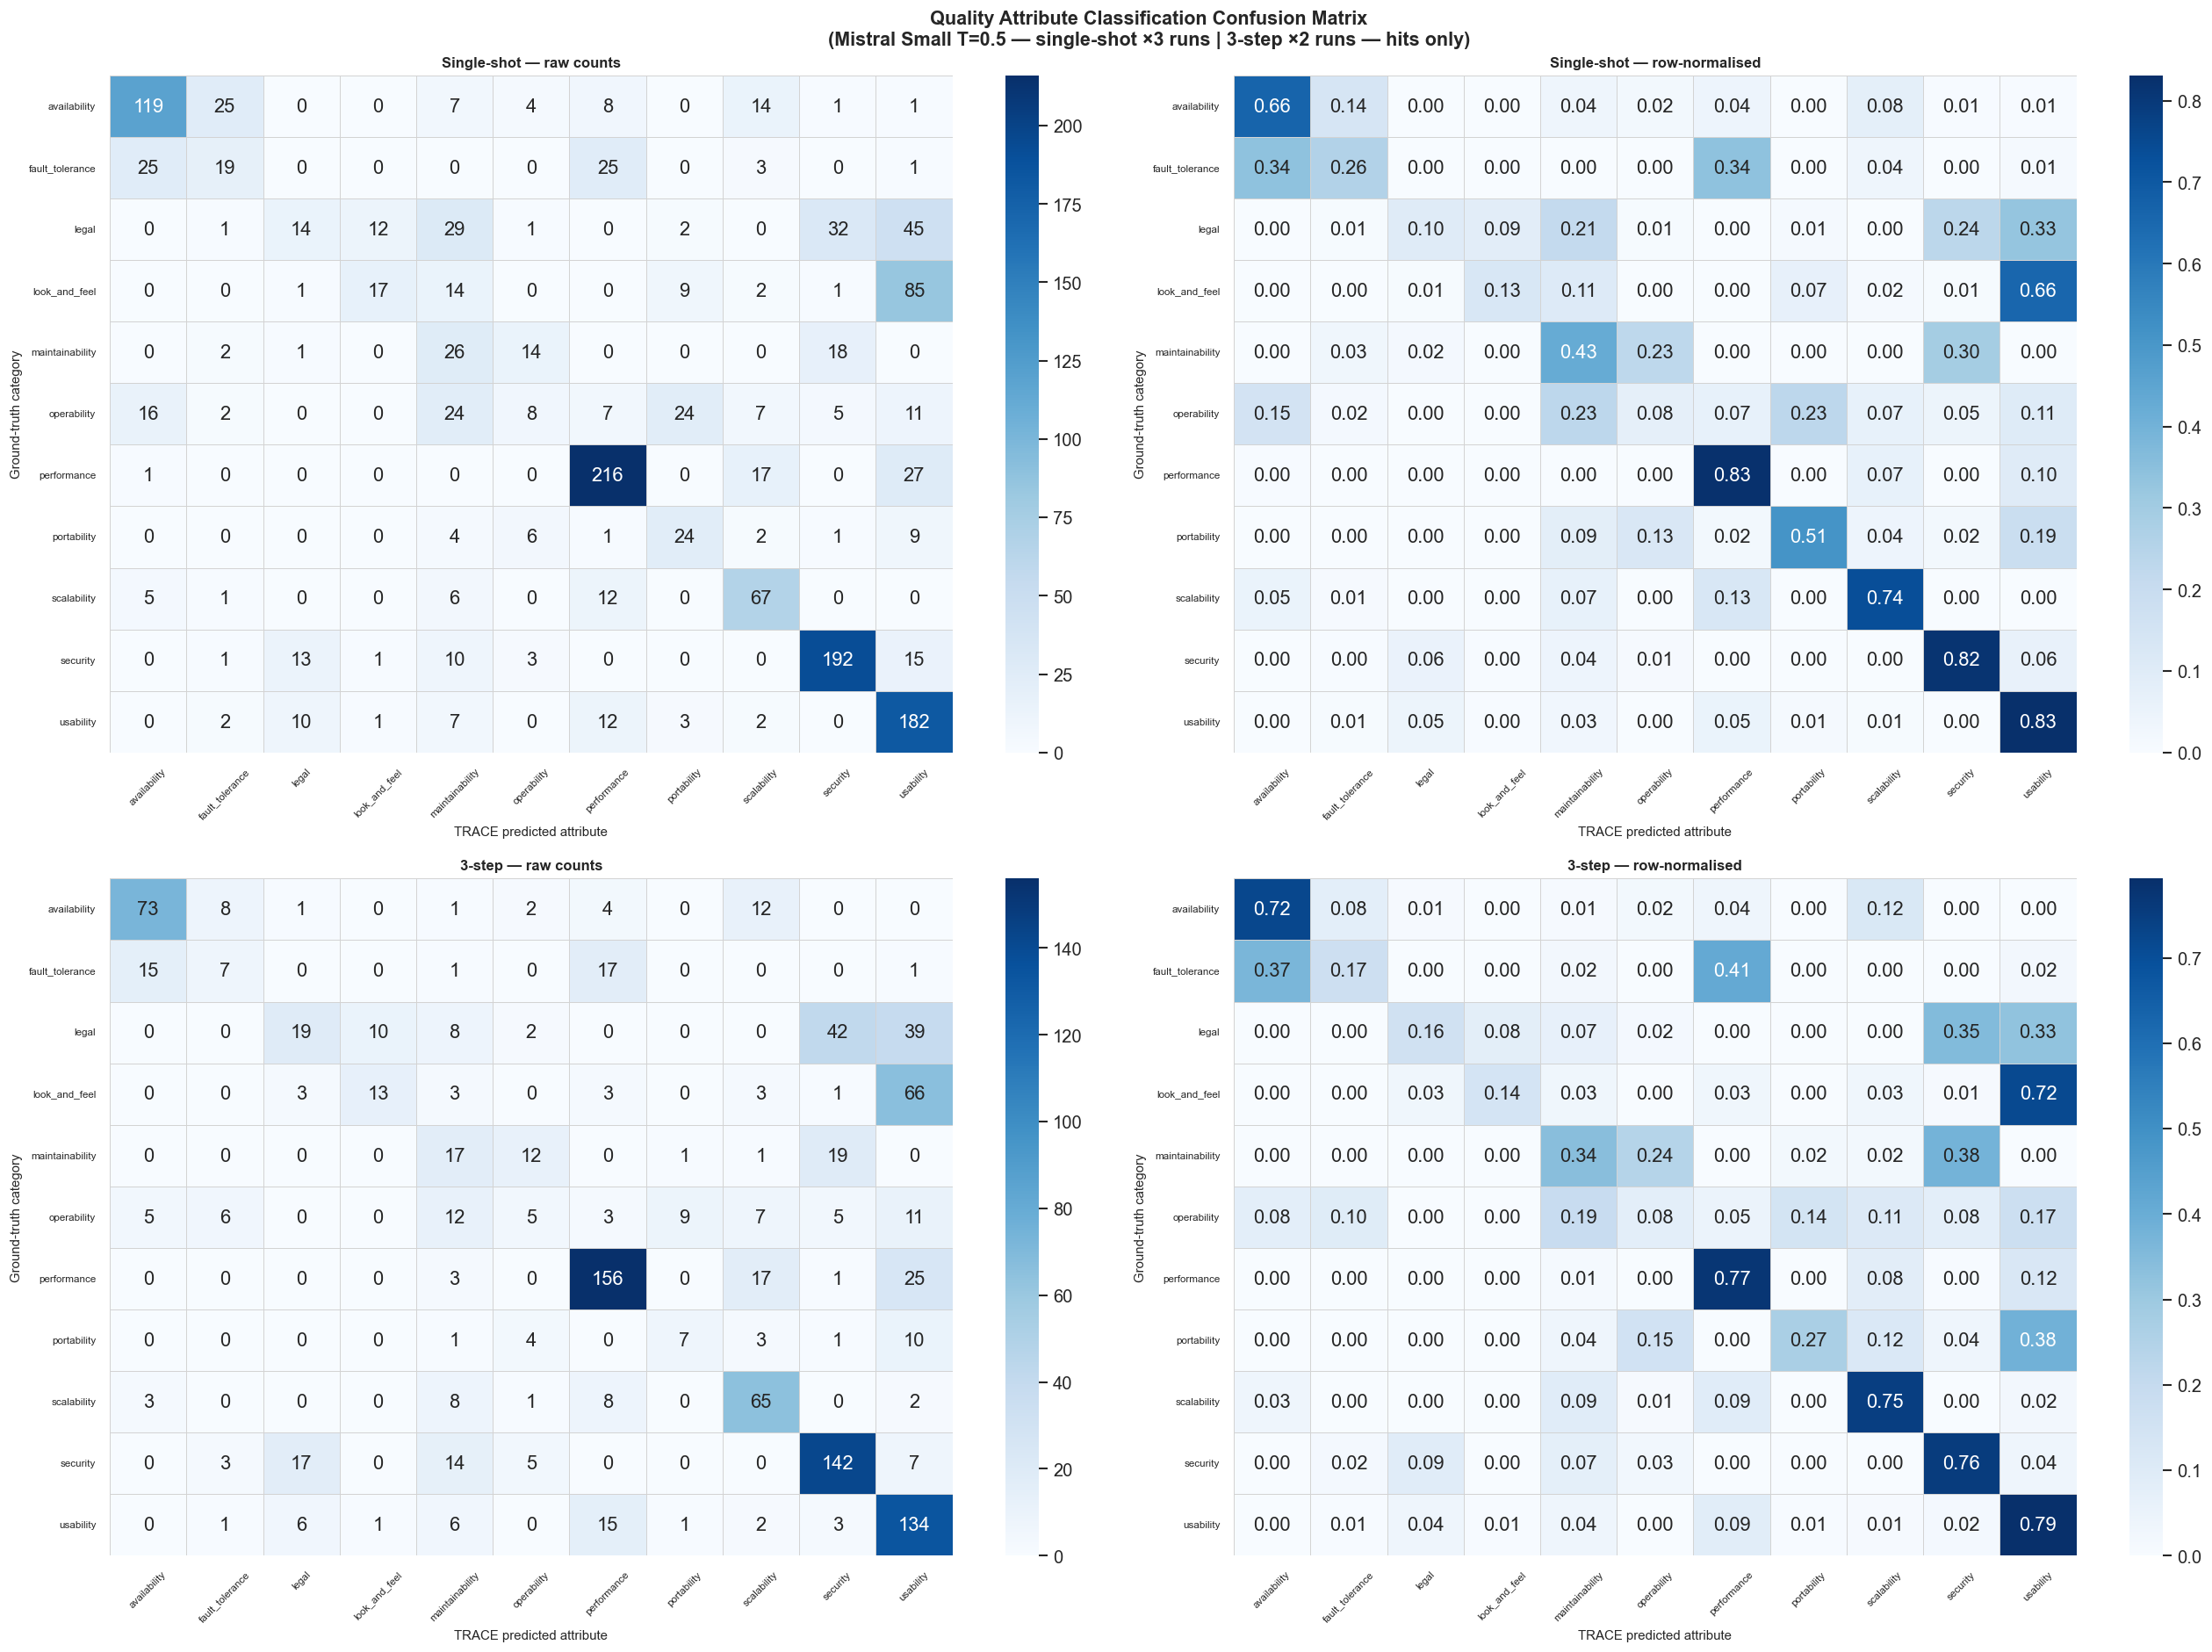


── Operability: misclassification vs. elicitation gap ──

  [Single-shot] 104 text-retrieval hits for operability requirements:
    Predicted 'maintainability': 23.1%  (n=24)
    Predicted 'portability': 23.1%  (n=24)
    Predicted 'availability': 15.4%  (n=16)
    Predicted 'usability': 10.6%  (n=11)
    Predicted 'operability': 7.7%  (n=8) ← correct
    Predicted 'performance': 6.7%  (n=7)
    Predicted 'scalability': 6.7%  (n=7)
    Predicted 'security': 4.8%  (n=5)
    Predicted 'fault_tolerance': 1.9%  (n=2)

  [3-step] 63 text-retrieval hits for operability requirements:
    Predicted 'maintainability': 19.0%  (n=12)
    Predicted 'usability': 17.5%  (n=11)
    Predicted 'portability': 14.3%  (n=9)
    Predicted 'scalability': 11.1%  (n=7)
    Predicted 'fault_tolerance': 9.5%  (n=6)
    Predicted 'availability': 7.9%  (n=5)
    Predicted 'operability': 7.9%  (n=5) ← correct
    Predicted 'security': 7.9%  (n=5)
    Predicted 'performance': 4.8%  (n=3)


In [30]:
# ── QA Classification Confusion Matrix ─────────────────────────────────────
# For text-retrieval *hits* only (overlap_score ≥ 3): compare GT category vs
# TRACE-predicted quality_attribute.  Reveals whether low recall for a category
# (e.g. operability) is driven by misclassification or a genuine elicitation gap.

_EXCLUDE_CATS = {"quality", "functional"}   # non-semantic NICE.csv flags

def load_confusion_data(run: dict, squire_corpus_dir: Path) -> pd.DataFrame:
    """Return (gt_category, predicted_attribute) pairs for all text-retrieval hits."""
    records = []
    corpus_dir = run["path"]

    for eval_f in sorted(corpus_dir.glob("trace_transcript_*_eval.json")):
        eval_d = json.loads(eval_f.read_text())

        # Matching extraction file (strip _eval suffix)
        stem = eval_f.stem[: eval_f.stem.rfind("_eval")]
        extract_f = corpus_dir / f"{stem}.json"
        if not extract_f.exists():
            continue
        extract_d = json.loads(extract_f.read_text())

        # GT requirements from sidecar transcript JSON
        gt_source = eval_d.get("ground_truth_source", "")
        m = re.search(r"transcript_[^\s/]+\.json", gt_source)
        if not m:
            continue
        sidecar_path = squire_corpus_dir / m.group()
        if not sidecar_path.exists():
            continue
        gt_reqs = json.loads(sidecar_path.read_text()).get("selected_requirements", [])
        extracted_reqs = extract_d.get("requirements", [])

        for i, ev in enumerate(eval_d.get("per_requirement", [])):
            if not ev.get("is_hit"):
                continue
            # gt_match_index is not stored in the eval JSON; recover by text-matching
            mgt = (ev.get("matched_ground_truth") or "").strip().strip("'\"")
            gt_idx = next(
                (j for j, gt in enumerate(gt_reqs) if _texts_match(gt["text"], mgt)),
                None,
            )
            if gt_idx is None or i >= len(extracted_reqs):
                continue
            predicted = (
                (extracted_reqs[i].get("quality_attribute") or "unknown")
                .lower().strip().replace(" ", "_").replace("-", "_")
            )
            for cat in gt_reqs[gt_idx].get("categories", []):
                if cat in _EXCLUDE_CATS:
                    continue
                records.append({"gt_category": cat, "predicted": predicted})

    return pd.DataFrame(records)


def _build_conf_matrices(runs: list, squire_corpus_dir: Path):
    """Pool confusion data across runs; return (raw_count_df, row_normalised_df)."""
    frames = [load_confusion_data(r, squire_corpus_dir) for r in runs]
    df = pd.concat([f for f in frames if not f.empty], ignore_index=True)
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()
    from sklearn.metrics import confusion_matrix as _sk_cm
    all_cats = sorted(df["gt_category"].unique())
    raw = pd.DataFrame(
        _sk_cm(df["gt_category"], df["predicted"], labels=all_cats),
        index=all_cats,
        columns=all_cats,
    )
    norm = raw.div(raw.sum(axis=1), axis=0).fillna(0)
    return raw, norm


_primary_ss = [r for r in TRACE_MANIFEST if r["phase"] == "primary" and r["corpus"] == "single-shot"]
_primary_3s = [r for r in TRACE_MANIFEST if r["phase"] == "primary" and r["corpus"] == "3-step"]

raw_ss, norm_ss = _build_conf_matrices(_primary_ss, SQUIRE_SINGLE_SHOT)
raw_3s, norm_3s = _build_conf_matrices(_primary_3s, SQUIRE_3STEP)

if norm_ss.empty and norm_3s.empty:
    print("No hit data available — run primary T=0.5 extractions first.")
else:
    # Align both matrices to the same category set for direct comparison
    all_cats = sorted(set(norm_ss.index) | set(norm_3s.index))
    for df_m in [raw_ss, norm_ss, raw_3s, norm_3s]:
        df_m = df_m.reindex(index=all_cats, columns=all_cats, fill_value=0)
    raw_ss  = raw_ss.reindex(index=all_cats, columns=all_cats, fill_value=0)
    norm_ss = norm_ss.reindex(index=all_cats, columns=all_cats, fill_value=0)
    raw_3s  = raw_3s.reindex(index=all_cats, columns=all_cats, fill_value=0)
    norm_3s = norm_3s.reindex(index=all_cats, columns=all_cats, fill_value=0)

    fig, axes = plt.subplots(2, 2, figsize=(22, 16))
    fig.suptitle(
        "Quality Attribute Classification Confusion Matrix\n"
        f"(Mistral Small T=0.5 — single-shot ×{len(_primary_ss)} runs | "
        f"3-step ×{len(_primary_3s)} runs — hits only)",
        fontsize=13, fontweight="bold",
    )
    panels = [
        (axes[0, 0], raw_ss,  "Single-shot — raw counts",     "d"),
        (axes[0, 1], norm_ss, "Single-shot — row-normalised", ".2f"),
        (axes[1, 0], raw_3s,  "3-step — raw counts",          "d"),
        (axes[1, 1], norm_3s, "3-step — row-normalised",      ".2f"),
    ]
    for ax, data, title, fmt in panels:
        sns.heatmap(data, ax=ax, cmap="Blues", annot=True, fmt=fmt,
                    linewidths=0.4, linecolor="lightgrey",
                    xticklabels=True, yticklabels=True)
        ax.set_xlabel("TRACE predicted attribute", fontsize=9)
        ax.set_ylabel("Ground-truth category", fontsize=9)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", rotation=0,  labelsize=7)

    plt.tight_layout()
    plt.show()

    # Spotlight: operability row — both corpora side by side
    print("\n── Operability: misclassification vs. elicitation gap ──")
    for label, norm, raw in [("Single-shot", norm_ss, raw_ss), ("3-step", norm_3s, raw_3s)]:
        if "operability" not in norm.index:
            print(f"  [{label}] operability not found in data")
            continue
        total_hits = int(raw.loc["operability"].sum())
        print(f"\n  [{label}] {total_hits} text-retrieval hits for operability requirements:")
        op_row = norm.loc["operability"].sort_values(ascending=False)
        for pred_attr, frac in op_row[op_row > 0].items():
            marker = " ← correct" if pred_attr == "operability" else ""
            count  = int(raw.loc["operability", pred_attr])
            print(f"    Predicted '{pred_attr}': {frac:.1%}  (n={count}){marker}")


#### Interpretation — operability is a classification failure, not an elicitation gap

The confusion matrix directly resolves the attribution question raised by the recall-by-category chart. TRACE retrieves operability-related text frequently — **104 text-retrieval hits** (single-shot) and **63 hits** (3-step) — but assigns the correct label in only **~8% of cases** in both corpora. The text is found; the concept is misidentified.

The confusion is not concentrated on one confusable neighbour but **dispersed across the entire label space**:

| Corpus | Top confusions (row-normalised) |
|---|---|
| Single-shot | maintainability 23%, portability 23%, availability 15%, usability 11% |
| 3-step | maintainability 19%, usability 18%, portability 14%, scalability 11% |

This distinguishes operability from every other category. Performance (0.83/0.77), usability (0.83/0.79), security (0.82/0.76), and scalability (0.74/0.75) all have strong diagonals. **Operability is the sole category with a diagonal below 0.10 in both corpora.**

The semantic explanation is straightforward: "operability" in ISO 25010 and NICE covers how a system can be managed and maintained in operation — a concept that inherently overlaps with maintainability (maintenance procedures), portability (deployment and installation), and usability (operator interfaces). These label boundaries are genuinely blurry, which explains why the LLM cannot reliably anchor the label. This is a **taxonomic ambiguity in the quality attribute hierarchy**, not a TRACE-specific deficiency — any classifier trained on these labels would face the same challenge.

**Practical implication:** Operability requirements are not lost; the relevant text is extracted but filed under adjacent labels. A human reviewer using the pipeline recovers them by examining maintainability, portability, and usability extractions. Targeted prompting with explicit ISO 25010 sub-characteristic definitions is the most direct path to improvement.

### RQ3 Summary — Traceability & Gap Detection

**RQ3:** *How effectively can an automated extraction system identify information gaps and provide traceable evidence for elicited quality requirements?*

#### What we did

We looked at three things: whether TRACE can point back to where in the transcript each requirement came from (citation verification), how well the system explains its reasoning and flags uncertainty (per-requirement quality scores), and which types of requirements it tends to miss (recall gaps by NFR category). For the category breakdown we additionally built a confusion matrix comparing ground-truth labels against TRACE-predicted labels for text-retrieval hits, disentangling elicitation failures from classification failures.

Citation verification is a deterministic exact-match check — does the quoted text appear verbatim as a substring of the transcript? This is intentional: a deterministic metric is directly relevant to downstream integration (e.g. automated highlighting in a document viewer) and avoids the subjectivity of near-verbatim judgements, which would be out of scope for this thesis. Quality scores (gap detection, rationale, confidence quality) were rated 1–5 by the GPT-5-mini judge, independently of Mistral's extraction — these are two separate actors, which reduces the risk of self-serving ratings. Recall gaps group the ground-truth requirements by their NICE category and check what fraction were retrieved in each group — this has to use GT categories because missed requirements have no TRACE label at all.

#### What we found

**Traceability:** About 3 in 4 extracted requirements (76.1% single-shot, 74.1% 3-step) have a verifiable verbatim citation. The remaining ~24–26% are not hallucinations — they are mostly paraphrases or compressed quotes. The model picks the most informative sentence(s) and drops the rest, which breaks substring matching but does not invalidate the requirement. GPT-5-mini and Mistral Medium showed noticeably lower citation rates (~61–63%), which aligns with their lower F1 — over-extracting models also cite less precisely.

**Confidence calibration:** Mistral's self-reported confidence correlates directionally with actual retrieval quality. At confidence=3, mean overlap is 2.57 (below the hit threshold); at confidence=5, it is 4.08. The trend is consistent across both corpora. Citation verification follows the same weak direction (72.6% → 75.9% across confidence 3–5). The calibration is real but modest — high confidence is a useful signal, but not a guarantee. The cross-model design (Mistral assigns confidence, GPT-5-mini assigns overlap) ensures this correlation is not an artefact of a single model's internal consistency.

**Gap detection:** The judge-rated gap detection quality is nearly flat between requirements that were retrieved (mean 3.59) and those that were missed (mean 3.47). Rationale quality and confidence quality both drop sharply for non-hits, but gap detection does not. The model produces follow-up questions regardless of whether it actually found the underlying requirement — it does not demonstrably sharpen its gap analysis when extraction fails. This is a known scope limitation of the metric: gap detection quality measures whether the follow-up question is coherent and actionable *given what was extracted*, not whether the transcript truly contains a gap. The judge sees the extracted requirement and follow-up question, but not the full transcript, so it cannot verify whether the topic was already covered elsewhere and simply missed.

**Quality attribute accuracy:** Among text-retrieval hits, approximately 73% carry the correct NFR category label. This is conditioned on a text match (overlap ≥ 3) — attribute comparison is only meaningful when the extracted and GT requirements are sufficiently similar to be considered the same requirement. The 27% error rate partly reflects the inherent ambiguity of NFR category assignment: the same requirement can plausibly belong to multiple categories, and the metric measures alignment with the NICE annotators' specific judgements rather than an absolute ground truth. The confusion matrix (Section 6b) reveals that most categories achieve strong diagonal values (performance 0.83, usability 0.83, security 0.82, scalability 0.74), meaning the 73% average is dragged down primarily by operability.

**Recall by category — operability as classification failure:** Operability is the most-missed category in both corpora (recall 0.54 / 0.51), sitting just above the 0.5 threshold. All other categories score 0.73 or higher. Fault tolerance, performance, and look-and-feel are retrieved most reliably (>0.84 in both corpora). The category ordering is largely consistent across single-shot and 3-step, making operability's low recall a robust finding rather than a run-specific artifact.

The confusion matrix resolves the cause. TRACE retrieves operability-related text 104 times (single-shot) and 63 times (3-step), but assigns the correct label in only ~8% of cases — the text is found, but the concept is misidentified. The misclassification is not concentrated on one confusable neighbour but dispersed across maintainability (~19–23%), portability (~14–23%), availability (~8–15%), and usability (~11–18%). This pattern reflects **taxonomic ambiguity in the quality attribute hierarchy**: operability in ISO 25010 overlaps genuinely with maintainability (maintenance procedures), portability (deployment and installation), and usability (operator interfaces), and any classifier trained on these labels would face the same challenge. Operability requirements are not lost — they are extracted under adjacent labels — but a targeted prompt with explicit ISO 25010 sub-characteristic definitions would be the most direct way to improve classification accuracy.

#### Conclusion

TRACE provides traceable evidence for roughly three quarters of extracted requirements through direct text citation — sufficient for automated highlighting in a document viewer, but fuzzy matching (e.g. edit-distance or embedding-based alignment) would be needed for full production coverage. Confidence calibration is directionally correct but not strong enough to serve as a reliable quality gate. The near-invariant gap detection score across successful and failed extractions is a meaningful limitation: the metric captures the coherence of the follow-up question relative to the extraction, not ground-truth coverage of the transcript — the system does not know what it does not know. Quality attribute classification achieves ~73% accuracy against the multi-label NICE annotations, with residual error concentrated on operability. The confusion matrix confirms that operability's low recall is a classification failure rather than an elicitation gap: the text is retrieved but mislabelled, a consequence of genuine taxonomic ambiguity between operability, maintainability, portability, and usability in the ISO 25010 hierarchy. This is the most actionable finding for future work: the pipeline as a whole is sound, but operability-related extractions require a secondary pass with a category-aware prompt or a human reviewer familiar with the operational management sub-characteristic.

---
## 7. Cross-Pipeline Analysis (RQ1 × RQ2) <a id='cross-pipeline'></a>

Compares the single-shot and 3-step SQuIRE pipelines on both synthesis quality (RQ1) and extraction tractability (RQ2). Documents the **three-way tradeoff**: more pipeline steps → higher G-Eval quality → lower completeness (meta) → lower TRACE F1.


In [31]:
# ── Three-way tradeoff table ───────────────────────────────────────────────────
ss_quality  = df_ss["quality"].mean()
ss_meta     = df_ss["meta"].mean()
ss_trace_f1 = df_trace[(df_trace["model"]=="mistral-small") &
                        (df_trace["temp"]==0.5) &
                        (df_trace["corpus"]=="single-shot")]["f1"].mean()

threes_quality  = df_3s["quality"].mean()
threes_meta     = df_3s["meta"].mean()
threes_trace_f1 = df_trace[(df_trace["model"]=="mistral-small") &
                            (df_trace["temp"]==0.5) &
                            (df_trace["corpus"]=="3-step")]["f1"].mean()

tradeoff = pd.DataFrame({
    "Single-shot": {
        "SQuIRE Quality G-Eval": f"{ss_quality:.3f}",
        "SQuIRE Meta G-Eval":    f"{ss_meta:.3f}",
        "TRACE F1 (Mistral Small T=0.5)": f"{ss_trace_f1:.3f}",
    },
    "3-step": {
        "SQuIRE Quality G-Eval": f"{threes_quality:.3f}",
        "SQuIRE Meta G-Eval":    f"{threes_meta:.3f}",
        "TRACE F1 (Mistral Small T=0.5)": f"{threes_trace_f1:.3f}",
    },
    "Delta (3-step − single-shot)": {
        "SQuIRE Quality G-Eval": f"{threes_quality-ss_quality:+.3f}",
        "SQuIRE Meta G-Eval":    f"{threes_meta-ss_meta:+.3f}",
        "TRACE F1 (Mistral Small T=0.5)": f"{threes_trace_f1-ss_trace_f1:+.3f}",
    },
}).T

print("Table 14 — Three-way tradeoff: pipeline complexity × quality × extractability")
print(tradeoff.to_string())


# ── Statistical test: single-shot vs 3-step F1 ────────────────────────────────
df_ss_f1 = df_trace[
    (df_trace["model"]  == "mistral-small") &
    (df_trace["temp"]   == 0.5) &
    (df_trace["corpus"] == "single-shot")
]["f1"]
df_3s_f1 = df_trace[
    (df_trace["model"]  == "mistral-small") &
    (df_trace["temp"]   == 0.5) &
    (df_trace["corpus"] == "3-step")
]["f1"]

pipeline_f1_u, pipeline_f1_pval = stats.mannwhitneyu(
    df_ss_f1, df_3s_f1, alternative="two-sided"
)
n1, n2 = len(df_ss_f1), len(df_3s_f1)
pipeline_f1_rrb   = abs(1 - 2 * pipeline_f1_u / (n1 * n2))
pipeline_f1_interp = (
    "large" if pipeline_f1_rrb >= 0.5 else
    ("medium" if pipeline_f1_rrb >= 0.3 else "small")
)
sig = "✓ significant" if pipeline_f1_pval < 0.05 else "✗ not significant"
print(f"\nPipeline F1 difference (Mann-Whitney, two-sided) ({sig}):")
print(f"  U={pipeline_f1_u:.0f}, p={pipeline_f1_pval:.4f}")
print(f"  Δ F1 (single-shot − 3-step): {df_ss_f1.mean()-df_3s_f1.mean():+.3f}")
print(f"  Effect size: |r_rb|={pipeline_f1_rrb:.3f} ({pipeline_f1_interp})")
print(f"  n_ss={n1}, n_3s={n2}")

Table 14 — Three-way tradeoff: pipeline complexity × quality × extractability
                             SQuIRE Quality G-Eval SQuIRE Meta G-Eval TRACE F1 (Mistral Small T=0.5)
Single-shot                                  7.223              9.075                          0.680
3-step                                       7.491              8.893                          0.581
Delta (3-step − single-shot)                +0.268             -0.182                         -0.098

Pipeline F1 difference (Mann-Whitney, two-sided) (✓ significant):
  U=6870, p=0.0000
  Δ F1 (single-shot − 3-step): +0.098
  Effect size: |r_rb|=0.431 (medium)
  n_ss=120, n_3s=80


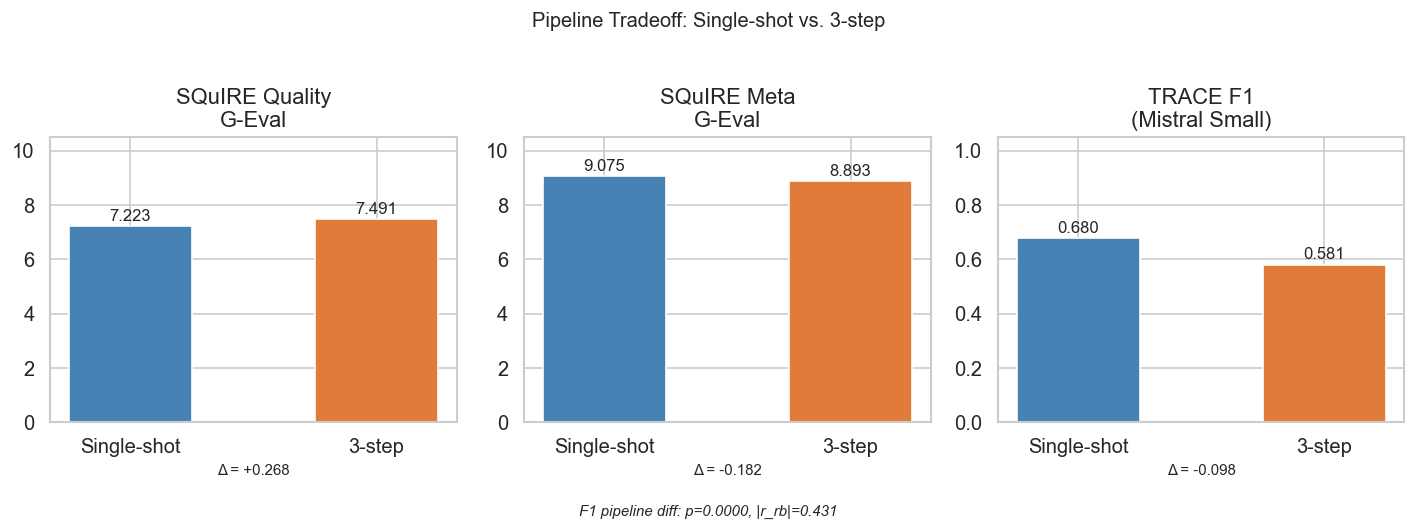

In [32]:
# ── Visualise the tradeoff ────────────────────────────────────────────────────
metrics_tradeoff = [
    ("SQuIRE Quality\nG-Eval",  ss_quality,    threes_quality,  0,  10),
    ("SQuIRE Meta\nG-Eval",     ss_meta,        threes_meta,      0,  10),
    ("TRACE F1\n(Mistral Small)", ss_trace_f1,  threes_trace_f1, 0,   1),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, ss_val, ts_val, ymin, ymax) in zip(axes, metrics_tradeoff):
    ax.bar(["Single-shot", "3-step"], [ss_val, ts_val],
           color=["steelblue", "#e07b39"], width=0.5)
    ax.set_ylim(ymin, ymax * 1.05)
    ax.set_title(title)
    for x, v in enumerate([ss_val, ts_val]):
        ax.text(x, v + (ymax * 0.02), f"{v:.3f}", ha="center", fontsize=10)
    delta = ts_val - ss_val
    ax.set_xlabel(f"Δ = {delta:+.3f}", fontsize=9)

plt.suptitle("Pipeline Tradeoff: Single-shot vs. 3-step", y=1.02, fontsize=12)
plt.tight_layout()
# Annotate F1 panel with pipeline test result (computed in cell 46)
try:
    _sig_str = (
        f"F1 pipeline diff: p={pipeline_f1_pval:.4f}, "
        f"|r_rb|={pipeline_f1_rrb:.3f}"
    )
except NameError:
    _sig_str = "Run cell 46 first to compute pipeline_f1_pval"
plt.figtext(0.5, -0.03, _sig_str, ha="center", fontsize=9, style="italic")
plt.show()


---
## 8. Manual Validation <a id='validation'></a>

### Protocol

To validate the automated evaluation methodology, a stratified sample of transcripts was reviewed manually. For each transcript, three checks were performed:

1. **GT validity**: Do the `selected_requirements` (sidecar JSON) actually correspond to quality aspects discussed in the transcript text?
2. **Citation accuracy**: Does each `source_citation` in the extraction appear verbatim or near-verbatim in the transcript?
3. **Overlap score calibration**: Does the GPT-5-mini judge's `overlap_score` (1–5) match human judgment of how well the extracted requirement maps to the matched GT?

### Sample selection

Stratified by project (2 per project) and interviewer type (1 experienced + 1 novice per project), 10 transcripts per corpus (25% sample).

- **Single-shot corpus**: run `180009` (Mistral Small T=0.5, 3rd validation run)
- **3-step corpus**: run `182911` (Mistral Small T=0.5, 2nd run)


In [33]:
# ── Prepare manual_eval/ — one numbered folder per review item ────────────────
# Cycles through primary TRACE runs so no single run dominates the sample.
#   ss : runs #1 → #2 → #3 → #1 → ...  (3 runs, 10 items → 4 / 3 / 3)
#   3s : runs #1 → #2 → #1 → ...        (2 runs, 10 items → 5 / 5)
import itertools, shutil

MANUAL_EVAL = Path("../manual_eval")

selection_plan = [
    ("3", "re_experienced", "stakeholder_technical_senior"),
    ("3", "re_novice",      "stakeholder_nontechnical_enduser"),
    ("4", "re_experienced", "stakeholder_nontechnical_manager"),
    ("4", "re_novice",      "stakeholder_technical_junior"),
    ("5", "re_experienced", "stakeholder_technical_junior"),
    ("5", "re_novice",      "stakeholder_technical_senior"),
    ("6", "re_experienced", "stakeholder_nontechnical_enduser"),
    ("6", "re_novice",      "stakeholder_nontechnical_manager"),
    ("8", "re_experienced", "stakeholder_technical_senior"),
    ("8", "re_novice",      "stakeholder_technical_junior"),
]

_IVIEW_SHORT = {"re_experienced": "experienced", "re_novice": "novice"}
_STAKE_SHORT = {
    "stakeholder_technical_senior":     "senior",
    "stakeholder_technical_junior":     "junior",
    "stakeholder_nontechnical_manager": "manager",
    "stakeholder_nontechnical_enduser": "enduser",
}

ss_runs = [r for r in TRACE_MANIFEST if r["phase"] == "primary" and r["corpus"] == "single-shot"]
ts_runs = [r for r in TRACE_MANIFEST if r["phase"] == "primary" and r["corpus"] == "3-step"]

def _find_transcript(corpus_dir, pid, iview, stake):
    matches = sorted(corpus_dir.glob(f"transcript_{pid}_{iview}_{stake}_*.txt"))
    return matches[0] if matches else None

def _find_trace_files(trace_dir, transcript_stem):
    trace_stem = "trace_" + transcript_stem
    extractions = [m for m in sorted(trace_dir.glob(f"{trace_stem}*.json")) if "_eval" not in m.name]
    if not extractions:
        return None, None
    ext = extractions[0]
    ev  = trace_dir / (ext.stem + "_eval.json")
    return ext, (ev if ev.exists() else None)

n, errors = 0, []
for corpus_tag, squire_dir, run_pool in [
    ("ss", SQUIRE_SINGLE_SHOT, ss_runs),
    ("3s", SQUIRE_3STEP,       ts_runs),
]:
    for (pid, iview, stake), run in zip(selection_plan, itertools.cycle(run_pool)):
        n += 1
        folder = f"{n:02d}-{corpus_tag}-{_IVIEW_SHORT[iview]}-x-{_STAKE_SHORT[stake]}"
        dest   = MANUAL_EVAL / folder
        dest.mkdir(parents=True, exist_ok=True)

        txt = _find_transcript(squire_dir, pid, iview, stake)
        if txt is None:
            errors.append(f"  MISSING: {folder}")
            continue

        sidecar   = squire_dir / (txt.stem + ".json")
        ext, ev   = _find_trace_files(run["path"], txt.stem)

        shutil.copy(txt, dest / "transcript.txt")
        if sidecar.exists():   shutil.copy(sidecar, dest / "transcript.json")
        if ext is not None:    shutil.copy(ext,     dest / "trace.json")
        if ev  is not None:    shutil.copy(ev,      dest / "trace_eval.json")

        print(f"  {folder}/   [{run['label']}]")

print(f"\n{'✓' if not errors else '✗'} {n} folders → {MANUAL_EVAL.resolve()}")
for e in errors:
    print(e)

  01-ss-experienced-x-senior/   [Mistral Small T=0.5 #1]
  02-ss-novice-x-enduser/   [Mistral Small T=0.5 #2]
  03-ss-experienced-x-manager/   [Mistral Small T=0.5 #3]
  04-ss-novice-x-junior/   [Mistral Small T=0.5 #1]
  05-ss-experienced-x-junior/   [Mistral Small T=0.5 #2]
  06-ss-novice-x-senior/   [Mistral Small T=0.5 #3]
  07-ss-experienced-x-enduser/   [Mistral Small T=0.5 #1]
  08-ss-novice-x-manager/   [Mistral Small T=0.5 #2]
  09-ss-experienced-x-senior/   [Mistral Small T=0.5 #3]
  10-ss-novice-x-junior/   [Mistral Small T=0.5 #1]
  11-3s-experienced-x-senior/   [Mistral Small T=0.5 #1]
  12-3s-novice-x-enduser/   [Mistral Small T=0.5 #2]
  13-3s-experienced-x-manager/   [Mistral Small T=0.5 #1]
  14-3s-novice-x-junior/   [Mistral Small T=0.5 #2]
  15-3s-experienced-x-junior/   [Mistral Small T=0.5 #1]
  16-3s-novice-x-senior/   [Mistral Small T=0.5 #2]
  17-3s-experienced-x-enduser/   [Mistral Small T=0.5 #1]
  18-3s-novice-x-manager/   [Mistral Small T=0.5 #2]
  19-3s-exp

### Validation Results

| # | Corpus | Project | Interviewer | Stakeholder | GT valid (N/10) | Citations accurate (correct/flagged) | Overlap scores agree (±1) |
|---|--------|---------|-------------|-------------|-----------|-------------------|---------------------|
| 1 | single-shot | 3 | Experienced | Tech. Senior | 10/10 | 29/1 | 30/30 |
| 2 | single-shot | 3 | Novice | End User | 8/10 | 9/1 | 10/10 |
| 3 | single-shot | 4 | Experienced | Manager | 8/10 | 15/0 | 14/15 |
| 4 | single-shot | 4 | Novice | Tech. Junior | 6/10 | 12/0 | 12/12 |
| 5 | single-shot | 5 | Experienced | Tech. Junior | 9/10 | 10/1 | 11/11 |
| 6 | single-shot | 5 | Novice | Tech. Senior | 9/10 | 17/1 | 18/18 |
| 7 | single-shot | 6 | Experienced | End User | 9/10 | 11/4 | 14/15 |
| 8 | single-shot | 6 | Novice | Manager | 8/10 | 11/0 | 11/11 |
| 9 | single-shot | 8 | Experienced | Tech. Senior | 10/10 | 18/2 | 20/20 |
| 10 | single-shot | 8 | Novice | Tech. Junior | 8/10 | 18/1 | 18/19 |
| 11 | 3-step | 3 | Experienced | Tech. Senior | 4/10 | 8/4 | 12/12 |
| 12 | 3-step | 3 | Novice | End User | 7/10 | 9/3 | 12/12 |
| 13 | 3-step | 4 | Experienced | Manager | 8/10 | 28/7 | 35/35 |
| 14 | 3-step | 4 | Novice | Tech. Junior | 7/10 | 15/7 | 17/22 |
| 15 | 3-step | 5 | Experienced | Tech. Junior | 10/10 | 7/12 | 16/19 |
| 16 | 3-step | 5 | Novice | Tech. Senior | 8/10 | 16/2 | 18/18 |
| 17 | 3-step | 6 | Experienced | End User | 9/10 | 16/0 | 15/16 |
| 18 | 3-step | 6 | Novice | Manager | 9/10 | 11/4 | 13/15 |
| 19 | 3-step | 8 | Experienced | Tech. Senior | 9/10 | 13/7 | 20/20 |
| 20 | 3-step | 8 | Novice | Tech. Junior | 9/10 | 27/0 | 25/27 |

**GT validity**: N/10 GT requirements per transcript were judged to be discussed in the dialogue.  
**Citation accuracy**: correct/flagged — citations verified verbatim or near-verbatim in the transcript vs. flagged by the automated system.  
**Overlap score calibration**: Human and automated overlap scores agreed (±1) in N/M cases.

### Conclusion

This review is a stratified sanity-check. All 20 transcripts were reviewed by the author, no inter-rater reliability can be established. Its purpose is twofold: to provide a transparent, documented look at what actually happens inside the pipeline across a representative sample, and to check whether the automated metrics are broadly coherent with human judgment. Both corpora and all five projects are represented; the full material is publicly available within the corpora.

The table above suggests rough alignment on all three dimensions: most GT requirements are discussed in the dialogue (82.5 % overall), TRACE citations can almost always be located in the transcript text (84.0 % overall), and automated overlap scores broadly agree with the author's reading (95.5 % within ±1). These numbers should be read as rough indicators of coherence, not as independent validation.

The more substantive contribution of this review is qualitative. Reading through 20 transcripts and their extraction outputs surfaced several recurring patterns that help interpret the quantitative results and point to limitations of the current evaluation design:

- **Requirement inflation produces legitimate but unmatchable decompositions.** SQuIRE regularly expands a single GT requirement into a multi-turn exchange that elicits more than one atomic statement (e.g., one availability requirement becoming a separate uptime target and a separate "no downtime during business hours" constraint). TRACE correctly extracts both statements; the 1:1 matching constraint then marks the second as a duplicate. This is a structural property of the pipeline, not an extraction error, and it means precision is systematically underestimated while recall is a more meaningful signal.

- **Synthesis adds content beyond the selected GT, mostly from the project summary.** The transcripts contain requirements that do not appear in the selected 10 GT items — the LLM draws on the project summary to fill conversational space. Observed cases were traceable to the project summary rather than unconstrained confabulation, but they still count as misses against the GT, further suppressing F1.

- **Citation failures are paraphrase and compression, not hallucination.** No outright fabricated citations were observed in this sample. Flagged citations fell into three patterns: minor punctuation normalisation, compression of a multi-sentence passage to its key clause, and rough paraphrase preserving semantic content. The higher flag rate in 3-step transcripts likely reflects their greater length and conversational density.

- **The NICE ground truth is an imperfect baseline.** Several GT requirements are non-atomic, blend functional and non-functional concerns, or are stated at a goal level without measurable criteria (e.g., "shall prevent malicious attacks including denial of service"). These requirements are difficult to synthesise faithfully and ambiguous to match against, introducing noise that affects both F1 and quality-attribute accuracy independent of model behaviour.

- **TRACE extraction quality is uneven.** Follow-up questions are often generic and not persona-aware. For long conversational passages covering a single topic, TRACE tends to extract multiple near-duplicate requirements rather than synthesising one well-formed atomic requirement. Extracted requirement phrasing sometimes mirrors colloquial stakeholder language rather than applying standard requirements vocabulary. These are practical limitations for a human-in-the-loop use case, where a reviewer would need to normalise and deduplicate the output.


---
## 9. Summary Tables <a id='summary'></a>

Canonical result tables for the thesis. All values are mean ± SD unless noted.


In [34]:
# ── RQ1 Summary ────────────────────────────────────────────────────────────────
print("Summary Table A — SQuIRE Synthesis Quality (RQ1)")
print("All means: value ± SD [95% bootstrap CI]")
print("─" * 70)

def _fmt_geval(series):
    lo, hi = _bstrap_ci(series)
    return f"{series.mean():.2f} ± {series.std():.2f} [{lo:.2f}–{hi:.2f}]"

for pipeline, df_p in [("Single-shot", df_ss), ("3-step", df_3s)]:
    print(f"\n  {pipeline} (n={len(df_p)})")
    print(f"    Quality G-Eval overall:    {_fmt_geval(df_p['quality'])}")
    for dim in ["structuring", "clarity", "responsiveness", "rigor"]:
        print(f"      {dim:<18}: {_fmt_geval(df_p[dim])}")
    print(f"    Meta G-Eval overall:       {_fmt_geval(df_p['meta'])}")
    for dim in ["completeness", "realism"]:
        print(f"      {dim:<18}: {_fmt_geval(df_p[dim])}")
    lo_b, hi_b = _bstrap_ci(df_p["bert_f1"])
    print(f"    BERTScore F1:              "
          f"{df_p['bert_f1'].mean():.3f} ± {df_p['bert_f1'].std():.3f} [{lo_b:.3f}–{hi_b:.3f}]")

    # Interviewer gap (quality only)
    nov = df_p.loc[df_p["interviewer"]=="re_novice", "quality"]
    exp = df_p.loc[df_p["interviewer"]=="re_experienced", "quality"]
    print(f"    Experienced − novice Δquality: +{exp.mean()-nov.mean():.2f}")


Summary Table A — SQuIRE Synthesis Quality (RQ1)
All means: value ± SD [95% bootstrap CI]
──────────────────────────────────────────────────────────────────────

  Single-shot (n=40)
    Quality G-Eval overall:    7.22 ± 0.36 [7.11–7.33]
      structuring       : 6.96 ± 0.41 [6.83–7.08]
      clarity           : 7.83 ± 0.41 [7.71–7.96]
      responsiveness    : 7.60 ± 0.39 [7.47–7.72]
      rigor             : 6.50 ± 0.52 [6.33–6.65]
    Meta G-Eval overall:       9.07 ± 0.37 [8.96–9.18]
      completeness      : 9.38 ± 0.67 [9.17–9.57]
      realism           : 8.78 ± 0.24 [8.70–8.85]
    BERTScore F1:              0.800 ± 0.007 [0.798–0.802]
    Experienced − novice Δquality: +0.56

  3-step (n=40)
    Quality G-Eval overall:    7.49 ± 0.31 [7.40–7.59]
      structuring       : 7.21 ± 0.40 [7.09–7.33]
      clarity           : 8.04 ± 0.33 [7.94–8.14]
      responsiveness    : 7.76 ± 0.33 [7.66–7.86]
      rigor             : 6.96 ± 0.41 [6.83–7.08]
    Meta G-Eval overall:       8.89

In [35]:
# ── RQ2 Summary ────────────────────────────────────────────────────────────────
print("Summary Table B — TRACE Extraction Accuracy (RQ2)")
print("F1 / Precision / Recall / QA Accuracy: mean [95% bootstrap CI]")
print("─" * 70)

configs = [
    ("Mistral Small T=0.5 (single-shot, ×3)",
     df_trace[(df_trace["model"]=="mistral-small") & (df_trace["temp"]==0.5) & (df_trace["corpus"]=="single-shot")]),
    ("Mistral Small T=0.5 (3-step, ×2)",
     df_trace[(df_trace["model"]=="mistral-small") & (df_trace["temp"]==0.5) & (df_trace["corpus"]=="3-step")]),
    ("Mistral Medium T=0.0 (single-shot)",
     df_trace[(df_trace["model"]=="mistral-medium") & (df_trace["corpus"]=="single-shot")]),
    ("GPT-5-mini low-effort (single-shot)",
     df_trace[(df_trace["model"]=="gpt-5-mini") & (df_trace["corpus"]=="single-shot")]),
]
for label, grp in configs:
    if len(grp) == 0:
        continue
    print(f"\n  {label} (n={len(grp)})")
    for col, name in [
        ("f1",                          "F1"),
        ("precision",                   "Precision"),
        ("recall",                      "Recall"),
        ("quality_attribute_accuracy",  "QA Acc."),
    ]:
        lo, hi = _bstrap_ci(grp[col])
        print(f"    {name:<12}: {grp[col].mean():.3f} [{lo:.3f}–{hi:.3f}]")
    print(f"    Avg extr.:  {grp['extracted_count'].mean():.1f} ± {grp['extracted_count'].std():.1f}")

Summary Table B — TRACE Extraction Accuracy (RQ2)
F1 / Precision / Recall / QA Accuracy: mean [95% bootstrap CI]
──────────────────────────────────────────────────────────────────────

  Mistral Small T=0.5 (single-shot, ×3) (n=120)
    F1          : 0.680 [0.659–0.700]
    Precision   : 0.592 [0.571–0.614]
    Recall      : 0.818 [0.791–0.843]
    QA Acc.     : 0.726 [0.699–0.754]
    Avg extr.:  14.2 ± 3.4

  Mistral Small T=0.5 (3-step, ×2) (n=80)
    F1          : 0.581 [0.553–0.609]
    Precision   : 0.479 [0.449–0.508]
    Recall      : 0.776 [0.741–0.810]
    QA Acc.     : 0.730 [0.691–0.768]
    Avg extr.:  17.4 ± 5.4

  Mistral Medium T=0.0 (single-shot) (n=40)
    F1          : 0.624 [0.582–0.663]
    Precision   : 0.509 [0.465–0.552]
    Recall      : 0.843 [0.800–0.883]
    QA Acc.     : 0.769 [0.718–0.820]
    Avg extr.:  17.9 ± 6.5

  GPT-5-mini low-effort (single-shot) (n=40)
    F1          : 0.594 [0.565–0.621]
    Precision   : 0.451 [0.424–0.476]
    Recall      : 0.

In [36]:
# ── RQ3 Summary — single-shot vs 3-step ──────────────────────────────────────
print("Summary Table C — Traceability & Gap Detection (RQ3): single-shot vs. 3-step")
print("Citation verified: proportion [95% Wilson CI]")
print("Per-requirement quality scores: mean [95% bootstrap CI]")
print("Recall gaps: recall [95% Wilson CI]")
print("─" * 70)

for label, df_cit, df_preq, gap_st in [
    ("Single-shot (Mistral Small T=0.5, ×3 runs)", df_cit_ss, df_preq_ss, stats_ss),
    ("3-step      (Mistral Small T=0.5, ×2 runs)", df_cit_3s, df_preq_3s, stats_3s),
]:
    print(f"\n  {label}  (n={len(df_cit)} requirements)")

    if len(df_cit) > 0:
        n_v = int(df_cit["citation_verified"].sum())
        n   = len(df_cit)
        lo, hi = _wilson_ci(n_v, n)
        print(f"    Citation verified:    {100*n_v/n:.1f}%  95% CI [{100*lo:.1f}%–{100*hi:.1f}%]"
              f"  | Flagged: {100*(n-n_v)/n:.1f}%")

    if len(df_preq) > 0:
        print(f"    Per-requirement quality scores (1–5):")
        for col, name in [
            ("gap_detection_quality", "Gap detection quality"),
            ("rationale_quality",     "Rationale quality"),
            ("confidence_quality",    "Confidence quality"),
        ]:
            lo, hi = _bstrap_ci(df_preq[col])
            print(f"      {name:<26}: {df_preq[col].mean():.2f} [{lo:.2f}–{hi:.2f}]")

    if len(gap_st) > 0:
        print(f"    Recall gaps — worst 3 categories:")
        for cat, row in gap_st.head(3).iterrows():
            print(f"      {cat:<25}: {row['recall']:.2f} [{row['ci_lo']:.2f}–{row['ci_hi']:.2f}]"
                  f"  ({int(row['matched'])}/{int(row['total'])})")
        print(f"    Recall gaps — best 3 categories:")
        for cat, row in gap_st.tail(3).iterrows():
            print(f"      {cat:<25}: {row['recall']:.2f} [{row['ci_lo']:.2f}–{row['ci_hi']:.2f}]"
                  f"  ({int(row['matched'])}/{int(row['total'])})")


Summary Table C — Traceability & Gap Detection (RQ3): single-shot vs. 3-step
Citation verified: proportion [95% Wilson CI]
Per-requirement quality scores: mean [95% bootstrap CI]
Recall gaps: recall [95% Wilson CI]
──────────────────────────────────────────────────────────────────────

  Single-shot (Mistral Small T=0.5, ×3 runs)  (n=1707 requirements)
    Citation verified:    76.1%  95% CI [74.0%–78.1%]  | Flagged: 23.9%
    Per-requirement quality scores (1–5):
      Gap detection quality     : 3.54 [3.50–3.58]
      Rationale quality         : 3.68 [3.65–3.71]
      Confidence quality        : 4.04 [4.01–4.08]
    Recall gaps — worst 3 categories:
      operability              : 0.54 [0.48–0.61]  (122/225)
      portability              : 0.73 [0.61–0.83]  (44/60)
      usability                : 0.80 [0.75–0.85]  (176/219)
    Recall gaps — best 3 categories:
      look_and_feel            : 0.95 [0.89–0.98]  (97/102)
      performance              : 0.97 [0.93–0.98]  (223/231)
 

## §10 ISO/IEC 25010 Re-labelling Concordance (Validity Analysis)

**Purpose:** This section addresses the construct validity concern that TRACE and its evaluation both use the NICE/PROMISE topic-label taxonomy as ground truth and classification target. To partially address this threat, a separate cold-classification experiment was conducted: a new LLM agent (the `iso-label` tool, see §4 of the thesis) was asked to assign ISO/IEC 25010:2023 sub-characteristics to the 381 NICE QRs without being shown any NICE labels.

**Setup:**
- **Classifier:** Mistral Small 4 (`mistral-small-latest`, April 2026) — a newer model version than TRACE's Mistral Small 3.2; both serve distinct analytic purposes and version consistency is not required.
- **Task:** Cold multi-label ISO/IEC 25010:2023 sub-characteristic assignment (40 sub-chars across 9 characteristics).
- **Repetitions:** n=5 independent runs, all 381 QRs per run. Temperature = 0.5.
- **Scoring:** Jaccard similarity and Recall at the ISO *characteristic* level (not sub-characteristic), using a pragmatic best-fit mapping derived from the NICE annotation lineage and Li et al.'s ontological analysis (see Table 1 of thesis Background).
- **Excluded from scoring:** Legal (L) and Other (OT) have no principled ISO mapping and are reported descriptively only (cell 60).
- **Design note:** The agent was not instructed to return an empty list when no ISO characteristic applies. It therefore always assigns at least one sub-characteristic. ISO assignments for Legal items and any other unmappable content reflect a forced nearest-fit rather than a principled mapping. This must be stated when interpreting descriptive results for L.

In [37]:
# ── §10 Setup — ISO Taxonomy, Mapping, Load Runs ─────────────────────────────
import glob
import statistics as _stats

ISO_TAXONOMY = {
    "Functional suitability": [
        "Functional completeness", "Functional appropriateness", "Functional correctness",
    ],
    "Performance efficiency": ["Time behaviour", "Resource utilization", "Capacity"],
    "Compatibility":          ["Co-existence", "Interoperability"],
    "Interaction capability": [
        "Appropriateness recognizability", "Learnability", "Operability",
        "User error protection", "User engagement", "Inclusivity",
        "User assistance", "Self descriptiveness",
    ],
    "Reliability":     ["Faultlessness", "Availability", "Fault tolerance", "Recoverability"],
    "Security":        ["Confidentiality", "Integrity", "Non-repudiation",
                        "Accountability", "Authenticity", "Resistance"],
    "Maintainability": ["Modularity", "Reusability", "Analysability", "Modifiability", "Testability"],
    "Flexibility":     ["Adaptability", "Scalability", "Installability", "Replaceability"],
    "Safety":          ["Operational constraint", "Risk identification", "Fail safe",
                        "Hazard warning", "Safe integration"],
}
SUB_TO_CHAR = {sub: char for char, subs in ISO_TAXONOMY.items() for sub in subs}

NICE_TO_ISO_CHARS = {
    "Availability (A)":     ["Reliability"],
    "Fault Tolerance (FT)": ["Reliability", "Safety"],
    "Look & Feel (LF)":     ["Interaction capability"],
    "Maintainability (MN)": ["Maintainability"],
    "Operability (O)":      ["Interaction capability"],
    "Performance (PE)":     ["Performance efficiency"],
    "Portability (PO)":     ["Flexibility", "Compatibility"],
    "Scalability (SC)":     ["Flexibility"],
    "Security (SE)":        ["Security"],
    "Usability (US)":       ["Interaction capability"],
}
NICE_LABEL_COLS = [
    "Availability (A)", "Fault Tolerance (FT)", "Legal (L)", "Look & Feel (LF)",
    "Maintainability (MN)", "Operability (O)", "Performance (PE)", "Portability (PO)",
    "Scalability (SC)", "Security (SE)", "Usability (US)", "Other (OT)",
]

# Load all iso_label run files
run_files = sorted(glob.glob(str(OUTPUTS / "iso_label_*/results.json")))
print(f"Found {len(run_files)} run file(s):")
for f in run_files:
    print(f"  {Path(f).parent.name}")

records = []
for run_id, run_file in enumerate(run_files, 1):
    data = json.loads(Path(run_file).read_text())
    for item in data["results"]:
        records.append({
            "run_id":           run_id,
            "project_id":       item["project_id"],
            "requirement_text": item["requirement_text"],
            "nice_labels":      item["nice_labels"],
            "iso_sub_chars":    item["iso_sub_chars"],
        })

df_iso = pd.DataFrame(records)
print(f"\nLoaded {len(df_iso)} (run, requirement) pairs across {df_iso['run_id'].nunique()} runs")

Found 5 run file(s):
  iso_label_20260422_141254
  iso_label_20260422_141316
  iso_label_20260422_141344
  iso_label_20260422_141448
  iso_label_20260422_141518

Loaded 1905 (run, requirement) pairs across 5 runs


In [38]:
# ── §10 Score — Jaccard & Recall at ISO characteristic level ─────────────────

def _score_row(row):
    predicted_chars = {SUB_TO_CHAR[s] for s in row["iso_sub_chars"] if s in SUB_TO_CHAR}
    expected_chars  = {c for lbl in row["nice_labels"] for c in NICE_TO_ISO_CHARS.get(lbl, [])}
    if not expected_chars:
        return pd.Series({"scoreable": False, "jaccard": None, "recall": None,
                          "predicted_chars": sorted(predicted_chars),
                          "expected_chars": [], "complete_miss": None})
    inter = predicted_chars & expected_chars
    union = predicted_chars | expected_chars
    j = len(inter) / len(union) if union else 0.0
    r = len(inter) / len(expected_chars)
    return pd.Series({
        "scoreable":       True,
        "jaccard":         j,
        "recall":          r,
        "predicted_chars": sorted(predicted_chars),
        "expected_chars":  sorted(expected_chars),
        "complete_miss":   j == 0.0,
    })

df_scored = pd.concat([df_iso, df_iso.apply(_score_row, axis=1)], axis=1)
scoreable = df_scored[df_scored["scoreable"] == True].copy()
print(f"Scoreable (run, req) pairs: {len(scoreable)}/{len(df_scored)} "
      f"({len(scoreable)/len(df_scored)*100:.1f}%)")
print(f"Overall mean Jaccard:  {scoreable['jaccard'].mean():.3f}")
print(f"Overall mean Recall:   {scoreable['recall'].mean():.3f}")

Scoreable (run, req) pairs: 1850/1905 (97.1%)
Overall mean Jaccard:  0.479
Overall mean Recall:   0.545


In [39]:
# ── §10 Per-NICE-label aggregate table ────────────────────────────────────────
from scipy.stats import sem as _scipy_sem
import numpy as np

agg_rows = []
for label in NICE_LABEL_COLS:
    if label in ("Legal (L)", "Other (OT)"):
        continue
    mask = scoreable["nice_labels"].apply(lambda ls: label in ls)
    sub = scoreable[mask]
    if len(sub) == 0:
        continue
    jacs = sub["jaccard"].values
    recs = sub["recall"].values
    miss = sub["complete_miss"].values
    n = len(jacs)
    mean_j = float(np.mean(jacs))
    sd_j   = float(np.std(jacs, ddof=1)) if n > 1 else 0.0
    ci95   = float(1.96 * _scipy_sem(jacs)) if n > 1 else 0.0
    mean_r = float(np.mean(recs))
    miss_r = float(np.mean(miss) * 100)
    agg_rows.append({
        "NICE Label": label,
        "Mean J":  round(mean_j, 3),
        "SD J":    round(sd_j, 3),
        "CI±95%":  round(ci95, 3),
        "Mean R":  round(mean_r, 3),
        "Miss%":   round(miss_r, 1),
        "n":       n,
    })

df_agg10 = pd.DataFrame(agg_rows).sort_values("Mean J", ascending=False)
print(df_agg10.to_string(index=False))

          NICE Label  Mean J  SD J  CI±95%  Mean R  Miss%   n
      Usability (US)   0.678 0.372   0.035   0.750 12.700 425
    Performance (PE)   0.640 0.314   0.035   0.707  3.800 315
    Look & Feel (LF)   0.608 0.447   0.047   0.656 30.400 345
    Availability (A)   0.601 0.380   0.054   0.620 18.900 190
       Security (SE)   0.446 0.407   0.041   0.583 37.300 375
Fault Tolerance (FT)   0.389 0.181   0.040   0.430 12.500  80
    Portability (PO)   0.238 0.220   0.041   0.260 40.000 110
Maintainability (MN)   0.205 0.312   0.047   0.280 61.200 170
    Scalability (SC)   0.194 0.220   0.036   0.239 53.100 145
     Operability (O)   0.108 0.235   0.027   0.132 77.600 290


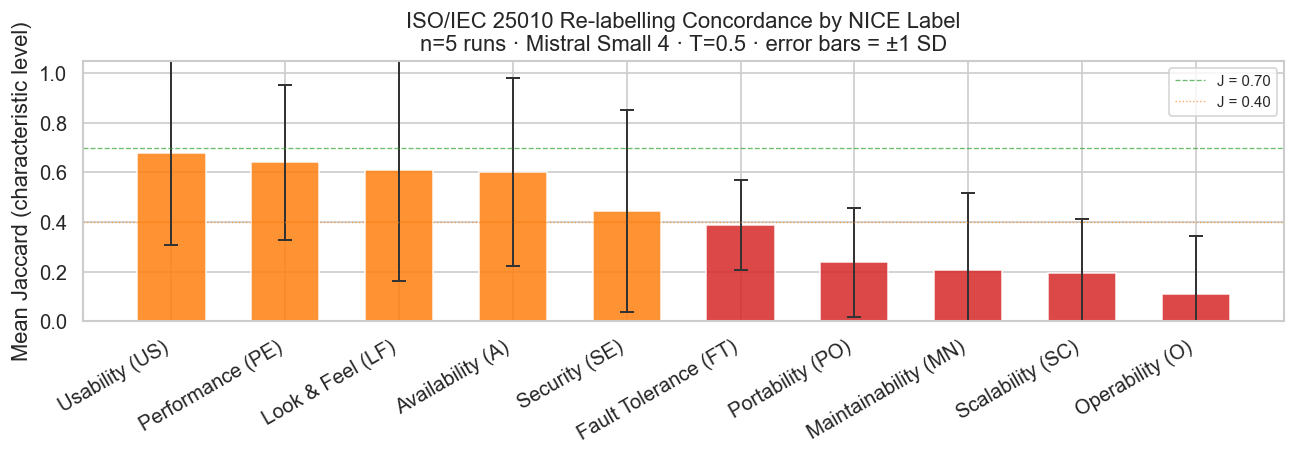

In [40]:
# ── §10 Stability chart — mean Jaccard ± SD per NICE label ───────────────────
fig, ax = plt.subplots(figsize=(11, 4))

labels_s  = df_agg10["NICE Label"].tolist()
mean_j_s  = df_agg10["Mean J"].tolist()
sd_j_s    = df_agg10["SD J"].tolist()

colors = [
    "#2ca02c" if j >= 0.7 else ("#ff7f0e" if j >= 0.4 else "#d62728")
    for j in mean_j_s
]

ax.bar(labels_s, mean_j_s, color=colors, alpha=0.85, width=0.6)
ax.errorbar(labels_s, mean_j_s, yerr=sd_j_s, fmt="none",
            ecolor="#333333", elinewidth=1.2, capsize=4, capthick=1.2)

ax.axhline(0.7, color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.7, label="J = 0.70")
ax.axhline(0.4, color="#ff7f0e", linewidth=0.8, linestyle=":",  alpha=0.7, label="J = 0.40")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean Jaccard (characteristic level)")
ax.set_title(
    "ISO/IEC 25010 Re-labelling Concordance by NICE Label\n"
    "n=5 runs · Mistral Small 4 · T=0.5 · error bars = ±1 SD"
)
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [41]:
# ── §10 Legal (L) and Other (OT) — descriptive ISO characteristic assignment ──
from collections import Counter

for unmappable in ("Legal (L)", "Other (OT)"):
    mask = df_iso["nice_labels"].apply(lambda ls: unmappable in ls)
    sub  = df_iso[mask]
    char_counts: Counter = Counter()
    for sub_list in sub["iso_sub_chars"]:
        chars = {SUB_TO_CHAR[s] for s in sub_list if s in SUB_TO_CHAR}
        char_counts.update(chars)
    n_items = len(sub)
    print(f"\n{unmappable}  (n={n_items} (run, requirement) pairs)")
    print("  Most-assigned ISO characteristics (% of items):")
    for char, count in char_counts.most_common(6):
        print(f"    {char:<32}  {count/n_items*100:.1f}%")


Legal (L)  (n=155 (run, requirement) pairs)
  Most-assigned ISO characteristics (% of items):
    Functional suitability            56.1%
    Interaction capability            23.9%
    Security                          14.2%
    Maintainability                   11.0%
    Reliability                       0.6%
    Compatibility                     0.6%

Other (OT)  (n=0 (run, requirement) pairs)
  Most-assigned ISO characteristics (% of items):


## §10 Summary — ISO/IEC 25010 Re-labelling Concordance

Key findings from cold ISO classification of the 381 NICE QRs (n=5 runs, Mistral Small 4, T=0.5):

- **Moderate concordance for core categories:** Usability (US), Performance (PE), Look & Feel (LF), and Availability (A) show the highest mean Jaccard, consistent with clear structural alignment to Interaction capability, Performance efficiency, and Reliability in ISO/IEC 25010:2023.
- **Systematic divergence for structural categories:** Maintainability (MN), Scalability (SC), and Portability (PO) show consistently low Jaccard with low SD — stable disagreement rather than model instability. This likely reflects ISO's broader characteristic scope and the 2023 structural splits, rather than model error.
- **Operability (O):** Near-zero mean Jaccard, consistent with the TRACE confusion matrix finding. The label has significant FR/CF content (per Li et al.) that falls outside the ISO Interaction capability scope the mapping expects.
- **Fault Tolerance (FT):** Moderate concordance with elevated complete-miss rate, reflecting the dual mapping (Reliability + Safety) that cold classification does not consistently reproduce.
- **Legal (L):** Unmappable; the agent assigns primarily Functional suitability (~56%), Interaction capability (~24%), and Security (~14%). **Caveat:** the prompt did not instruct the agent to abstain or return an empty list, so these assignments reflect a forced nearest-fit under the constraint to always classify. They should not be interpreted as evidence that Legal requirements map to Functional suitability; they show what the model does when compelled to assign something to compliance-oriented text. **Other (OT):** No items in the QR subset carry this label (it is a non-QR catch-all in NICE), so no data is available.
- **Construct validity implication:** NICE and ISO show alignment for the core quality categories (PE, US, A, LF). For MN, SC, PO, and O, systematic divergence reflects genuine differences in how the two taxonomies scope these concepts — consistent with Li et al.'s finding of ontological heterogeneity. The use of NICE labels as TRACE ground truth is appropriate for NLP classification tasks; the divergent categories represent a construct validity limitation to be acknowledged when interpreting per-label classification accuracy.

---
## §11 — Thesis Figure Export

> **Note:** This section has **no analytical value**. Its sole purpose is to generate
> polished, thesis-ready figures for inclusion in Chapter 5 (Results).
> All analysis and interpretation is in §2–10 above.
> 
> This section is equivalent to running `notebooks/generate_thesis_figures.py`.
> After running, move the `thesis_fig_*.png` outputs from `notebooks/` to `thesis/figures/`.
> 
> Requires: all prior cells to have been executed (uses variables from §1–10).

In [42]:
# §11 — Save t-SNE coordinates for thesis figure generation
# Run after cells 02–10 have executed (requires X_tsne_ss, X_tsne_3s,
# df_txt_ss, df_txt_3s, X_ss, X_3s to be in scope).
# Output files are loaded by generate_thesis_figures.py — no embedding model needed there.

import json as _json
import numpy as _np
from sklearn.metrics import silhouette_score as _sil

_np.savez(
    "tsne_coords.npz",
    X_tsne_ss        = X_tsne_ss,
    X_tsne_3s        = X_tsne_3s,
    project_ids_ss   = df_txt_ss["project_id"].values,
    project_ids_3s   = df_txt_3s["project_id"].values,
    stakeholders_ss  = df_txt_ss["stakeholder"].values,
    stakeholders_3s  = df_txt_3s["stakeholder"].values,
)

_meta = dict(
    sil_project_ss     = float(_sil(X_ss,  df_txt_ss["project_id"],  metric="cosine")),
    sil_project_3s     = float(_sil(X_3s,  df_txt_3s["project_id"],  metric="cosine")),
    sil_stakeholder_ss = float(_sil(X_ss,  df_txt_ss["stakeholder"], metric="cosine")),
    sil_stakeholder_3s = float(_sil(X_3s,  df_txt_3s["stakeholder"], metric="cosine")),
)
with open("tsne_meta.json", "w") as _f:
    _json.dump(_meta, _f, indent=2)

print("Saved tsne_coords.npz and tsne_meta.json")
print("Silhouette scores:", _meta)

Saved tsne_coords.npz and tsne_meta.json
Silhouette scores: {'sil_project_ss': 0.49829816818237305, 'sil_project_3s': 0.5196174383163452, 'sil_stakeholder_ss': -0.029283497482538223, 'sil_stakeholder_3s': -0.023282203823328018}


In [43]:
# § 11 — Thesis Figure Export (run notebooks/generate_thesis_figures.py standalone)
# This cell generates all thesis-chapter figures and saves them as PNG files.
# See generate_thesis_figures.py for full self-contained implementation.
import runpy, pathlib, os
os.chdir(pathlib.Path().resolve())  # ensure cwd = notebooks/
runpy.run_path('generate_thesis_figures.py', run_name='__main__')

Generating: thesis_fig_extraction_scatter.png


generate_thesis_figures.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ss = pd.concat(frames, ignore_index=True)


  Saved: thesis_fig_extraction_scatter.png
Generating: thesis_fig_confusion_ss.png
  Saved: thesis_fig_confusion_ss.png
Generating: thesis_fig_iso_concordance.png
  Saved: thesis_fig_iso_concordance.png
Generating: thesis_fig_project_f1.png
  Saved: thesis_fig_project_f1.png
Generating: thesis_fig_tsne_embedding.png
  Saved: thesis_fig_tsne_embedding.png
Generating: thesis_fig_geval_dimensions.png
  Saved: thesis_fig_geval_dimensions.png
Generating: thesis_fig_recall_gaps.png
  Saved: thesis_fig_recall_gaps.png
Generating: thesis_fig_confidence_calibration.png
  Saved: thesis_fig_confidence_calibration.png
Generating: thesis_fig_tsne_3s_stakeholder.png
  Saved: thesis_fig_tsne_3s_stakeholder.png
Generating: thesis_fig_extraction_scatter_f1.png
  Saved: thesis_fig_extraction_scatter_f1.png

Done. Move PNG files to thesis/figures/.


generate_thesis_figures.py:884: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ss = pd.concat(frames, ignore_index=True)


{'__name__': '__main__',
 '__doc__': '\nThesis Figure Generation Script\n================================\nGenerates polished, thesis-ready figures for Chapter 5 (Results).\nThis script has NO analytical value; it is a figure export utility.\nRun from the `codeproj/` directory:\n\n    uv run python notebooks/generate_thesis_figures.py\n\nOutput PNGs are written to notebooks/ — move them to thesis/figures/.\n\nDepends on: matplotlib, seaborn, pandas, numpy, scipy, scikit-learn\nDoes NOT require: sentence_transformers (no embedding model needed)\n\nfig_tsne_embedding() requires pre-computed tsne_coords.npz + tsne_meta.json.\nGenerate them by running cell 63 (tsne-save-coords) in thesis_analysis.ipynb\nafter cells 02–10 have executed.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'generate_thesis_figures.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module p